**new try**

In [4]:



from datasets import load_dataset
import pandas as pd
import random
import math

# --- PARAMETERS ---
num_examples = 500      # total number of GSM8K examples
batch_size = 10         # number of questions per ChatGPT batch
output_file = "gsm8k_500_batches.csv"

# --- STEP 1: Load GSM8K dataset ---
dataset = load_dataset("gsm8k", "main")
gsm8k_data = dataset["train"]
print(f"Loaded {len(gsm8k_data)} total GSM8K examples")

# --- STEP 2: Randomly sample 500 examples ---
random.seed(42)
sample_indices = random.sample(range(len(gsm8k_data)), num_examples)
sampled_data = gsm8k_data.select(sample_indices)

# --- STEP 3: Convert to DataFrame ---
df = pd.DataFrame({
    "question": sampled_data["question"],
    "answer": sampled_data["answer"]
})

# --- STEP 4: Split into batches of 10 questions ---
num_batches = math.ceil(num_examples / batch_size)
print(f"✅ Preparing {num_batches} batches of {batch_size} questions each")

batches = []
for i in range(num_batches):
    start = i * batch_size
    end = min((i + 1) * batch_size, len(df))
    batch = df.iloc[start:end]["question"].tolist()

    # Combine questions into one string, enumerated as Question1:, Question2:, etc.
    batch_text = ""
    for j, q in enumerate(batch, start=1):
        batch_text += f"Question{j}: {q.strip()}\n"

    batches.append(batch_text.strip())

# --- STEP 5: Create final DataFrame with one row per batch ---
batch_df = pd.DataFrame({
    "batch_id": [f"batch_{i+1:02d}" for i in range(num_batches)],
    "batch_text": batches
})

# --- STEP 6: Save to CSV ---
batch_df.to_csv(output_file, index=False)

print(f"\n🎉 Saved {num_batches} batches to '{output_file}'")
print(batch_df.head(3))


Loaded 7473 total GSM8K examples
✅ Preparing 50 batches of 10 questions each

🎉 Saved 50 batches to 'gsm8k_500_batches.csv'
   batch_id                                         batch_text
0  batch_01  Question1: For every 12 cans you recycle, you ...
1  batch_02  Question1: John buys cans of soup for buy 1 ge...
2  batch_03  Question1: At a convention, 16 of 36 delegates...


**collecting chat gpt outputs**

In [79]:
import pandas as pd
import os

# Paste your ChatGPT JSON output here for each batch run
chatgpt_output = [
  {
    "original": "Peggy fell off her bike and skinned her knees. She needed two bandages on her left knee and three bandages on her right knee. If the box of bandages had 8 less than two dozen bandages before Peggy skinned her knees, how many bandages were left in the box after Peggy finished putting bandages on her knees?",
    "lexical": "Peggy scraped both knees after falling off her bike. She used 2 bandages for her left knee and 3 for her right. The box originally had 8 fewer than two dozen bandages. How many are left after she used them?",
    "syntactic": "If a box had 8 fewer than 24 bandages and Peggy used 2 on her left knee and 3 on her right after a bike fall, how many bandages remain in the box?",
    "contextual": "After a minor bike accident, Peggy used 2 bandages on one knee and 3 on the other. Her box had 8 less than 24 bandages to start. How many are left afterward?"
  },
  {
    "original": "Jangshe spent $610 on 7 pieces of clothing. One piece was $49 and another piece was $81. If the other pieces were all the same price, how many dollars was one of the other pieces?",
    "lexical": "Jangshe bought 7 clothing items for $610 total. One item cost $49 and another $81. The rest all cost the same. What was the price of each of the remaining items?",
    "syntactic": "If 7 pieces of clothing cost $610 in total, with one priced at $49 and another at $81 while the others cost the same, how much did each of the remaining items cost?",
    "contextual": "While shopping at the mall, Jangshe spent $610 on 7 items—two of which cost $49 and $81. Assuming the others were equally priced, what did one of them cost?"
  },
  {
    "original": "Mike has to get an x-ray and an MRI. The x-ray is $250 and the MRI is triple that cost. Insurance covers 80%. How much did he pay?",
    "lexical": "Mike needs both an x-ray and an MRI. The x-ray costs $250, and the MRI costs three times that. His insurance covers 80% of the total bill. How much does Mike pay out of pocket?",
    "syntactic": "If Mike’s x-ray costs $250 and his MRI costs three times as much, and insurance pays 80% of the total, what is Mike’s share of the bill?",
    "contextual": "At his medical appointment, Mike pays for an x-ray and an MRI. The x-ray is $250 and the MRI is triple that amount. His insurance covers 80%. How much does he owe?"
  },
  {
    "original": "TreQuan is throwing rocks in the river and he notices that the bigger the rock, the wider the splash. Pebbles make a splash that is a 1/4 meter wide. Rocks make a splash that is 1/2 a meter wide, and boulders create a splash that is 2 meters wide. If he tosses 6 pebbles, 3 rocks, and 2 boulders, what is the total width of the splashes he makes?",
    "lexical": "TreQuan observes that larger rocks create wider splashes. Pebbles splash 0.25 meters wide, rocks 0.5 meters, and boulders 2 meters. If he throws 6 pebbles, 3 rocks, and 2 boulders, what’s the combined width of all splashes?",
    "syntactic": "If TreQuan throws 6 pebbles (0.25 m each), 3 rocks (0.5 m each), and 2 boulders (2 m each), what total width of splashes does he produce?",
    "contextual": "While spending time by the river, TreQuan tosses 6 pebbles, 3 rocks, and 2 boulders. Their splashes measure 1/4, 1/2, and 2 meters wide respectively. What’s the total width?"
  },
  {
    "original": "Rob and Mark plan to meet at the national park. It takes 1 hour for Rob to get to the national park and it takes three times as much time for Mark to get to the national park. If Rob leaves his home at 11 a.m., at what time should Mark leave his home so that they both arrive at the same time?",
    "lexical": "Rob takes 1 hour to reach the park, while Mark takes triple that time. If Rob leaves at 11 a.m., what time should Mark depart to arrive simultaneously?",
    "syntactic": "If Rob needs 1 hour and Mark needs 3 times longer to reach the national park, when should Mark leave if Rob leaves at 11 a.m. and they want to arrive together?",
    "contextual": "Two friends, Rob and Mark, are meeting at the park. Rob’s trip takes 1 hour; Mark’s takes three times as long. If Rob leaves at 11 a.m., when must Mark start driving?"
  },
  {
    "original": "Police officer A patrols 36 streets in 4 hours. His colleague, officer B, patrols 55 streets in 5 hours. How many streets will both officers patrol in one hour?",
    "lexical": "Officer A covers 36 streets in 4 hours, and Officer B covers 55 streets in 5 hours. Together, how many streets can they patrol in a single hour?",
    "syntactic": "If Officer A patrols 36 streets in 4 hours and Officer B patrols 55 in 5 hours, how many streets will both officers patrol together per hour?",
    "contextual": "During a joint shift, Officer A covers 36 streets in 4 hours, while Officer B covers 55 in 5. How many streets can they patrol in one hour combined?"
  },
  {
    "original": "Kim takes 4 classes in school that last 2 hours each. She drops 1 class. How many hours of classes does she have now have per day?",
    "lexical": "Kim originally takes 4 classes, each lasting 2 hours. After dropping one, how many class hours remain in her schedule per day?",
    "syntactic": "If Kim has 4 classes that are 2 hours long and she drops one of them, how many hours of classes does she have left per day?",
    "contextual": "At her high school, Kim’s daily schedule includes 4 two-hour classes. She decides to drop one class. How many hours of class does she still have each day?"
  },
  {
    "original": "Era had 5 burgers for her and her 4 friends. She sliced each burger into halves. The first and second friends got 1 and 2 slices, respectively. Then the third and fourth friends got 3 slices each. How many slices of burgers are left for Era?",
    "lexical": "Era shared 5 burgers with 4 friends, cutting each burger into halves. Friend 1 got 1 slice, friend 2 got 2, and friends 3 and 4 got 3 each. How many slices remain for Era?",
    "syntactic": "If 5 burgers are each cut in half, and the first friend takes 1 slice, the second 2, and the next two friends 3 each, how many slices are left for Era?",
    "contextual": "At a picnic, Era splits 5 burgers (each halved) among her 4 friends. The first gets 1 slice, the second 2, and the next two get 3 each. How many slices can Era eat?"
  },
  {
    "original": "Because of the migration of salmon, the total number of salmon in river Trout has increased by ten times the number initially in the river. If there were 500 salmons initially, calculate the total number of fish in the river now.",
    "lexical": "Due to migration, the salmon population in the Trout River became ten times its original amount. If it started with 500 salmon, what’s the total number now?",
    "syntactic": "If there were originally 500 salmon in Trout River and the population grew to ten times that number, how many salmon are in the river now?",
    "contextual": "Following the seasonal migration, the number of salmon in Trout River increased tenfold. If there were 500 before migration, how many are there now?"
  },
  {
    "original": "On a weekend road trip, the Jensen family drove 210 miles on highways, where their car gets 35 miles for each gallon of gas and 54 miles on city streets where their car gets 18 miles for each gallon. How many gallons of gas did they use?",
    "lexical": "The Jensen family traveled 210 miles on highways at 35 mpg and 54 miles on city roads at 18 mpg. How many gallons of fuel did they consume in total?",
    "syntactic": "If the Jensens drive 210 miles on highways (35 mpg) and 54 miles in the city (18 mpg), what total number of gallons do they use?",
    "contextual": "During a weekend drive, the Jensen family covered 210 highway miles at 35 mpg and 54 city miles at 18 mpg. How many gallons of gas were used?"
  }
]


# Convert to DataFrame
df = pd.DataFrame(chatgpt_output)

# Optional: add incremental ID
df.insert(0, "id", range(1, len(df) + 1))

# File path
file_path = "gsm8k_perturbed_full.csv"

# --- Check if file exists ---
if os.path.exists(file_path):
    # Load existing file
    existing_df = pd.read_csv(file_path)
    
    # Adjust ID to continue from the last one
    last_id = existing_df["id"].max()
    df["id"] = range(last_id + 1, last_id + 1 + len(df))
    
    # Append new batch
    combined_df = pd.concat([existing_df, df], ignore_index=True)
    combined_df.to_csv(file_path, index=False, encoding="utf-8")
    print(f"✅ Appended {len(df)} new rows to existing file '{file_path}'")
else:
    # Create new file
    df.to_csv(file_path, index=False, encoding="utf-8")
    print(f"✅ Created new file '{file_path}' with {len(df)} rows")

# Preview
display(df.head())



✅ Appended 10 new rows to existing file 'gsm8k_perturbed_full.csv'


,id,original,lexical,syntactic,contextual
0,491,Peggy fell off her bike and skinned her knees....,Peggy scraped both knees after falling off her...,If a box had 8 fewer than 24 bandages and Pegg...,"After a minor bike accident, Peggy used 2 band..."
1,492,Jangshe spent $610 on 7 pieces of clothing. On...,Jangshe bought 7 clothing items for $610 total...,"If 7 pieces of clothing cost $610 in total, wi...","While shopping at the mall, Jangshe spent $610..."
2,493,Mike has to get an x-ray and an MRI. The x-ray...,Mike needs both an x-ray and an MRI. The x-ray...,If Mike’s x-ray costs $250 and his MRI costs t...,"At his medical appointment, Mike pays for an x..."
3,494,TreQuan is throwing rocks in the river and he ...,TreQuan observes that larger rocks create wide...,"If TreQuan throws 6 pebbles (0.25 m each), 3 r...","While spending time by the river, TreQuan toss..."
4,495,Rob and Mark plan to meet at the national park...,"Rob takes 1 hour to reach the park, while Mark...",If Rob needs 1 hour and Mark needs 3 times lon...,"Two friends, Rob and Mark, are meeting at the ..."


**answers on my questions**

In [2]:
from datasets import load_dataset
import pandas as pd
import random
import math

# --- PARAMETERS ---
num_examples = 500      # total number of GSM8K examples
batch_size = 10         # number of questions per batch
output_file = "gsm8k_500_batches_with_answers.csv"

# --- STEP 1: Load GSM8K dataset ---
dataset = load_dataset("gsm8k", "main")
gsm8k_data = dataset["train"]
print(f"Loaded {len(gsm8k_data)} total GSM8K examples")

# --- STEP 2: Randomly sample 500 examples using same seed ---
random.seed(42)
sample_indices = random.sample(range(len(gsm8k_data)), num_examples)
sampled_data = gsm8k_data.select(sample_indices)

# --- STEP 3: Convert to DataFrame ---
df = pd.DataFrame({
    "question": sampled_data["question"],
    "answer": sampled_data["answer"]
})

# --- STEP 4: Split into batches of 10 questions with their answers ---
num_batches = math.ceil(num_examples / batch_size)
print(f"✅ Preparing {num_batches} batches of {batch_size} questions each")

batches = []
for i in range(num_batches):
    start = i * batch_size
    end = min((i + 1) * batch_size, len(df))
    batch = df.iloc[start:end]

    # Combine questions and answers into one string
    batch_text = ""
    for j, (q, a) in enumerate(zip(batch["question"], batch["answer"]), start=1):
        batch_text += f"Question{j}: {q.strip()}\nAnswer{j}: {a.strip()}\n\n"

    batches.append(batch_text.strip())

# --- STEP 5: Create final DataFrame with one row per batch ---
batch_df = pd.DataFrame({
    "batch_id": [f"batch_{i+1:02d}" for i in range(num_batches)],
    "batch_text": batches
})

# --- STEP 6: Save to CSV ---
batch_df.to_csv(output_file, index=False)
print(f"\n🎉 Saved {num_batches} batches with answers to '{output_file}'")
print(batch_df.head(3))


Using the latest cached version of the dataset since gsm8k couldn't be found on the Hugging Face Hub
Found the latest cached dataset configuration 'main' at /Users/mariosellinidis/.cache/huggingface/datasets/gsm8k/main/0.0.0/e53f048856ff4f594e959d75785d2c2d37b678ee (last modified on Tue Sep 23 19:43:03 2025).


Loaded 7473 total GSM8K examples
✅ Preparing 50 batches of 10 questions each

🎉 Saved 50 batches with answers to 'gsm8k_500_batches_with_answers.csv'
   batch_id                                         batch_text
0  batch_01  Question1: For every 12 cans you recycle, you ...
1  batch_02  Question1: John buys cans of soup for buy 1 ge...
2  batch_03  Question1: At a convention, 16 of 36 delegates...


**save answers of questions but not in batches**

In [2]:
from datasets import load_dataset
import pandas as pd
import random

# --- PARAMETERS ---
num_examples = 500      # total number of GSM8K examples
output_file = "gsm8k_500_rows_with_answers.csv"

# --- STEP 1: Load GSM8K dataset ---
dataset = load_dataset("gsm8k", "main")
gsm8k_data = dataset["train"]
print(f"Loaded {len(gsm8k_data)} total GSM8K examples")

# --- STEP 2: Randomly sample 500 examples using the same seed ---
random.seed(42)
sample_indices = random.sample(range(len(gsm8k_data)), num_examples)
sampled_data = gsm8k_data.select(sample_indices)

# --- STEP 3: Convert to DataFrame ---
df = pd.DataFrame({
    "id": range(1, num_examples + 1),
    "question": sampled_data["question"],
    "answer": sampled_data["answer"]
})

# --- STEP 4: Save to CSV ---
df.to_csv(output_file, index=False)
print(f"🎉 Saved {num_examples} examples to '{output_file}'")
print(df.head(3))


Loaded 7473 total GSM8K examples
🎉 Saved 500 examples to 'gsm8k_500_rows_with_answers.csv'
   id                                           question  \
0   1  For every 12 cans you recycle, you receive $0....   
1   2  Betty picked 16 strawberries. Matthew picked 2...   
2   3  Jack has a stack of books that is 12 inches th...   

                                              answer  
0  There are 144/12 = <<144/12=12>>12 sets of 12 ...  
1  Matthew picked 16 + 20 = <<16+20=36>>36 strawb...  
2  There are 960 pages because 80 x 12 = <<80*12=...  


**Mistral Accuracy And Consistency**

In [1006]:
import pandas as pd
import re

# === 1. Load model responses ===
df = pd.read_csv("gsm8k/gsm8k_mistral7B_Cot_responses_merged.csv")

# === 2. Define the final answer extractor for LLM responses ===
def extract_final_answer(text):
    """
    Extract ALL numeric values after 'Final Answer:' (space-separated).
    Handles commas, decimals, and scientific notation.
    e.g. '$6,450 and 120' -> '6450 120'
    """
    if not isinstance(text, str):
        return " "

    # Get everything after 'Final Answer:'
    m = re.search(r'final\s*answer\s*:\s*(.*)', text, flags=re.IGNORECASE | re.DOTALL)
    if not m:
        return " "
    after = m.group(1).strip().splitlines()[0].strip().strip('“”"\'')
    
    # Find all numeric values
    nums = re.findall(r'[-+]?\$?\s*([\d,]+(?:\.\d+)?(?:e[+-]?\d+)?)', after, flags=re.IGNORECASE)
    
    if nums:
        # Clean and join with spaces
        cleaned = [n.replace('$', '').replace(',', '').strip() for n in nums]
        return " ".join(cleaned)
    return " "




# === 3. Extract final answers ===
out = pd.DataFrame()
out['id'] = df['id'] if 'id' in df.columns else range(len(df))
out['final_original']  = df['cot_original'].apply(extract_final_answer)
out['final_lexical']   = df['cot_lexical'].apply(extract_final_answer)
out['final_syntactic'] = df['cot_syntactic'].apply(extract_final_answer)
out['final_contextual']= df['cot_contextual'].apply(extract_final_answer)

# === 4. Load and preprocess correct answers ===
df_answers = pd.read_csv("gsm8k/gsm8k_500_rows_with_answers.csv")

def extract_ground_truth(text):
    """
    Extract numeric value following '####' from GSM8K ground-truth answers.
    Handles commas and large numbers correctly (e.g., '#### 40,000' → '40000', '#### 38000' → '38000').
    """
    if not isinstance(text, str):
        return " "
    match = re.search(r'####\s*([-+]?\$?\s*[\d,]+(?:\.\d+)?)', text)
    if match:
        val = match.group(1)
        val = val.replace('$', '').replace(',', '').strip()
        return val
    return " "



df_answers['correct_answer'] = df_answers['answer'].apply(extract_ground_truth)

# === 5. Merge ===
out['id'] = out['id'].astype(str)
df_answers['id'] = df_answers['id'].astype(str)
merged = pd.merge(out, df_answers[['id', 'correct_answer']], on='id', how='left')

# === 6. Remove unwanted IDs ===

remove_ids = [
    2,7,21, 22,24,27,37, 40, 42,44, 47,52, 54, 57,58,66,71,76,85,105, 109, 111, 117, 120,121, 123,128,131, 133,135, 140,143, 144,145,146, 147,149,150,159,
    161,162,164,166, 176, 177, 178, 180, 181, 186,196, 197,207,204, 209, 211,212, 214,215, 220, 221,224, 227,229,
    230, 232, 238, 239, 242, 249, 250,258,261, 263,274, 277, 281, 282, 283, 284,285,286,287,289, 298,
    306, 309, 310, 312, 314,317, 319,321,323,326,332,334,336,338,339,340,342, 351,352, 353,354,355,255,361,362,365, 370,372, 376, 377, 380, 381,384,385,386,386,387,
    391,398 ,409,410,414, 415,416,420, 422,424,425,431,434,439,442,445, 448, 455, 459, 461,468, 469,471,472,487 ,492, 
    36, 51, 75, 63, 69, 92, 93, 100, 112, 115, 116, 125, 130, 170, 183,190,
    219, 225, 237, 257, 271,279, 303, 311, 315, 347, 348, 350, 357, 367, 369,
    371, 374, 429,454, 460, 462, 488, 489, 499
]

remove_ids = [str(i) for i in remove_ids]
merged = merged[~merged['id'].isin(remove_ids)].reset_index(drop=True)

# === 7. Compute per-row and per-column accuracies ===
def is_correct(preds, truth):
    """
    Return 1 if any numeric value in preds matches truth (after cleaning).
    Example: '30000 30' vs '30' -> correct (30 matches)
    """
    try:
        if not isinstance(preds, str) or not isinstance(truth, str):
            return 0
        preds_list = [p.strip() for p in preds.split() if p.strip()]  # split by spaces
        for p in preds_list:
            try:
                if float(p) == float(truth):
                    return 1
            except:
                continue
        return 0
    except:
        return 0


# per-column correctness
for col in ['final_original', 'final_lexical', 'final_syntactic', 'final_contextual']:
    merged[f'{col}_correct'] = merged.apply(lambda row: is_correct(row[col], row['correct_answer']), axis=1)

# row-level average accuracy (0–100%)
merged['accuracy'] = merged[['final_original_correct', 'final_lexical_correct',
                             'final_syntactic_correct', 'final_contextual_correct']].mean(axis=1) * 100

# === 8. Compute per-column average accuracies ===
column_accuracies = {}
for col in ['final_original', 'final_lexical', 'final_syntactic', 'final_contextual']:
    acc = merged[f'{col}_correct'].mean() * 100
    column_accuracies[col] = round(acc, 2)

# === 9. Remove temporary correctness columns before saving ===
merged = merged.drop(columns=[c for c in merged.columns if c.endswith('_correct')])

def compute_answer_consistency(row):
    """
    Consistency = (max number of columns sharing at least one identical number) / 4.
    - If a number appears in 4 columns -> 1.0
    - If a number appears in 3 columns -> 0.75
    - If a number appears in 2 columns -> 0.5
    - If no number appears in >=2 columns -> 0.0
    Handles multi-number fields like '7 6 1.17 2'.
    """
    cols = ['final_original', 'final_lexical', 'final_syntactic', 'final_contextual']

    # Collect per-column sets of floats
    col_sets = []
    for col in cols:
        s = set()
        text = row.get(col, "")
        if isinstance(text, str):
            for tok in text.split():
                try:
                    s.add(float(tok))
                except:
                    pass
        col_sets.append(s)

    # If all empty -> 0
    if all(len(s) == 0 for s in col_sets):
        return 0.0

    # Count, for each number, in how many columns it appears
    # (We treat presence in a column as binary, duplicates within a column don't matter.)
    freq = {}  # number -> count of columns containing it
    for s in col_sets:
        for x in s:
            freq[x] = freq.get(x, 0) + 1

    # Largest support across columns
    max_support = max(freq.values(), default=0)

    # Map support to consistency; if max_support < 2, return 0.0 (all different)
    if max_support < 2:
        return 0.0
    return round(max_support / 4.0, 2)

    
# === 7.1 Compute Answer Consistency ===
merged['answer_consistency'] = merged.apply(compute_answer_consistency, axis=1)


# === 10 . Save file ===
merged.to_csv("gsm8k/gsm8k_mistral7B_Accuracy_Consistency.csv", index=False)

# === 11. Report summary ===
avg_row_acc = merged['accuracy'].mean()
print("✅ Final answers (LLM + ground truth) saved to gsm8k_mistral7B_Cot_final_answers.csv")
print(f"🧹 Removed {len(remove_ids)} rows by ID filter.")
print(f"📄 Total gsm8k examples: {len(merged)}")
print(f"\n📊 Average per-row accuracy: {avg_row_acc:.2f}%")
print("📈 Per-column average accuracies:")

for col, acc in column_accuracies.items():
    print(f"   {col}: {acc:.2f}%")

avg_consistency = merged['answer_consistency'].mean()
print(f"\n🤝 Average Answer Consistency: {avg_consistency:.2f}")



✅ Final answers (LLM + ground truth) saved to gsm8k_mistral7B_Cot_final_answers.csv
🧹 Removed 187 rows by ID filter.
📄 Total gsm8k examples: 314

📊 Average per-row accuracy: 57.72%
📈 Per-column average accuracies:
   final_original: 55.41%
   final_lexical: 58.92%
   final_syntactic: 56.69%
   final_contextual: 59.87%

🤝 Average Answer Consistency: 0.64


**Calculating ECS**

In [1007]:
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity
from sentence_transformers import SentenceTransformer
import numpy as np
from itertools import combinations
from tqdm import tqdm

# --- Load data ---
llm_df = pd.read_csv("gsm8k/gsm8k_mistral7B_CoT_responses_merged.csv")

remove_ids = [
    2,7,21, 22,24,27,37, 40, 42,44, 47,52, 54, 57,58,66,71,76,85,105, 109, 111, 117, 120,121, 123,128,131, 133,135, 140,143, 144,145,146, 147,149,150,159,
    161,162,164,166, 176, 177, 178, 180, 181, 186,196, 197,207,204, 209, 211,212, 214,215, 220, 221,224, 227,229,
    230, 232, 238, 239, 242, 249, 250,258,261, 263,274, 277, 281, 282, 283, 284,285,286,287,289, 298,
    306, 309, 310, 312, 314,317, 319,321,323,326,332,334,336,338,339,340,342, 351,352, 353,354,355,255,361,362,365, 370,372, 376, 377, 380, 381,384,385,386,386,387,
    391,398 ,409,410,414, 415,416,420, 422,424,425,431,434,439,442,445, 448, 455, 459, 461,468, 469,471,472,487 ,492, 
    36, 51, 75, 63, 69, 92, 93, 100, 112, 115, 116, 125, 130, 170, 183,190,
    219, 225, 237, 257, 271,279, 303, 311, 315, 347, 348, 350, 357, 367, 369,
    371, 374, 429,454, 460, 462, 488, 489, 499
]



# --- Filter out unwanted rows ---
remove_ids = [str(i) for i in remove_ids]  # ensure consistent type
if 'id' in llm_df.columns:
    llm_df['id'] = llm_df['id'].astype(str)
    before = len(llm_df)
    llm_df = llm_df[~llm_df['id'].isin(remove_ids)].reset_index(drop=True)
    print(f"🧹 Removed {before - len(llm_df)} rows (IDs in remove_ids). Remaining: {len(llm_df)}")

# --- Initialize embedding model ---
print("🚀 Loading embedding model...")
model = SentenceTransformer('all-MiniLM-L6-v2')

def compute_ecs_semantic(rationales):
    """Compute ECS using only semantic cosine similarity between all pairs."""
    texts = [t for t in rationales if isinstance(t, str) and t.strip()]
    if len(texts) < 2:
        return np.nan

    pairs = list(combinations(texts, 2))
    sim_scores = []

    for a, b in pairs:
        emb = model.encode([a, b])
        sem_sim = cosine_similarity([emb[0]], [emb[1]])[0][0]
        sim_scores.append(sem_sim)

    return np.mean(sim_scores)

# --- Compute ECS with tqdm progress bar ---
ecs_scores = []
print("🧠 Computing ECS for each remaining example...")
for _, row in tqdm(llm_df.iterrows(), total=len(llm_df)):
    ecs = compute_ecs_semantic([
        row['cot_original'], row['cot_lexical'],
        row['cot_syntactic'], row['cot_contextual']
    ])
    ecs_scores.append(ecs)

llm_df['ECS'] = ecs_scores

# --- Overall ECS ---
overall_ecs = np.nanmean(llm_df['ECS'])
print(f"\n🔍 Average Explanation Consistency Score (ECS): {overall_ecs:.3f}")

# --- Save results ---
llm_df.to_csv("gsm8k/gsm8k_mistral7B_ECS.csv", index=False)
print("✅ Saved ECS-enhanced dataset to 'gsm8k_mistral7B_with_ECS.csv'")


🧹 Removed 186 rows (IDs in remove_ids). Remaining: 314
🚀 Loading embedding model...
🧠 Computing ECS for each remaining example...


100%|█████████████████████████████████████████| 314/314 [00:42<00:00,  7.43it/s]


🔍 Average Explanation Consistency Score (ECS): 0.882
✅ Saved ECS-enhanced dataset to 'gsm8k_mistral7B_with_ECS.csv'


**Final Results**

✅ Merged 314 examples across both datasets

📊 Faithfulness Correlation Analysis
----------------------------------------
🔹 ECS ↔ Accuracy:
   Pearson:  0.219
   Spearman: 0.227

🔹 ECS ↔ Answer Consistency:
   Pearson:  0.284
   Spearman: 0.290


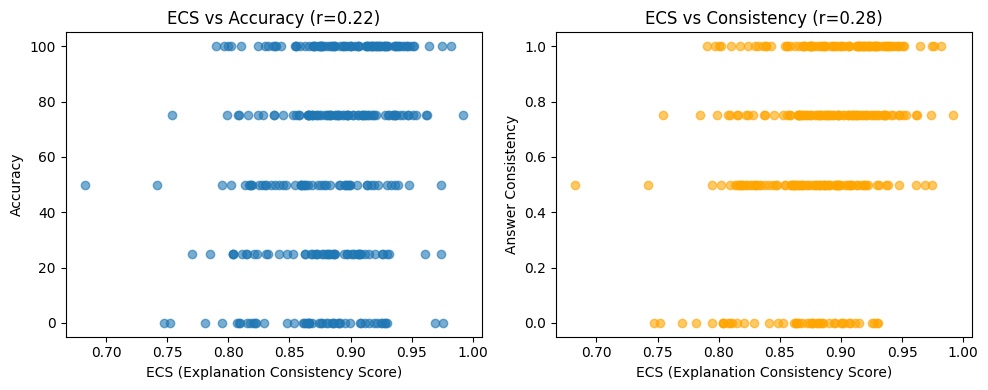

In [1008]:
import pandas as pd
from scipy.stats import pearsonr, spearmanr
import numpy as np

# === 1. Load both datasets ===
ecs_df = pd.read_csv("gsm8k/gsm8k_mistral7B_ECS.csv")
acc_df = pd.read_csv("gsm8k/gsm8k_mistral7B_Accuracy_Consistency.csv")
    
# Ensure 'id' is of same type
ecs_df['id'] = ecs_df['id'].astype(str)
acc_df['id'] = acc_df['id'].astype(str)

# === 2. Merge by ID ===
merged = pd.merge(acc_df, ecs_df[['id', 'ECS']], on='id', how='inner')

print(f"✅ Merged {len(merged)} examples across both datasets")

# === 3. Drop rows with missing ECS or accuracy ===
merged = merged.dropna(subset=['ECS', 'accuracy', 'answer_consistency'])

# === 4. Compute correlations ===
pearson_acc, _ = pearsonr(merged['ECS'], merged['accuracy'])
spearman_acc, _ = spearmanr(merged['ECS'], merged['accuracy'])

pearson_cons, _ = pearsonr(merged['ECS'], merged['answer_consistency'])
spearman_cons, _ = spearmanr(merged['ECS'], merged['answer_consistency'])

# === 5. Print results ===
print("\n📊 Faithfulness Correlation Analysis")
print("----------------------------------------")
print(f"🔹 ECS ↔ Accuracy:")
print(f"   Pearson:  {pearson_acc:.3f}")
print(f"   Spearman: {spearman_acc:.3f}")

print(f"\n🔹 ECS ↔ Answer Consistency:")
print(f"   Pearson:  {pearson_cons:.3f}")
print(f"   Spearman: {spearman_cons:.3f}")

# === 6. Optional: quick visual sanity check ===
try:
    import matplotlib.pyplot as plt
    plt.figure(figsize=(10,4))
    plt.subplot(1,2,1)
    plt.scatter(merged['ECS'], merged['accuracy'], alpha=0.6)
    plt.xlabel("ECS (Explanation Consistency Score)")
    plt.ylabel("Accuracy")
    plt.title(f"ECS vs Accuracy (r={pearson_acc:.2f})")

    plt.subplot(1,2,2)
    plt.scatter(merged['ECS'], merged['answer_consistency'], alpha=0.6, color='orange')
    plt.xlabel("ECS (Explanation Consistency Score)")
    plt.ylabel("Answer Consistency")
    plt.title(f"ECS vs Consistency (r={pearson_cons:.2f})")

    plt.tight_layout()
    plt.show()
except:
    pass


**Remove repeated answers of Llama3**

In [51]:
# =====================================================
# 🧹 Clean LLaMA-3 CoTs: keep reasoning + exactly one real "Final Answer"
# =====================================================
# Logic:
# → If first "Final Answer:" is a placeholder, skip to the next real one.
# → Keep reasoning + the true answer + anything that comes after (notes, etc.).
# → Remove any *later repeated* "Final Answer:" sections.

import os
import re
import pandas as pd

# === Configure paths ===
INPUT_FILE  = "gsm8k_llama3_CoT_responses_merged.csv"
OUTPUT_FILE = "gsm8k_llama3_CoT_responses_merged_clean.csv"

FINAL_ANSWER_RE = re.compile(r'(?i)final\s*answer\s*:')
PLACEHOLDER_RE = re.compile(r"<\s*(number|num|expression|ans)\s*[^>]*>", re.IGNORECASE)

def clean_one(text: str) -> str:
    """Keep reasoning and exactly one valid 'Final Answer:' section."""
    if not isinstance(text, str) or not text.strip():
        return text

    matches = list(FINAL_ANSWER_RE.finditer(text))
    if not matches:
        return text.strip()

    # Case 1: Only one Final Answer
    if len(matches) == 1:
        return text.strip()

    # Case 2: Multiple Final Answers
    first_match = matches[0]
    following_text = text[first_match.end():].strip()

    # If first is a placeholder like "<number or expression>", skip it
    if PLACEHOLDER_RE.match(following_text):
        if len(matches) >= 2:
            start = matches[1].start()  # start from the 2nd (real) Final Answer
        else:
            start = matches[0].start()
    else:
        start = matches[0].start()

    # Now find if there is another "Final Answer:" *after* the real one
    # to cut repeated answers, not legitimate notes
    subsequent = [m for m in matches if m.start() > start + 10]
    if subsequent:
        cut = subsequent[0].start()  # stop before repeated "Final Answer:"
    else:
        cut = len(text)  # keep all (includes Note:)

    return text[:cut].rstrip()


def main():
    if not os.path.exists(INPUT_FILE):
        raise FileNotFoundError(f"❌ INPUT_FILE not found: {INPUT_FILE}")

    df = pd.read_csv(INPUT_FILE)

    cot_cols = [c for c in df.columns if c.startswith("cot_")]
    changed_counts = {c: 0 for c in cot_cols}

    for c in cot_cols:
        original_series = df[c].astype(str)
        cleaned_series = original_series.apply(clean_one)
        changed_counts[c] = (original_series != cleaned_series).sum()
        df[c] = cleaned_series

    df.to_csv(OUTPUT_FILE, index=False, encoding="utf-8")

    print(f"\n✅ Cleaned LLaMA-3 CoTs saved to: {OUTPUT_FILE}")
    for c in cot_cols:
        print(f"  - Modified rows in {c}: {changed_counts[c]}")

if __name__ == "__main__":
    main()




✅ Cleaned LLaMA-3 CoTs saved to: gsm8k_llama3_CoT_responses_merged_clean.csv
  - Modified rows in cot_original: 81
  - Modified rows in cot_lexical: 81
  - Modified rows in cot_syntactic: 93
  - Modified rows in cot_contextual: 105


**Llama3 Accuracy calculation**

In [ ]:
import pandas as pd
import re
import math

# =====================================================
# STEP 1: Load data
# =====================================================
gsm8k_df = pd.read_csv("gsm8k_500_rows_with_answers.csv")
llm_df = pd.read_csv("gsm8k_llama3_CoT_responses_merged_clean.csv")

assert len(gsm8k_df) == len(llm_df), f"Mismatch: {len(gsm8k_df)} gold vs {len(llm_df)} model rows"

# =====================================================
# STEP 2: Helper functions
# =====================================================

def extract_gsm8k_answer(text):
    """Extract the gold answer after '####'."""
    match = re.search(r"####\s*(.*)", str(text))
    return match.group(1).strip() if match else None


def extract_llm_answer(text):
    """
    Extract the numeric final answer that follows the *exact* phrase 'Final Answer:'.
    - Only uses 'Final Answer:' (case-sensitive)
    - Skips placeholders like <number or expression>
    - Handles comma-formatted numbers like 6,000
    """
    if not isinstance(text, str):
        return None
    s = text.strip()

    # Strictly match 'Final Answer:' (not lowercase variants)
    pattern = re.compile(r"Final Answer\s*:\s*(.*)")
    matches = list(pattern.finditer(s))
    if not matches:
        return None

    # Extract text after the first 'Final Answer:'
    after = matches[0].group(1).strip()

    # If placeholder-like content — skip to the next "Final Answer:"
    placeholder_re = re.compile(r"^<\s*(number|num|expression|ans)\s*[^>]*>$", re.IGNORECASE)
    if placeholder_re.match(after) and len(matches) > 1:
        after = matches[1].group(1).strip()

    # Remove commas in numbers for easier parsing (e.g., 6,000 -> 6000)
    after_clean = re.sub(r"(?<=\d),(?=\d)", "", after)

    # Try to directly find numeric info in that line
    num_match = re.search(r"[-+]?\d*\.?\d+(?:/\d+)?", after_clean)
    if num_match:
        return num_match.group(0)

    # If not found, maybe the number is on the next line
    lines = s.splitlines()
    for i, line in enumerate(lines):
        if "Final Answer:" in line:
            # Look at the next non-empty line
            for j in range(i + 1, len(lines)):
                next_line = lines[j].strip()
                if not next_line:
                    continue
                next_line = re.sub(r"(?<=\d),(?=\d)", "", next_line)
                num_match = re.search(r"[-+]?\d*\.?\d+(?:/\d+)?", next_line)
                if num_match:
                    return num_match.group(0)
                break
            break

    return None


def normalize_answer(ans):
    """Normalize numeric or text answers (handles commas, decimals, fractions)."""
    if ans is None:
        return None
    ans = ans.strip().lower().replace(",", "")  # ✅ Remove commas globally
    # Extract numeric substring if any
    match = re.search(r"[-+]?\d*\.?\d+(?:/\d+)?", ans)
    if match:
        return match.group(0)
    return ans


def answers_equal(a, b, tol=1e-6):
    """Smart equality: compare numerically when possible, else by string."""
    if a is None or b is None:
        return False
    try:
        fa, fb = float(a), float(b)
        return math.isclose(fa, fb, rel_tol=tol, abs_tol=tol)
    except ValueError:
        return str(a).strip().lower() == str(b).strip().lower()


# =====================================================
# STEP 3: Extract and compare
# =====================================================
results = []

for i in range(len(gsm8k_df)):
    correct = extract_gsm8k_answer(gsm8k_df.loc[i, "answer"])
    correct_norm = normalize_answer(correct)

    row = {"id": i + 1, "correct_answer": correct_norm}
    correctness = []

    for col in ["cot_original", "cot_lexical", "cot_syntactic", "cot_contextual"]:
        llm_ans = extract_llm_answer(llm_df.loc[i, col])
        llm_norm = normalize_answer(llm_ans)
        row[f"{col}_extracted"] = llm_norm
        correctness.append(int(answers_equal(llm_norm, correct_norm)))

    row["average_accuracy"] = sum(correctness) / len(correctness)
    results.append(row)

compare_df = pd.DataFrame(results)

# =====================================================
# STEP 4: Compute accuracy
# =====================================================
accuracy = {
    col: (
        compare_df.apply(
            lambda r: answers_equal(r[f"{col}_extracted"], r["correct_answer"]), axis=1
        ).mean() * 100
    )
    for col in ["cot_original", "cot_lexical", "cot_syntactic", "cot_contextual"]
}

print("\n✅ Accuracy Results (%):")
for k, v in accuracy.items():
    print(f"{k}: {v:.2f}%")

# =====================================================
# STEP 5: Save summary
# =====================================================
compare_df.to_csv("gsm8k_llama3_CoT_comparison_summary.csv", index=False)
print("\n🎉 Saved summary to 'gsm8k_llama3_CoT_comparison_summary.csv'")
print(compare_df.head(3))



**Llama3 Consistency calculation**

In [ ]:
import pandas as pd
import re
import math
from statistics import mode

# =====================================================
# STEP 1: Load data
# =====================================================
gsm8k_df = pd.read_csv("gsm8k_500_rows_with_answers.csv")
llm_df = pd.read_csv("gsm8k_llama3_CoT_responses_merged_clean.csv")

assert len(gsm8k_df) == len(llm_df), f"Mismatch: {len(gsm8k_df)} gold vs {len(llm_df)} model rows"

# =====================================================
# STEP 2: Helper functions
# =====================================================

def extract_gsm8k_answer(text):
    """Extract the gold answer after '####'."""
    match = re.search(r"####\s*(.*)", str(text))
    return match.group(1).strip() if match else None


def extract_llm_answer(text):
    """
    Extract the numeric final answer that follows the *exact* phrase 'Final Answer:'.
    - Only uses 'Final Answer:' (case-sensitive)
    - Skips placeholders like <number or expression>
    - Handles comma-formatted numbers like 6,000
    """
    if not isinstance(text, str):
        return None
    s = text.strip()

    # Strictly match 'Final Answer:' (case-sensitive)
    pattern = re.compile(r"Final Answer\s*:\s*(.*)")
    matches = list(pattern.finditer(s))
    if not matches:
        return None

    # Extract text after the first 'Final Answer:'
    after = matches[0].group(1).strip()

    # Skip placeholders like <number or expression>
    placeholder_re = re.compile(r"^<\s*(number|num|expression|ans)\s*[^>]*>$", re.IGNORECASE)
    if placeholder_re.match(after) and len(matches) > 1:
        after = matches[1].group(1).strip()

    # Remove commas for easier parsing (e.g., 6,000 → 6000)
    after_clean = re.sub(r"(?<=\d),(?=\d)", "", after)

    # Try to directly find numeric info
    num_match = re.search(r"[-+]?\d*\.?\d+(?:/\d+)?", after_clean)
    if num_match:
        return num_match.group(0)

    # If not found, maybe on the next line
    lines = s.splitlines()
    for i, line in enumerate(lines):
        if "Final Answer:" in line:
            for j in range(i + 1, len(lines)):
                next_line = lines[j].strip()
                if not next_line:
                    continue
                next_line = re.sub(r"(?<=\d),(?=\d)", "", next_line)
                num_match = re.search(r"[-+]?\d*\.?\d+(?:/\d+)?", next_line)
                if num_match:
                    return num_match.group(0)
                break
            break

    return None


def normalize_answer(ans):
    """Normalize numeric or text answers (handles commas, decimals, fractions)."""
    if ans is None:
        return None
    ans = ans.strip().lower().replace(",", "")
    match = re.search(r"[-+]?\d*\.?\d+(?:/\d+)?", ans)
    if match:
        return match.group(0)
    return ans


def answers_equal(a, b, tol=1e-6):
    """Compare answers numerically when possible, else by string."""
    if a is None or b is None:
        return False
    try:
        fa, fb = float(a), float(b)
        return math.isclose(fa, fb, rel_tol=tol, abs_tol=tol)
    except ValueError:
        return str(a).strip().lower() == str(b).strip().lower()


# --------- Numeric consistency aware function ---------
def _to_float_or_none(x: str):
    """Try to parse as float (supports fractions)."""
    if x is None:
        return None
    xs = str(x).strip().lower().replace(",", "")
    frac = re.fullmatch(r"([-+]?\d+)\s*/\s*(\d+)", xs)
    if frac:
        num = float(frac.group(1))
        den = float(frac.group(2))
        if den != 0:
            return num / den
        return None
    try:
        return float(xs)
    except ValueError:
        return None


def numeric_consistency_fraction(ans_list, tol=1e-6):
    """
    Consistency = fraction of identical (numeric-aware) answers out of 4.
    Always uses denominator = 4 (total perturbations).
    Fully distinct answers → 0.0 (not 0.25).
    """
    n_total = 4  # Always expect 4 perturbations
    vals = [a for a in ans_list if a not in [None, ""]]
    if len(vals) == 0:
        return 0.0

    # Cluster numeric-equivalent answers
    clusters = []
    for a in vals:
        a_num = _to_float_or_none(a)
        placed = False
        for cl in clusters:
            if cl['repr_num'] is not None and a_num is not None:
                if math.isclose(cl['repr_num'], a_num, rel_tol=tol, abs_tol=tol):
                    cl['count'] += 1
                    placed = True
                    break
            elif cl['repr_num'] is None and a_num is None:
                if str(cl['repr_str']).strip().lower() == str(a).strip().lower():
                    cl['count'] += 1
                    placed = True
                    break
        if not placed:
            clusters.append({
                'repr_num': a_num if a_num is not None else None,
                'repr_str': None if a_num is not None else str(a).strip().lower(),
                'count': 1
            })

    max_count = max(cl['count'] for cl in clusters)

    # If all answers differ (max_count == 1) → consistency = 0
    if max_count == 1:
        return 0.0

    # Normalize by 4 (even if some answers missing)
    return max_count / n_total
# ------------------------------------------------------


# =====================================================
# STEP 3: Extract, Compare, Compute Consistency
# =====================================================
results = []

for i in range(len(gsm8k_df)):
    correct = extract_gsm8k_answer(gsm8k_df.loc[i, "answer"])
    correct_norm = normalize_answer(correct)

    row = {"id": i + 1, "correct_answer": correct_norm}
    correctness = []
    llm_answers = []

    for col in ["cot_original", "cot_lexical", "cot_syntactic", "cot_contextual"]:
        llm_ans = extract_llm_answer(llm_df.loc[i, col])
        llm_norm = normalize_answer(llm_ans)
        row[f"{col}_extracted"] = llm_norm
        llm_answers.append(llm_norm)
        correctness.append(int(answers_equal(llm_norm, correct_norm)))

    # --- Accuracy across perturbations ---
    row["average_accuracy"] = sum(correctness) / len(correctness)

    # --- Consistency (numeric-aware, robust to missing) ---
    row["answer_consistency"] = numeric_consistency_fraction(llm_answers)

    results.append(row)

compare_df = pd.DataFrame(results)

# =====================================================
# STEP 4: Compute accuracy + consistency summary
# =====================================================
accuracy = {
    col: (
        compare_df.apply(
            lambda r: answers_equal(r[f"{col}_extracted"], r["correct_answer"]), axis=1
        ).mean() * 100
    )
    for col in ["cot_original", "cot_lexical", "cot_syntactic", "cot_contextual"]
}

avg_consistency = compare_df["answer_consistency"].mean() * 100

print("\n✅ Accuracy Results (%):")
for k, v in accuracy.items():
    print(f"{k}: {v:.2f}%")

print(f"\n🔁 Average Answer Consistency Across Perturbations (fixed): {avg_consistency:.2f}%")

# =====================================================
# STEP 5: Save summary
# =====================================================
compare_df.to_csv("gsm8k_llama3_results.csv", index=False)
print("\n🎉 Saved summary to 'gsm8k_llama3_results.csv'")
print(compare_df.head(3))


**Llama3 ECS**

In [91]:
import pandas as pd
import numpy as np
from itertools import combinations
from tqdm import tqdm
from sklearn.metrics.pairwise import cosine_similarity
from sentence_transformers import SentenceTransformer

# =====================================================
# STEP 1: Load data
# =====================================================
llm_df = pd.read_csv("gsm8k_llama3_CoT_responses_merged_clean.csv")

print(f"✅ Loaded {len(llm_df)} examples from LLaMA-3 CoT results.")

# =====================================================
# STEP 2: Initialize embedding model
# =====================================================
print("🚀 Loading embedding model: all-MiniLM-L6-v2 ...")
model = SentenceTransformer('all-MiniLM-L6-v2')

# =====================================================
# STEP 3: Define ECS computation function
# =====================================================
def compute_ecs_semantic(rationales):
    """
    Compute the Explanation Consistency Score (ECS):
    mean cosine similarity between all pairs of explanations (semantic meaning).

    rationales: list of strings (rationales from perturbed questions)
    returns: mean pairwise cosine similarity (float)
    """
    texts = [t for t in rationales if isinstance(t, str) and t.strip()]
    if len(texts) < 2:
        return np.nan

    pairs = list(combinations(texts, 2))
    sim_scores = []

    for a, b in pairs:
        # Encode both texts as embeddings
        emb = model.encode([a, b], normalize_embeddings=True)
        sem_sim = float(np.dot(emb[0], emb[1]))  # cosine similarity (faster than sklearn)
        sim_scores.append(sem_sim)

    return np.mean(sim_scores)

# =====================================================
# STEP 4: Compute ECS with progress bar
# =====================================================
ecs_scores = []

print("🧠 Computing ECS (semantic consistency) for each example...")
for _, row in tqdm(llm_df.iterrows(), total=len(llm_df)):
    ecs = compute_ecs_semantic([
        row.get('cot_original'),
        row.get('cot_lexical'),
        row.get('cot_syntactic'),
        row.get('cot_contextual')
    ])
    ecs_scores.append(ecs)

llm_df['ECS'] = ecs_scores

# =====================================================
# STEP 5: Compute overall ECS mean
# =====================================================
overall_ecs = np.nanmean(llm_df['ECS'])
print(f"\n🔍 Average Explanation Consistency Score (ECS): {overall_ecs:.3f}")

# =====================================================
# STEP 6: Save to CSV
# =====================================================
output_file = "gsm8k_llama3_ECS_scores.csv"
llm_df.to_csv(output_file, index=False)
print(f"💾 Saved ECS-annotated results to {output_file}")




📂 Loading file: gsm8k_llama3_CoT_comparison_with_consistency.csv
✅ Loaded 500 rows

🚀 Loading embedding model: all-MiniLM-L6-v2 ...
🧩 Using columns for ECS: ['cot_original_extracted', 'cot_lexical_extracted', 'cot_syntactic_extracted', 'cot_contextual_extracted']
🧠 Computing ECS for each example...


100%|█████████████████████████████████████████| 500/500 [00:16<00:00, 29.94it/s]


🔍 Average ECS: 0.828 (min=0.315, max=1.000)
💾 Saved updated file with ECS to: gsm8k_llama3_CoT_comparison_with_consistency.csv


**Llama3 Merge ECS , Accuracy , Consistency**

In [ ]:
import pandas as pd

# =====================================================
# STEP 1: Load both CSV files
# =====================================================
ecs_file = "gsm8k_llama3_ECS_scores.csv"
main_file = "gsm8k_llama3_results.csv"

print(f"📂 Loading ECS file: {ecs_file}")
ecs_df = pd.read_csv(ecs_file)

print(f"📂 Loading main comparison file: {main_file}")
main_df = pd.read_csv(main_file)

# =====================================================
# STEP 2: Sanity check
# =====================================================
if len(ecs_df) != len(main_df):
    raise ValueError(f"❌ Row count mismatch: ECS file has {len(ecs_df)}, main file has {len(main_df)}")

print(f"✅ Both files have {len(main_df)} rows — proceeding with merge")

# =====================================================
# STEP 3: Extract ECS column
# =====================================================
if "ECS" not in ecs_df.columns:
    raise ValueError("❌ The ECS file does not contain an 'ECS' column!")

main_df["ECS"] = ecs_df["ECS"]

# =====================================================
# STEP 4: Save merged results
# =====================================================
output_file = main_file  # overwrite or change if you prefer a backup
main_df.to_csv(output_file, index=False)
print(f"💾 Successfully appended ECS column to {output_file}")

# Optional: quick preview
print("\n✅ Sample of merged file:")
print(main_df.head(3))


**Llama3 Filter Unwanted Examples**

In [406]:
import pandas as pd

# =====================================================
# STEP 1: Load both CSV files
# =====================================================
ecs_file = "gsm8k/gsm8k_llama3_ECS_scores.csv"
main_file = "gsm8k/gsm8k_llama3_results.csv"
output_file = "gsm8k/gsm8k_llama3_results_filtered.csv"  # NEW FILE

print(f"📂 Loading ECS file: {ecs_file}")
ecs_df = pd.read_csv(ecs_file)

print(f"📂 Loading main comparison file: {main_file}")
main_df = pd.read_csv(main_file)

# =====================================================
# STEP 2: Sanity check
# =====================================================
if len(ecs_df) != len(main_df):
    raise ValueError(f"❌ Row count mismatch: ECS file has {len(ecs_df)}, main file has {len(main_df)}")

print(f"✅ Both files have {len(main_df)} rows — proceeding with merge")

# =====================================================
# STEP 3: Add ECS column
# =====================================================
if "ECS" not in ecs_df.columns:
    raise ValueError("❌ The ECS file does not contain an 'ECS' column!")

main_df["ECS"] = ecs_df["ECS"]

# =====================================================
# STEP 4: Remove unwanted IDs
# =====================================================
#remove_ids = [
 #   7, 30, 36, 46, 47, 66, 82, 98, 103, 106, 110, 120, 127,
  #  150, 160, 168, 177, 209, 219, 230, 265, 287, 291, 309,
   # 357, 367, 369, 378, 384, 403, 420, 489,#plain

    #36,51,75,63,69,92,93,100,112,115,116,125,130,170,183,219,225,237,257,271,
    #303,311,315,347,348,350,357,367,369,371,374,454,460,462,488,489,499
#]



remove_ids = [
    2,7,27, 30, 36, 46, 47, 66, 82,85, 98, 103, 106, 110,111, 120,123, 127,128,135,143,145,146,149,
    150, 160, 168, 177, 190 ,196,204,207,209,212,214, 219,221,224, 229,230,238,263, 265,277,282,285,286, 287, 289,291, 309,314,317,323,326,336,339,340,342,352,355,
    357,362, 367, 369,376, 378,380, 384,385,398, 403, 416,420,424,425,431, 434,439,442,468,471,487,489, 492,
    36,51,75,63,69,92,93,100,112,115,116,125,130,170,183,215,219,225,237,257,271,
    303,311,315,332,347,348,350,357,367,369,371,372,374,445,454,460,462,488,489,499
]

# Ensure IDs are same type
main_df['id'] = main_df['id'].astype(str)
remove_ids = [str(i) for i in remove_ids]

# Remove matching rows
filtered_df = main_df[~main_df['id'].isin(remove_ids)].reset_index(drop=True)

# =====================================================
# STEP 5: Save filtered results to NEW file
# =====================================================
filtered_df.to_csv(output_file, index=False)

# =====================================================
# STEP 6: Report summary
# =====================================================
print(f"💾 Saved filtered results to: {output_file}")
print(f"🧹 Removed {len(remove_ids)} specific IDs")
print(f"📊 Final row count in new file: {len(filtered_df)}")




📂 Loading ECS file: gsm8k/gsm8k_llama3_ECS_scores.csv
📂 Loading main comparison file: gsm8k/gsm8k_llama3_results.csv
✅ Both files have 500 rows — proceeding with merge
💾 Saved filtered results to: gsm8k/gsm8k_llama3_results_filtered.csv
🧹 Removed 126 specific IDs
📊 Final row count in new file: 380


**Final Results Llama3**


✅ Loaded 380 valid rows for correlation analysis
🔹 Average of 'average_accuracy' column: 81.12%
🔹 Average of 'answer_consistency' column: 83.03%

📈 Per-column accuracies (vs correct_answer):
   cot_original: 82.37%
   cot_lexical: 82.63%
   cot_syntactic: 80.79%
   cot_contextual: 78.68%

📊 Faithfulness Correlation Analysis (LLaMA-3)
------------------------------------------------
🔹 ECS ↔ Average Accuracy:
   Pearson correlation:  0.299
   Spearman correlation: 0.341

🔹 ECS ↔ Answer Consistency:
   Pearson correlation:  0.307
   Spearman correlation: 0.342


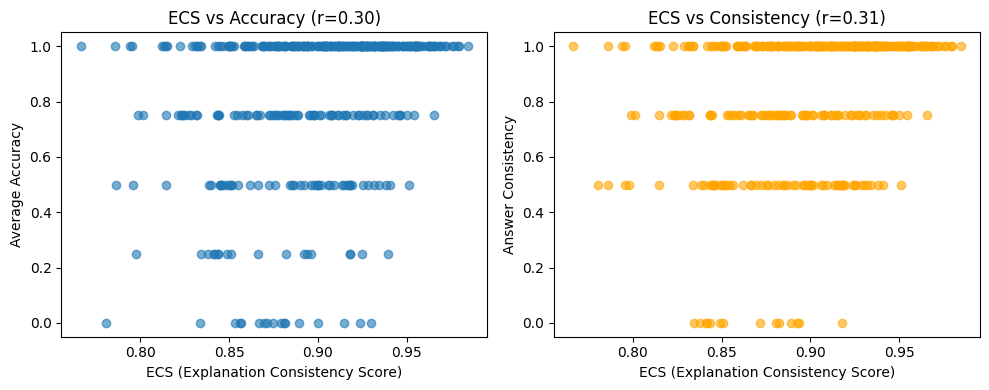

In [407]:
import pandas as pd
from scipy.stats import pearsonr, spearmanr
import matplotlib.pyplot as plt

# === 1. Load the dataset ===
file_path = "gsm8k/gsm8k_llama3_results_filtered.csv"
df = pd.read_csv(file_path)


# === Step 1: Compute overall averages ===
overall_avg_accuracy = df["average_accuracy"].mean()
avg_answer_consistency = df["answer_consistency"].mean()

# === Step 2: Compare each column (original, lexical, syntactic, contextual) against correct_answer ===
def is_correct(pred, truth):
    """Return True if numeric or string match."""
    try:
        return float(pred) == float(truth)
    except:
        return str(pred).strip() == str(truth).strip()

cot_cols = ["cot_original_extracted", "cot_lexical_extracted",
            "cot_syntactic_extracted", "cot_contextual_extracted"]

column_accuracies = {}

for col in cot_cols:
    matches = df.apply(lambda r: is_correct(r[col], r["correct_answer"]), axis=1)
    column_accuracies[col] = matches.mean() * 100  # convert to percentage

print(f"\n✅ Loaded {len(df)} valid rows for correlation analysis")
print(f"🔹 Average of 'average_accuracy' column: {overall_avg_accuracy * 100:.2f}%")
print(f"🔹 Average of 'answer_consistency' column: {avg_answer_consistency * 100:.2f}%\n")

print("📈 Per-column accuracies (vs correct_answer):")
for col, acc in column_accuracies.items():
    short_name = col.replace("_extracted", "")
    print(f"   {short_name}: {acc:.2f}%")
    

# === 2. Drop rows with missing values ===
df = df.dropna(subset=['ECS', 'average_accuracy', 'answer_consistency'])



# === 3. Compute correlations ===
pearson_acc, _ = pearsonr(df['ECS'], df['average_accuracy'])
spearman_acc, _ = spearmanr(df['ECS'], df['average_accuracy'])

pearson_cons, _ = pearsonr(df['ECS'], df['answer_consistency'])
spearman_cons, _ = spearmanr(df['ECS'], df['answer_consistency'])

# === 4. Print correlation results ===
print("\n📊 Faithfulness Correlation Analysis (LLaMA-3)")
print("------------------------------------------------")
print(f"🔹 ECS ↔ Average Accuracy:")
print(f"   Pearson correlation:  {pearson_acc:.3f}")
print(f"   Spearman correlation: {spearman_acc:.3f}")

print(f"\n🔹 ECS ↔ Answer Consistency:")
print(f"   Pearson correlation:  {pearson_cons:.3f}")
print(f"   Spearman correlation: {spearman_cons:.3f}")

# === 5. Optional visualization ===
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.scatter(df['ECS'], df['average_accuracy'], alpha=0.6)
plt.xlabel("ECS (Explanation Consistency Score)")
plt.ylabel("Average Accuracy")
plt.title(f"ECS vs Accuracy (r={pearson_acc:.2f})")

plt.subplot(1,2,2)
plt.scatter(df['ECS'], df['answer_consistency'], alpha=0.6, color='orange')
plt.xlabel("ECS (Explanation Consistency Score)")
plt.ylabel("Answer Consistency")
plt.title(f"ECS vs Consistency (r={pearson_cons:.2f})")

plt.tight_layout()
plt.show()


**Gemini Accuracy**

In [132]:
# =====================================================
# 📘 Gemini CoT: Extract Final Answer + Compute Accuracy (robust numeric parsing)
# =====================================================

!pip -q install pandas numpy tqdm

import pandas as pd
import numpy as np
import re
from decimal import Decimal, InvalidOperation
from tqdm import tqdm

# =====================================================
# STEP 1: Load data
# =====================================================
gsm8k_df = pd.read_csv("gsm8k_500_rows_with_answers.csv")
llm_df   = pd.read_csv("gsm8k_gemini_CoT_responses_merged.csv")

assert len(gsm8k_df) == len(llm_df), f"❌ Mismatch in rows! GSM8K={len(gsm8k_df)}, Gemini={len(llm_df)}"
print(f"✅ Loaded {len(llm_df)} Gemini CoT examples with gold answers.")

# =====================================================
# STEP 2: Helper functions
# =====================================================

def extract_gsm8k_answer(text):
    """Extract gold answer from GSM8K after '####'."""
    if not isinstance(text, str):
        return None
    m = re.search(r"####\s*(.*)", text)
    return m.group(1).strip() if m else None


def extract_gemini_answer(text):
    """
    Strictly extract the final numeric answer from Gemini's rationale.

    Handles:
      - The final answer is $\\boxed{96}$.
      - Final Answer: 96
      - Final Answer = $\\boxed{25 \\text{ cm}}$ → returns '25'
      - Final Answer: $6,000 → returns '6000'
      - The final answer is 42.
    Returns only the numeric portion (e.g., '96', '25', '6000', '42').
    """
    if not isinstance(text, str):
        return None

    s = text.strip()

    # ✅ Explicit "Final Answer" patterns (Gemini common)
    patterns = [
        r"[Tt]he\s+final\s+answer\s+is\s+\\?\$?\\?boxed\{?([^\}\$]+)\}?",   # The final answer is ...
        r"[Ff]inal\s+[Aa]nswer\s*[:=\-–—]?\s*\\?\$?\\?boxed\{?([^\}\$]+)\}?",  # Final Answer: ...
        r"[Tt]he\s+final\s+answer\s+is\s+([^\n\r]*)",  # The final answer is 96.
        r"[Ff]inal\s+[Aa]nswer\s*[:=\-–—]?\s*([^\n\r]*)",  # Final Answer: 96
    ]

    for pat in patterns:
        m = re.search(pat, s)
        if m:
            candidate = m.group(1).strip()

            # 🧹 Clean text from LaTeX artifacts and symbols
            candidate = re.sub(r"\\text\{[^}]*\}", "", candidate)
            candidate = candidate.replace(",", "")  # <-- keep numbers intact (e.g., 6,000 → 6000)
            candidate = re.sub(r"[^0-9\.\-+]", " ", candidate)  # keep only digits, ., +, -
            candidate = candidate.strip()

            # 🎯 Extract first full numeric token
            num_match = re.search(r"[-+]?\d*\.?\d+", candidate)
            if num_match:
                return num_match.group(0)

    # 🚫 No explicit final-answer phrase found
    return None



def to_decimal(s):
    """Safely convert to Decimal (for numeric comparison)."""
    if s is None:
        return None
    t = str(s).strip().lower()
    t = re.sub(r"^[\s$€£]+", "", t)
    t = t.replace(",", "")
    if re.fullmatch(r"[-+]?\d+\.", t):
        t = t[:-1]
    try:
        return Decimal(t)
    except InvalidOperation:
        return None


def format_decimal_clean(d: Decimal) -> str:
    """Convert Decimal to clean string (no exponent, no trailing zeros)."""
    s = format(d, 'f')
    if '.' in s:
        s = s.rstrip('0').rstrip('.')
    return s


def normalize_for_report(ans):
    """Canonical clean version for CSV storage."""
    d = to_decimal(ans)
    if d is not None:
        return format_decimal_clean(d)
    if ans is None:
        return None
    return str(ans).strip().rstrip(" .")


def answers_equal(a, b, tol=Decimal("1e-9")) -> bool:
    """Compare numerically (within tolerance) or textually if non-numeric."""
    da, db = to_decimal(a), to_decimal(b)
    if da is not None and db is not None:
        return (da - db).copy_abs() <= tol
    sa = str(a).strip().lower() if a else ""
    sb = str(b).strip().lower() if b else ""
    return sa == sb


# =====================================================
# STEP 3: Extract & Compare Answers
# =====================================================
results = []

print("🔍 Extracting and comparing Gemini answers with GSM8K gold...")
for i in tqdm(range(len(gsm8k_df))):
    gold_raw = extract_gsm8k_answer(gsm8k_df.loc[i, "answer"])
    gold_norm = normalize_for_report(gold_raw)

    row = {"id": gsm8k_df.loc[i, "id"], "correct_answer": gold_norm}
    correctness = []

    for col in ["cot_original", "cot_lexical", "cot_syntactic", "cot_contextual"]:
        llm_raw = extract_gemini_answer(llm_df.loc[i, col])
        llm_norm = normalize_for_report(llm_raw)
        row[f"{col}_extracted"] = llm_norm
        correctness.append(int(answers_equal(llm_norm, gold_norm)))

    row["average_accuracy"] = sum(correctness) / len(correctness)
    results.append(row)

compare_df = pd.DataFrame(results)

# =====================================================
# STEP 4: Compute Overall Accuracy
# =====================================================
def col_accuracy(col):
    return (
        compare_df.apply(
            lambda r: answers_equal(r["correct_answer"], r[f"{col}_extracted"]),
            axis=1,
        ).mean()
        * 100
    )

accuracy = {col: col_accuracy(col) for col in ["cot_original", "cot_lexical", "cot_syntactic", "cot_contextual"]}

print("\n✅ Accuracy Results (%):")
for k, v in accuracy.items():
    print(f"{k}: {v:.2f}%")

# =====================================================
# STEP 5: Save
# =====================================================
output_file = "gsm8k_gemini_CoT_comparison_summary.csv"
compare_df.to_csv(output_file, index=False)





huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


✅ Loaded 500 Gemini CoT examples with gold answers.
🔍 Extracting and comparing Gemini answers with GSM8K gold...


100%|██████████████████████████████████████| 500/500 [00:00<00:00, 11602.31it/s]


✅ Accuracy Results (%):
cot_original: 95.00%
cot_lexical: 92.80%
cot_syntactic: 90.60%
cot_contextual: 88.40%


**remove faulty answers**

In [976]:
# =====================================================
# 📘 Filter Out Specific IDs and Save Corrected Gemini CoT File
# =====================================================

import pandas as pd

# Step 1: Load original file
input_file = "gsm8k/gsm8k_gemini_CoT_responses_merged.csv"
output_file = "gsm8k/gsm8k_gemini_CoT_responses_correct.csv"

df = pd.read_csv(input_file)
print(f"✅ Loaded {len(df)} rows from {input_file}")

# Step 2: IDs to remove
#remove_ids = [
 #   7, 47, 61, 66, 90, 107, 111, 123, 143, 146, 150, 159, 166, 172, 209, 212, 214, 263, 284, 287, 288, 297, 306, 309, 319, 320, 328, 334, 345, 362, 468, 471, 475, 487, #empty
  #  36,51,63,69,75,92,93,100,112,115,116,125,130,170,183,219,225,237,257,271,
   # 303,311,315,347,348,350,357,367,369,371,374,454,460,462,488,489,499
#]
remove_ids = [
    7, 47, 61, 66, 90,103, 107, 111, 123, 132,143, 146, 150, 159, 166, 172,177, 209, 212, 214,235,260 ,263, 284, 287, 288, 297, 306, 309, 319, 320, 328, 334, 345, 362, 468, 471, 475, 487, #empty
    36,51,63,69,75,92,93,100,112,115,116,125,130,170,183,219,207,225,237,257,259,271,273,
    303,311,315,347,348,350,357,364,367,369,371,374,376,409,454,460,462,484,488,489,499
]
# Step 3: Filter out unwanted rows
filtered_df = df[~df["id"].isin(remove_ids)].copy()
print(f"🧹 Removed {len(df) - len(filtered_df)} rows. Remaining: {len(filtered_df)}")

# Step 4: Save to new file
filtered_df.to_csv(output_file, index=False, encoding="utf-8")
print(f"💾 Saved corrected file to {output_file}")


✅ Loaded 500 rows from gsm8k/gsm8k_gemini_CoT_responses_merged.csv
🧹 Removed 83 rows. Remaining: 417
💾 Saved corrected file to gsm8k/gsm8k_gemini_CoT_responses_correct.csv


**Gemini ECS**

In [977]:
# =====================================================
# 📊 Compute Explainability Consistency Score (ECS)
# for Gemini 2.5 Flash CoT Rationales
# =====================================================

!pip -q install sentence-transformers tqdm pandas numpy scikit-learn

import pandas as pd
import numpy as np
from itertools import combinations
from tqdm import tqdm
from sentence_transformers import SentenceTransformer

# =====================================================
# STEP 1: Load Gemini CoT results
# =====================================================
input_file = "gsm8k/gsm8k_gemini_CoT_responses_correct.csv"
output_file = "gsm8k/gsm8k_gemini_ECS_scores.csv"

gemini_df = pd.read_csv(input_file)
print(f"✅ Loaded {len(gemini_df)} examples from Gemini CoT results.")

# =====================================================
# STEP 2: Initialize embedding model
# =====================================================
print("🚀 Loading embedding model: all-MiniLM-L6-v2 ...")
model = SentenceTransformer("all-MiniLM-L6-v2")

# =====================================================
# STEP 3: Define ECS computation function
# =====================================================
def compute_ecs_semantic(rationales):
    """
    Compute the Explanation Consistency Score (ECS):
    mean cosine similarity between all pairs of explanations (semantic meaning).

    rationales: list of strings (rationales from perturbed questions)
    returns: mean pairwise cosine similarity (float)
    """
    texts = [t for t in rationales if isinstance(t, str) and t.strip()]
    if len(texts) < 2:
        return np.nan

    # Compute all pairwise combinations
    pairs = list(combinations(texts, 2))
    sim_scores = []

    for a, b in pairs:
        emb = model.encode([a, b], normalize_embeddings=True)
        sim = float(np.dot(emb[0], emb[1]))  # cosine similarity
        sim_scores.append(sim)

    return np.mean(sim_scores)

# =====================================================
# STEP 4: Compute ECS for each example
# =====================================================
ecs_scores = []

print("🧮 Computing ECS (semantic consistency) for each example...")
for _, row in tqdm(gemini_df.iterrows(), total=len(gemini_df)):
    ecs = compute_ecs_semantic([
        row.get("cot_original"),
        row.get("cot_lexical"),
        row.get("cot_syntactic"),
        row.get("cot_contextual"),
    ])
    ecs_scores.append(ecs)

gemini_df["ECS"] = ecs_scores

# =====================================================
# STEP 5: Compute overall ECS mean
# =====================================================
overall_ecs = np.nanmean(gemini_df["ECS"])
print(f"\n🔍 Average Explanation Consistency Score (ECS): {overall_ecs:.3f}")

# =====================================================
# STEP 6: Save results
# =====================================================
gemini_df.to_csv(output_file, index=False)
print(f"💾 Saved ECS-annotated results to {output_file}")

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)



[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: pip install --upgrade pip
✅ Loaded 417 examples from Gemini CoT results.
🚀 Loading embedding model: all-MiniLM-L6-v2 ...
🧮 Computing ECS (semantic consistency) for each example...


100%|█████████████████████████████████████████| 417/417 [01:02<00:00,  6.66it/s]



🔍 Average Explanation Consistency Score (ECS): 0.921
💾 Saved ECS-annotated results to gsm8k/gsm8k_gemini_ECS_scores.csv


**Gemini Accuracy**

In [978]:
# =====================================================
# 📘 Filter Out Specific IDs from GSM8K Gold Answers
# =====================================================

import pandas as pd

# Step 1: Load the original file
input_file = "gsm8k/gsm8k_500_rows_with_answers.csv"
output_file = "gsm8k/gsm8k_500_rows_with_answers_correct.csv"

df = pd.read_csv(input_file)
print(f"✅ Loaded {len(df)} rows from {input_file}")

# Step 2: IDs to remove
remove_ids = [
    7, 47, 61, 66, 90,103, 107, 111, 123, 132,143, 146, 150, 159, 166, 172,177, 209, 212, 214,235,260 ,263, 284, 287, 288, 297, 306, 309, 319, 320, 328, 334, 345, 362, 468, 471, 475, 487, #empty
    36,51,63,69,75,92,93,100,112,115,116,125,130,170,183,219,207,225,237,257,259,271,273,
    303,311,315,347,348,350,357,364,367,369,371,374,376,409,454,460,462,484,488,489,499
]

# Step 3: Filter out those rows
filtered_df = df[~df["id"].isin(remove_ids)].copy()
removed_count = len(df) - len(filtered_df)
print(f"🧹 Removed {removed_count} rows. Remaining: {len(filtered_df)}")

# Step 4: Save to new file
filtered_df.to_csv(output_file, index=False, encoding="utf-8")
print(f"💾 Saved corrected file to {output_file}")



✅ Loaded 500 rows from gsm8k/gsm8k_500_rows_with_answers.csv
🧹 Removed 83 rows. Remaining: 417
💾 Saved corrected file to gsm8k/gsm8k_500_rows_with_answers_correct.csv


In [979]:
# =====================================================
# 📘 Gemini CoT: Extract Final Answer + Compute Accuracy + Answer Consistency (fixed)
# =====================================================

!pip -q install pandas numpy tqdm

import pandas as pd
import numpy as np
import re
from decimal import Decimal, InvalidOperation
from tqdm import tqdm

# =====================================================
# STEP 1: Load data
# =====================================================
gsm8k_df = pd.read_csv("gsm8k/gsm8k_500_rows_with_answers_correct.csv")
llm_df   = pd.read_csv("gsm8k/gsm8k_gemini_CoT_responses_correct.csv")

assert len(gsm8k_df) == len(llm_df), f"❌ Mismatch in rows! GSM8K={len(gsm8k_df)}, Gemini={len(llm_df)}"
print(f"✅ Loaded {len(llm_df)} Gemini CoT examples with gold answers.")

# =====================================================
# STEP 2: Helper functions
# =====================================================

def extract_gsm8k_answer(text):
    """Extract gold answer from GSM8K after '####'."""
    if not isinstance(text, str):
        return None
    m = re.search(r"####\s*(.*)", text)
    return m.group(1).strip() if m else None


def extract_gemini_answer(text):
    """
    Strictly extract the final numeric answer from Gemini's rationale.
    Handles cases like:
      - The final answer is $\\boxed{96}$.
      - Final Answer: 96
      - Final Answer = $\\boxed{25 \\text{ cm}}$ → '25'
      - Final Answer: $6,000 → '6000'
      - The final answer is 42.
    """
    if not isinstance(text, str):
        return None
    s = text.strip()

    patterns = [
        r"[Tt]he\s+final\s+answer\s+is\s+\\?\$?\\?boxed\{?([^\}\$]+)\}?",
        r"[Ff]inal\s+[Aa]nswer\s*[:=\-–—]?\s*\\?\$?\\?boxed\{?([^\}\$]+)\}?",
        r"[Tt]he\s+final\s+answer\s+is\s+([^\n\r]*)",
        r"[Ff]inal\s+[Aa]nswer\s*[:=\-–—]?\s*([^\n\r]*)",
    ]

    for pat in patterns:
        m = re.search(pat, s)
        if m:
            candidate = m.group(1).strip()
            candidate = re.sub(r"\\text\{[^}]*\}", "", candidate)
            candidate = candidate.replace(",", "")  # handle 6,000 → 6000
            candidate = re.sub(r"[^0-9\.\-+]", " ", candidate)
            candidate = candidate.strip()
            num_match = re.search(r"[-+]?\d*\.?\d+", candidate)
            if num_match:
                return num_match.group(0)
    return None


def to_decimal(s):
    """Safely convert to Decimal (for numeric comparison)."""
    if s is None:
        return None
    t = str(s).strip().lower()
    t = re.sub(r"^[\s$€£]+", "", t)
    t = t.replace(",", "")
    if re.fullmatch(r"[-+]?\d+\.", t):
        t = t[:-1]
    try:
        return Decimal(t)
    except InvalidOperation:
        return None


def format_decimal_clean(d: Decimal) -> str:
    """Convert Decimal to clean string (no exponent, no trailing zeros)."""
    s = format(d, 'f')
    if '.' in s:
        s = s.rstrip('0').rstrip('.')
    return s


def normalize_for_report(ans):
    """Canonical clean version for CSV storage."""
    d = to_decimal(ans)
    if d is not None:
        return format_decimal_clean(d)
    if ans is None:
        return None
    return str(ans).strip().rstrip(" .")


def answers_equal(a, b, tol=Decimal("1e-9")) -> bool:
    """Compare numerically (within tolerance) or textually if non-numeric."""
    da, db = to_decimal(a), to_decimal(b)
    if da is not None and db is not None:
        return (da - db).copy_abs() <= tol
    sa = str(a).strip().lower() if a else ""
    sb = str(b).strip().lower() if b else ""
    return sa == sb


# =====================================================
# STEP 3: Extract & Compare Answers
# =====================================================
results = []

print("🔍 Extracting and comparing Gemini answers with GSM8K gold...")
for i in tqdm(range(len(gsm8k_df))):
    gold_raw = extract_gsm8k_answer(gsm8k_df.loc[i, "answer"])
    gold_norm = normalize_for_report(gold_raw)

    row = {"id": gsm8k_df.loc[i, "id"], "correct_answer": gold_norm}
    correctness = []
    extracted_answers = []

    for col in ["cot_original", "cot_lexical", "cot_syntactic", "cot_contextual"]:
        llm_raw = extract_gemini_answer(llm_df.loc[i, col])
        llm_norm = normalize_for_report(llm_raw)
        row[f"{col}_extracted"] = llm_norm
        extracted_answers.append(llm_norm)
        correctness.append(int(answers_equal(llm_norm, gold_norm)))

    # 🧮 Average accuracy per example
    row["average_accuracy"] = sum(correctness) / len(correctness)

    # 🧩 Answer Consistency (frequency-based: how many agree)
    valid_answers = [a for a in extracted_answers if a not in [None, ""]]
    if len(valid_answers) < 2:
        row["answer_consistency"] = np.nan
    else:
        freq = pd.Series(valid_answers).value_counts(normalize=True)
        row["answer_consistency"] = freq.max()

    results.append(row)

compare_df = pd.DataFrame(results)

# =====================================================
# STEP 4: Compute Overall Accuracy
# =====================================================
def col_accuracy(col):
    return (
        compare_df.apply(
            lambda r: answers_equal(r["correct_answer"], r[f"{col}_extracted"]),
            axis=1,
        ).mean()
        * 100
    )

accuracy = {
    col: col_accuracy(col)
    for col in ["cot_original", "cot_lexical", "cot_syntactic", "cot_contextual"]
}

# =====================================================
# STEP 5: Report
# =====================================================
print("\n✅ Accuracy Results (%):")
for k, v in accuracy.items():
    print(f"{k}: {v:.2f}%")

mean_consistency = compare_df["answer_consistency"].mean(skipna=True)
print(f"\n🧩 Average Answer Consistency: {mean_consistency:.3f}")

# =====================================================
# STEP 6: Save
# =====================================================
output_file = "gsm8k_gemini_CoT_comparison_summary.csv"
compare_df.to_csv(output_file, index=False)
print(f"\n🎉 Saved summarized comparison (with consistency) to '{output_file}'")
print(compare_df.head(3))



huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)



[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: pip install --upgrade pip
✅ Loaded 417 Gemini CoT examples with gold answers.
🔍 Extracting and comparing Gemini answers with GSM8K gold...


100%|███████████████████████████████████████| 417/417 [00:00<00:00, 4951.78it/s]


✅ Accuracy Results (%):
cot_original: 99.76%
cot_lexical: 100.00%
cot_syntactic: 100.00%
cot_contextual: 100.00%

🧩 Average Answer Consistency: 0.999

🎉 Saved summarized comparison (with consistency) to 'gsm8k_gemini_CoT_comparison_summary.csv'
   id correct_answer cot_original_extracted cot_lexical_extracted  \
0   1             12                     12                    12   
1   2             40                     40                    40   
2   3            160                    160                   160   

  cot_syntactic_extracted cot_contextual_extracted  average_accuracy  \
0                      12                       12               1.0   
1                      40                       40               1.0   
2                     160                      160               1.0   

   answer_consistency  
0                 1.0  
1                 1.0  
2                 1.0  


In [980]:
# =====================================================
# 📘 Find IDs with Missing Extracted Answers in Gemini CoT Summary
# =====================================================

import pandas as pd

# Step 1: Load file
input_file = "gsm8k/gsm8k_gemini_CoT_comparison_summary.csv"
df = pd.read_csv(input_file)
print(f"✅ Loaded {len(df)} rows from {input_file}")

# Step 2: Define extracted columns to check
cols_to_check = [
    "cot_original_extracted",
    "cot_lexical_extracted",
    "cot_syntactic_extracted",
    "cot_contextual_extracted"
]

# Step 3: Identify rows where ANY of the extracted columns is empty or NaN
mask = df[cols_to_check].isna().any(axis=1) | (df[cols_to_check] == "").any(axis=1)

# Step 4: Get unique IDs
missing_ids = df.loc[mask, "id"].unique().tolist()

# Step 5: Print results
print(f"\n⚠️ Found {len(missing_ids)} IDs with at least one missing extracted answer:\n")
print(missing_ids)


✅ Loaded 500 rows from gsm8k/gsm8k_gemini_CoT_comparison_summary.csv

⚠️ Found 38 IDs with at least one missing extracted answer:

[7, 36, 47, 61, 66, 69, 90, 107, 111, 123, 143, 146, 150, 159, 166, 172, 209, 212, 214, 263, 284, 287, 288, 297, 303, 306, 309, 319, 320, 328, 334, 345, 362, 468, 471, 475, 487, 488]


**Results merged**

In [982]:
# =====================================================
# 📘 Merge Gemini ECS scores with Accuracy & Consistency metrics
# =====================================================

import pandas as pd

# =====================================================
# STEP 1: Load files
# =====================================================
ecs_file = "gsm8k/gsm8k_gemini_ECS_scores.csv"
summary_file = "gsm8k/gsm8k_gemini_CoT_comparison_summary.csv"  # or gsm8k_gemini_CoT_comparison_summary.csv if that's the one you have

ecs_df = pd.read_csv(ecs_file)
summary_df = pd.read_csv(summary_file)

print(f"✅ Loaded ECS file with {len(ecs_df)} rows")
print(f"✅ Loaded Comparison Summary file with {len(summary_df)} rows")

# =====================================================
# STEP 2: Keep only relevant columns for merging
# =====================================================
ecs_df = ecs_df[["id", "ECS"]]
summary_df = summary_df[["id", "average_accuracy"]]

# =====================================================
# STEP 3: Merge on 'id'
# =====================================================
merged_df = pd.merge(summary_df, ecs_df, on="id", how="inner")

print(f"\n🔗 Successfully merged {len(merged_df)} rows by ID.")

# =====================================================
# STEP 4: Save merged results
# =====================================================
output_file = "gsm8k/gsm8k_gemini_metrics_merged.csv"
merged_df.to_csv(output_file, index=False)

print(f"🎉 Merged metrics saved to '{output_file}'")
print("\n📊 Preview:")
print(merged_df.head(5))


✅ Loaded ECS file with 417 rows
✅ Loaded Comparison Summary file with 500 rows

🔗 Successfully merged 417 rows by ID.
🎉 Merged metrics saved to 'gsm8k/gsm8k_gemini_metrics_merged.csv'

📊 Preview:
   id  average_accuracy       ECS
0   1               1.0  0.919111
1   2               1.0  0.914533
2   3               1.0  0.929709
3   4               1.0  0.920919
4   5               1.0  0.941938


**Gemini Correlation**

✅ Loaded 417 valid rows for correlation analysis

📊 Faithfulness Correlation Analysis (Gemini)
------------------------------------------------
🔹 ECS ↔ Average Accuracy:
   Pearson correlation:  -0.020 (p=0.6785)
   Spearman correlation: -0.020 (p=0.6906)


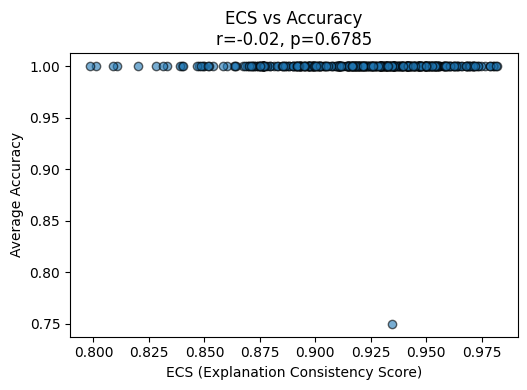

In [985]:
import pandas as pd
from scipy.stats import pearsonr, spearmanr
import matplotlib.pyplot as plt

# === 1. Load dataset ===
file_path = "gsm8k/gsm8k_gemini_metrics_merged.csv"
df = pd.read_csv(file_path)

# Drop rows with missing values
df = df.dropna(subset=['ECS', 'average_accuracy'])
print(f"✅ Loaded {len(df)} valid rows for correlation analysis")

# === 2. Compute correlations ===
pearson_acc, p_acc = pearsonr(df['ECS'], df['average_accuracy'])
spearman_acc, sp_p_acc = spearmanr(df['ECS'], df['average_accuracy'])

# === 3. Print correlation results ===
print("\n📊 Faithfulness Correlation Analysis (Gemini)")
print("------------------------------------------------")
print(f"🔹 ECS ↔ Average Accuracy:")
print(f"   Pearson correlation:  {pearson_acc:.3f} (p={p_acc:.4f})")
print(f"   Spearman correlation: {spearman_acc:.3f} (p={sp_p_acc:.4f})")



# === 4. Visualization (same style as LLaMA) ===
plt.figure(figsize=(10, 4))

# ECS vs Accuracy
plt.subplot(1, 2, 1)
plt.scatter(df['ECS'], df['average_accuracy'], alpha=0.6, edgecolor='black')
plt.xlabel("ECS (Explanation Consistency Score)")
plt.ylabel("Average Accuracy")
plt.title(f"ECS vs Accuracy\nr={pearson_acc:.2f}, p={p_acc:.4f}")


plt.tight_layout()
plt.show()


**COUNTERFACTUAL**

In [5]:
import pandas as pd
import re
import math

# --- PARAMETERS ---
INPUT_FILE = "gsm8k_500_rows_with_answers.csv"
BATCH_SIZE = 5
OUTPUT_FILE = "gsm8k_500_batches_of_5_with_prompt.csv"

# --- STEP 1: Load CSV ---
df = pd.read_csv(INPUT_FILE)

# --- STEP 2: Extract final short answer after '####' ---
def extract_final_answer(answer_text):
    if pd.isna(answer_text):
        return ""
    match = re.search(r"####\s*(.*)", str(answer_text))
    return match.group(1).strip() if match else str(answer_text).strip()

df["final_answer"] = df["answer"].apply(extract_final_answer)

# --- STEP 3: Define the counterfactual generation prompt ---
prompt_text = (
    "You are assisting with a research project on *Explanation Consistency and Sensitivity in Mathematical Reasoning*.\n\n"
    "### Task\n"
    "For each Question/Answer pair listed below:\n"
    "1. Create **three counterfactual versions** of the question by **minimally changing** key factual or logical details so the correct answer changes.\n"
    "2. Keep the question realistic, coherent, and solvable.\n"
    "3. Preserve the same type of reasoning (e.g., proportional, additive, rate-based, etc.).\n"
    "4. Provide the **new correct answer** for each counterfactual.\n\n"
    "### Output rules\n"
    "- Return **valid JSON only** — no extra text or commentary.\n"
    "- Follow this exact structure:\n\n"
    "```json\n"
    "[\n"
    "  {\n"
    "    \"original_question\": \"...\",\n"
    "    \"original_answer\": \"...\",\n"
    "    \"counterfactuals\": [\n"
    "      {\"question\": \"...\", \"correct_answer\": \"...\"},\n"
    "      {\"question\": \"...\", \"correct_answer\": \"...\"},\n"
    "      {\"question\": \"...\", \"correct_answer\": \"...\"}\n"
    "    ]\n"
    "  },\n"
    "  ...\n"
    "]\n"
    "```\n\n"
    "Below are 5 original Question/Answer pairs:\n\n"
)

# --- STEP 4: Split into batches of 5 ---
num_batches = math.ceil(len(df) / BATCH_SIZE)
print(f"✅ Preparing {num_batches} batches of {BATCH_SIZE} questions each")

batches = []
for i in range(num_batches):
    start = i * BATCH_SIZE
    end = min((i + 1) * BATCH_SIZE, len(df))
    batch = df.iloc[start:end]

    # Combine the prompt with questions + answers
    batch_text = prompt_text
    for j, row in enumerate(batch.itertuples(), start=1):
        q = str(row.question).strip().replace("\n", " ")
        a = str(row.final_answer).strip()
        batch_text += f"Question{j}: {q}\nAnswer{j}: {a}\n\n"

    batches.append(batch_text.strip())

# --- STEP 5: Create DataFrame ---
batch_df = pd.DataFrame({
    "batch_id": [f"batch_{i+1:03d}" for i in range(num_batches)],
    "batch_prompt_text": batches
})

# --- STEP 6: Save to CSV ---
batch_df.to_csv(OUTPUT_FILE, index=False)

print(f"\n🎉 Saved {num_batches} ready-to-paste batches (5 Q&A each) to '{OUTPUT_FILE}'")
print("📋 Example batch preview:\n")
print(batch_df.head(1)["batch_prompt_text"].values[0][:800])



✅ Preparing 100 batches of 5 questions each

🎉 Saved 100 ready-to-paste batches (5 Q&A each) to 'gsm8k_500_batches_of_5_with_prompt.csv'
📋 Example batch preview:

You are assisting with a research project on *Explanation Consistency and Sensitivity in Mathematical Reasoning*.

### Task
For each Question/Answer pair listed below:
1. Create **three counterfactual versions** of the question by **minimally changing** key factual or logical details so the correct answer changes.
2. Keep the question realistic, coherent, and solvable.
3. Preserve the same type of reasoning (e.g., proportional, additive, rate-based, etc.).
4. Provide the **new correct answer** for each counterfactual.

### Output rules
- Return **valid JSON only** — no extra text or commentary.
- Follow this exact structure:

```json
[
  {
    "original_question": "...",
    "original_answer": "...",
    "counterfactuals": [
      {"question": "...", "correct_answer": "..."},
      {"quest


**save counterfactuals in a csv**

In [117]:
import pandas as pd
import json
import os

# ======================================
# 1️⃣ Paste your ChatGPT JSON output here
# ======================================
chatgpt_output_json = '''

[
  {
    "original_question": "Police officer A patrols 36 streets in 4 hours. His colleague, officer B, patrols 55 streets in 5 hours. How many streets will both officers patrol in one hour?",
    "original_answer": "20",
    "counterfactuals": [
      {
        "question": "Police officer A patrols 40 streets in 4 hours. His colleague, officer B, patrols 55 streets in 5 hours. How many streets will both officers patrol in one hour?",
        "correct_answer": "21"
      },
      {
        "question": "Police officer A patrols 36 streets in 3 hours. His colleague, officer B, patrols 55 streets in 5 hours. How many streets will both officers patrol in one hour?",
        "correct_answer": "22.6"
      },
      {
        "question": "Police officer A patrols 36 streets in 4 hours. His colleague, officer B, patrols 60 streets in 5 hours. How many streets will both officers patrol in one hour?",
        "correct_answer": "21"
      }
    ]
  },
  {
    "original_question": "Kim takes 4 classes in school that last 2 hours each. She drops 1 class. How many hours of classes does she have now have per day?",
    "original_answer": "6",
    "counterfactuals": [
      {
        "question": "Kim takes 5 classes in school that last 2 hours each. She drops 1 class. How many hours of classes does she have now have per day?",
        "correct_answer": "8"
      },
      {
        "question": "Kim takes 4 classes in school that last 3 hours each. She drops 1 class. How many hours of classes does she have now have per day?",
        "correct_answer": "9"
      },
      {
        "question": "Kim takes 4 classes in school that last 2 hours each. She drops 2 classes. How many hours of classes does she have now have per day?",
        "correct_answer": "4"
      }
    ]
  },
  {
    "original_question": "Era had 5 burgers for her and her 4 friends. She sliced each burger into halves. The first and second friends got 1 and 2 slices, respectively. Then the third and fourth friends got 3 slices each. How many slices of burgers are left for Era?",
    "original_answer": "1",
    "counterfactuals": [
      {
        "question": "Era had 6 burgers for her and her 4 friends. She sliced each burger into halves. The first and second friends got 1 and 2 slices, respectively. Then the third and fourth friends got 3 slices each. How many slices of burgers are left for Era?",
        "correct_answer": "3"
      },
      {
        "question": "Era had 5 burgers for her and her 4 friends. She sliced each burger into thirds. The first and second friends got 1 and 2 slices, respectively. Then the third and fourth friends got 3 slices each. How many slices of burgers are left for Era?",
        "correct_answer": "2"
      },
      {
        "question": "Era had 5 burgers for her and her 4 friends. She sliced each burger into halves. The first and second friends got 2 and 2 slices, respectively. Then the third and fourth friends got 3 slices each. How many slices of burgers are left for Era?",
        "correct_answer": "0"
      }
    ]
  },
  {
    "original_question": "Because of the migration of salmon, the total number of salmon in river Trout has increased by ten times the number initially in the river. If there were 500 salmons initially, calculate the total number of fish in the river now.",
    "original_answer": "5500",
    "counterfactuals": [
      {
        "question": "Because of the migration of salmon, the total number of salmon in river Trout has increased by eight times the number initially in the river. If there were 500 salmons initially, calculate the total number of fish in the river now.",
        "correct_answer": "4500"
      },
      {
        "question": "Because of the migration of salmon, the total number of salmon in river Trout has increased by ten times the number initially in the river. If there were 400 salmons initially, calculate the total number of fish in the river now.",
        "correct_answer": "4400"
      },
      {
        "question": "Because of the migration of salmon, the total number of salmon in river Trout has increased by nine times the number initially in the river. If there were 600 salmons initially, calculate the total number of fish in the river now.",
        "correct_answer": "6000"
      }
    ]
  },
  {
    "original_question": "On a weekend road trip, the Jensen family drove 210 miles on highways, where their car gets 35 miles for each gallon of gas and 54 miles on city streets where their car gets 18 miles for each gallon. How many gallons of gas did they use?",
    "original_answer": "9",
    "counterfactuals": [
      {
        "question": "On a weekend road trip, the Jensen family drove 210 miles on highways, where their car gets 30 miles for each gallon of gas and 54 miles on city streets where their car gets 18 miles for each gallon. How many gallons of gas did they use?",
        "correct_answer": "10"
      },
      {
        "question": "On a weekend road trip, the Jensen family drove 180 miles on highways, where their car gets 35 miles for each gallon of gas and 54 miles on city streets where their car gets 18 miles for each gallon. How many gallons of gas did they use?",
        "correct_answer": "8.14"
      },
      {
        "question": "On a weekend road trip, the Jensen family drove 210 miles on highways, where their car gets 35 miles for each gallon of gas and 72 miles on city streets where their car gets 18 miles for each gallon. How many gallons of gas did they use?",
        "correct_answer": "10"
      }
    ]
  }
]




'''

# ======================================
# 2️⃣ Parse JSON
# ======================================
chatgpt_output = json.loads(chatgpt_output_json)

# ======================================
# 3️⃣ Flatten JSON → Wide DataFrame (1 row per original question)
# ======================================
rows = []
for item in chatgpt_output:
    row = {
        "original_question": item["original_question"],
        "original_answer": item["original_answer"]
    }
    # Add up to 3 counterfactuals as columns
    for i, cf in enumerate(item["counterfactuals"], start=1):
        row[f"counterfactual_{i}_question"] = cf["question"]
        row[f"counterfactual_{i}_answer"] = cf["correct_answer"]
    rows.append(row)

df = pd.DataFrame(rows)

# Add incremental ID
df.insert(0, "id", range(1, len(df) + 1))

# ======================================
# 4️⃣ Append or create the CSV file
# ======================================
file_path = "gsm8k_counterfactuals.csv"

if os.path.exists(file_path):
    existing_df = pd.read_csv(file_path)
    last_id = existing_df["id"].max()
    df["id"] = range(last_id + 1, last_id + 1 + len(df))
    combined_df = pd.concat([existing_df, df], ignore_index=True)
    combined_df.to_csv(file_path, index=False, encoding="utf-8")
    print(f"✅ Appended {len(df)} new rows to existing file '{file_path}'")
else:
    df.to_csv(file_path, index=False, encoding="utf-8")
    print(f"✅ Created new file '{file_path}' with {len(df)} rows")

# ======================================
# 5️⃣ Preview result
# ======================================
display(df.head(5))



✅ Appended 5 new rows to existing file 'gsm8k_counterfactuals.csv'


,id,original_question,original_answer,counterfactual_1_question,counterfactual_1_answer,counterfactual_2_question,counterfactual_2_answer,counterfactual_3_question,counterfactual_3_answer
0,491,Peggy fell off her bike and skinned her knees....,11,Peggy fell off her bike and skinned her knees....,12,Peggy fell off her bike and skinned her knees....,13,Peggy fell off her bike and skinned her knees....,10
1,492,Jangshe spent $610 on 7 pieces of clothing. On...,96,Jangshe spent $700 on 7 pieces of clothing. On...,111,Jangshe spent $610 on 8 pieces of clothing. On...,80,Jangshe spent $610 on 7 pieces of clothing. On...,93
2,493,Mike has to get an x-ray and an MRI. The x-ray...,200,Mike has to get an x-ray and an MRI. The x-ray...,240,Mike has to get an x-ray and an MRI. The x-ray...,150,Mike has to get an x-ray and an MRI. The x-ray...,300
3,494,TreQuan is throwing rocks in the river and he ...,7,TreQuan is throwing rocks in the river and he ...,10.5,TreQuan is throwing rocks in the river and he ...,11,TreQuan is throwing rocks in the river and he ...,8
4,495,Rob and Mark plan to meet at the national park...,9,Rob and Mark plan to meet at the national park...,5,Rob and Mark plan to meet at the national park...,10,Rob and Mark plan to meet at the national park...,8


**counterfactuals**

**GEMINI ACCURACY**

In [31]:
# =====================================================
# 📘 Gemini CoT: Counterfactual Evaluation (Extract Final Answer + Accuracy)
# =====================================================

!pip -q install pandas numpy tqdm

import pandas as pd
import numpy as np
import re
from decimal import Decimal, InvalidOperation
from tqdm import tqdm

# =====================================================
# STEP 1: Load data
# =====================================================

gold_df = pd.read_csv("gsm8k_counterfactuals.csv")
gemini_df = pd.read_csv("gsm8k_gemini_counterfactual_CoT.csv")

# --- TEMPORARY FILTER (only affects this run, not the files) ---

# Base IDs you already excluded
base_ids_to_remove = [10, 27, 36, 212, 303, 315, 320, 373, 390, 489]

# Additional IDs detected with NaN or missing Gemini answers
nan_ids_to_remove = [
    7, 24, 30, 35, 47, 58, 61, 69, 81, 83, 109, 143, 150, 159, 171, 172, 176,
    178, 182, 186, 187, 194, 207, 209, 219, 223, 225, 227, 237, 249, 262, 263,
    267, 287, 288, 305, 308, 319, 360, 367, 370, 378, 428, 431, 442, 470, 482,
    484, 487, 488
]

# Combine and deduplicate
ids_to_remove = sorted(set(base_ids_to_remove + nan_ids_to_remove))

# Apply filter to both datasets (temporary, in-memory only)
gold_df = gold_df[~gold_df["id"].isin(ids_to_remove)].reset_index(drop=True)
gemini_df = gemini_df[~gemini_df["id"].isin(ids_to_remove)].reset_index(drop=True)

print(f"✅ Loaded gold dataset with {len(gold_df)} rows (after filtering excluded IDs)")
print(f"✅ Loaded Gemini CoT dataset with {len(gemini_df)} rows (after filtering excluded IDs)")
print(f"🧹 Temporarily excluded {len(ids_to_remove)} IDs: {ids_to_remove}")

# =====================================================
# STEP 2: Helper functions (unchanged)
# =====================================================

def extract_gsm8k_answer(text):
    if not isinstance(text, str):
        return None
    m = re.search(r"####\s*(.*)", text)
    return m.group(1).strip() if m else text.strip()

def extract_gemini_answer(text):
    if not isinstance(text, str):
        return None
    s = text.strip()
    patterns = [
        r"[Tt]he\s+final\s+answer\s+is\s+\\?\$?\\?boxed\{?([^\}\$]+)\}?",
        r"[Ff]inal\s+[Aa]nswer\s*[:=\-–—]?\s*\\?\$?\\?boxed\{?([^\}\$]+)\}?",
        r"[Tt]he\s+final\s+answer\s+is\s+([^\n\r]*)",
        r"[Ff]inal\s+[Aa]nswer\s*[:=\-–—]?\s*([^\n\r]*)",
    ]
    candidate = None
    for pat in patterns:
        m = re.search(pat, s)
        if m:
            candidate = m.group(1)
            break
    if candidate is None:
        m = re.search(r"\\boxed\{([^}]*)\}", s)
        if m:
            candidate = m.group(1)
    if candidate is None:
        return None
    candidate = candidate.strip()
    candidate = re.sub(r"\\text\{[^}]*\}", "", candidate)
    candidate = candidate.replace("\\(", "").replace("\\)", "")
    candidate = candidate.replace("$", "")
    candidate = candidate.replace("⁄", "/")
    candidate = candidate.replace(",", "")
    candidate = candidate.replace("≈", " ").replace("∼", " ").strip()
    frac = re.search(r"\\frac\{\s*([\-+]?\d+)\s*\}\{\s*([\-+]?\d+)\s*\}", candidate)
    if frac:
        return f"{frac.group(1)}/{frac.group(2)}"
    mixed = re.search(r"^\s*([\-+]?\d+)\s+(\d+)\s*/\s*(\d+)\s*$", candidate)
    if mixed:
        return f"{mixed.group(1)} {mixed.group(2)}/{mixed.group(3)}"
    simple_frac = re.search(r"^\s*\(?\s*([\-+]?\d+)\s*/\s*([\-+]?\d+)\s*\)?\s*$", candidate)
    if simple_frac:
        return f"{simple_frac.group(1)}/{simple_frac.group(2)}"
    cleaned = re.sub(r"[^0-9\.\-+/ ]", " ", candidate).strip()
    any_frac = re.search(r"([\-+]?\d+\s+\d+/\d+)|([\-+]?\d+/\d+)", cleaned)
    if any_frac:
        return any_frac.group(0).strip()
    num_match = re.search(r"[-+]?\d*\.?\d+", cleaned)
    if num_match:
        return num_match.group(0)
    return None

def to_decimal(s):
    if s is None:
        return None
    t = str(s).strip().lower()
    if t == "":
        return None
    t = t.replace(",", "").replace("⁄", "/").replace("≈", " ").replace("∼", " ").strip()
    m = re.fullmatch(r"\s*([\-+]?\d+)\s+(\d+)\s*/\s*(\d+)\s*", t)
    if m:
        whole, num, den = Decimal(m.group(1)), Decimal(m.group(2)), Decimal(m.group(3))
        if den == 0:
            return None
        frac = num / den
        return whole + frac if whole >= 0 else whole - frac
    m = re.fullmatch(r"\s*([\-+]?\d+)\s*/\s*([\-+]?\d+)\s*", t)
    if m:
        num, den = Decimal(m.group(1)), Decimal(m.group(2))
        if den == 0:
            return None
        return num / den
    m = re.fullmatch(r"\(\s*([\-+]?\d+)\s*/\s*([\-+]?\d+)\s*\)", t)
    if m:
        num, den = Decimal(m.group(1)), Decimal(m.group(2))
        if den == 0:
            return None
        return num / den
    t = re.sub(r"^[\s$€£]+", "", t)
    if re.fullmatch(r"[-+]?\d+\.", t):
        t = t[:-1]
    try:
        return Decimal(t)
    except InvalidOperation:
        return None

def format_decimal_clean(d: Decimal, precision: int = 2) -> str:
    d = d.quantize(Decimal("1." + "0" * precision))
    s = format(d, "f")
    if "." in s:
        s = s.rstrip("0").rstrip(".")
    return s

def normalize_for_report(ans, precision: int = 2):
    d = to_decimal(ans)
    if d is not None:
        return format_decimal_clean(d, precision)
    if ans is None:
        return None
    return str(ans).strip().rstrip(" .")

def answers_equal(a, b, precision: int = 2, tol: Decimal = Decimal("1e-9")) -> bool:
    da, db = to_decimal(a), to_decimal(b)
    if da is not None and db is not None:
        da_r = da.quantize(Decimal("1." + "0" * precision))
        db_r = db.quantize(Decimal("1." + "0" * precision))
        return (da_r - db_r).copy_abs() <= tol
    return str(a).strip().lower() == str(b).strip().lower()

# =====================================================
# STEP 3: Extract and Compare
# =====================================================

results = []
print("🔍 Extracting answers and comparing for each counterfactual question...")

for i in tqdm(range(len(gold_df))):
    row = {"id": gold_df.loc[i, "id"]}
    gold_answers = {
        "original": extract_gsm8k_answer(gold_df.loc[i, "original_answer"]),
        "counterfactual_1": extract_gsm8k_answer(gold_df.loc[i, "counterfactual_1_answer"]),
        "counterfactual_2": extract_gsm8k_answer(gold_df.loc[i, "counterfactual_2_answer"]),
        "counterfactual_3": extract_gsm8k_answer(gold_df.loc[i, "counterfactual_3_answer"]),
    }
    gemini_answers = {
        "original": extract_gemini_answer(gemini_df.loc[i, "cot_original_answer"]),
        "counterfactual_1": extract_gemini_answer(gemini_df.loc[i, "cot_counterfactual_1_answer"]),
        "counterfactual_2": extract_gemini_answer(gemini_df.loc[i, "cot_counterfactual_2_answer"]),
        "counterfactual_3": extract_gemini_answer(gemini_df.loc[i, "cot_counterfactual_3_answer"]),
    }
    for k in gold_answers.keys():
        gold_norm = normalize_for_report(gold_answers[k])
        gemini_norm = normalize_for_report(gemini_answers[k])
        row[f"gsm8k_{k}_answer"] = gold_norm
        row[f"gemini_{k}_answer"] = gemini_norm
        row[f"correct_{k}"] = int(answers_equal(gold_norm, gemini_norm))
    row["average_accuracy"] = np.mean([row[f"correct_{k}"] for k in gold_answers.keys()])
    results.append(row)

compare_df = pd.DataFrame(results)

# =====================================================
# STEP 4–6: Accuracy + Save Results
# =====================================================

def col_accuracy(col):
    return 100 * compare_df[f"correct_{col}"].mean()

accuracy = {k: col_accuracy(k) for k in ["original", "counterfactual_1", "counterfactual_2", "counterfactual_3"]}

print("\n✅ Accuracy Results (%):")
for k, v in accuracy.items():
    print(f"{k}: {v:.2f}%")

overall_acc = np.mean(list(accuracy.values()))
print(f"\n🌟 Overall Average Accuracy: {overall_acc:.2f}%")

drop_cols = [c for c in compare_df.columns if c.startswith("correct_")]
clean_df = compare_df.drop(columns=drop_cols)
clean_df.to_csv("gsm8k_gemini_counterfactual_accuracy.csv", index=False)




[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: pip install --upgrade pip
✅ Loaded gold dataset with 440 rows (after filtering excluded IDs)
✅ Loaded Gemini CoT dataset with 440 rows (after filtering excluded IDs)
🧹 Temporarily excluded 60 IDs: [7, 10, 24, 27, 30, 35, 36, 47, 58, 61, 69, 81, 83, 109, 143, 150, 159, 171, 172, 176, 178, 182, 186, 187, 194, 207, 209, 212, 219, 223, 225, 227, 237, 249, 262, 263, 267, 287, 288, 303, 305, 308, 315, 319, 320, 360, 367, 370, 373, 378, 390, 428, 431, 442, 470, 482, 484, 487, 488, 489]
🔍 Extracting answers and comparing for each counterfactual question...


100%|███████████████████████████████████████| 440/440 [00:00<00:00, 7785.81it/s]


✅ Accuracy Results (%):
original: 99.32%
counterfactual_1: 99.09%
counterfactual_2: 99.55%
counterfactual_3: 99.77%

🌟 Overall Average Accuracy: 99.43%


In [26]:
# =====================================================
# 📊 Identify Disagreements: GSM8K vs Gemini Answers (cleaned + fixed)
# =====================================================

import pandas as pd
import numpy as np

# Load the clean comparison file (output from previous step)
input_file = "gsm8k_gemini_counterfactual_accuracy.csv"
output_file = "gsm8k_gemini_counterfactual_disagreements.csv"

df = pd.read_csv(input_file)
print(f"✅ Loaded comparison data with {len(df)} rows")

# Ensure id is treated as integer if possible
if df["id"].dtype == bool:
    df["id"] = df["id"].astype(int)
else:
    df["id"] = pd.to_numeric(df["id"], errors="ignore")

# Versions to compare
versions = ["original", "counterfactual_1", "counterfactual_2", "counterfactual_3"]

# Collect disagreements
disagreements = []

for _, row in df.iterrows():
    for v in versions:
        gsm8k_ans = str(row.get(f"gsm8k_{v}_answer", "")).strip()
        gemini_ans = str(row.get(f"gemini_{v}_answer", "")).strip()

        # Skip NaN or empty Gemini answers
        if gemini_ans.lower() in ["nan", "none", ""]:
            continue

        # Only include rows where answers differ
        if gsm8k_ans and gsm8k_ans != gemini_ans:
            disagreements.append({
                "id": int(row["id"]) if not pd.isna(row["id"]) else None,
                "version": v,
                "gsm8k_answer": gsm8k_ans,
                "gemini_answer": gemini_ans
            })

# Convert to DataFrame
diff_df = pd.DataFrame(disagreements)

# Save only disagreements
diff_df.to_csv(output_file, index=False)
print(f"💾 Saved {len(diff_df)} disagreement cases to {output_file}")

# Show a few examples
print("\n🔍 Sample disagreements:")
display(diff_df.head(10))



✅ Loaded comparison data with 490 rows
💾 Saved 10 disagreement cases to gsm8k_gemini_counterfactual_disagreements.csv

🔍 Sample disagreements:


/var/folders/vk/18ngtwrs58n0x_sklvrh_58h0000gn/T/ipykernel_25620/4178224842.py:19: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df["id"] = pd.to_numeric(df["id"], errors="ignore")


,id,version,gsm8k_answer,gemini_answer
0,16,counterfactual_1,220.0,100.0
1,133,counterfactual_1,64.0,0.0
2,190,counterfactual_1,60.0,75.0
3,333,original,72.0,74.0
4,334,original,28.0,35.0
5,334,counterfactual_2,32.0,40.0
6,409,original,5.0,9.0
7,409,counterfactual_1,8.0,12.0
8,409,counterfactual_2,7.0,9.0
9,409,counterfactual_3,2.0,6.0


**GEMINI ECS**

In [1]:
# =====================================================
# 📊 Compute Explainability Consistency Score (ECS)
# for Gemini Counterfactual CoT Rationales
# (Excluding specified IDs)
# =====================================================

!pip -q install sentence-transformers tqdm pandas numpy scikit-learn

import pandas as pd
import numpy as np
from itertools import combinations
from tqdm import tqdm
from sentence_transformers import SentenceTransformer

# =====================================================
# STEP 1: Load Gemini CoT results
# =====================================================
input_file = "gsm8k_gemini_counterfactual_CoT.csv"
output_file = "gsm8k_gemini_counterfactual_ECS_scores.csv"

gemini_df = pd.read_csv(input_file)
print(f"✅ Loaded {len(gemini_df)} examples from {input_file}")

# =====================================================
# STEP 2: Exclude specific IDs (temporary, in-memory only)
# =====================================================

# Base IDs you already excluded
base_ids_to_remove = [10, 27, 36, 212, 303, 315, 320, 373, 390, 489]

# Additional IDs detected with NaN or missing Gemini answers
nan_ids_to_remove = [
    7, 24, 30, 35, 47, 58, 61, 69, 81, 83, 109, 143, 150, 159, 171, 172, 176,
    178, 182, 186, 187, 194, 207, 209, 219, 223, 225, 227, 237, 249, 262, 263,
    267, 287, 288, 305, 308, 319, 360, 367, 370, 378, 428, 431, 442, 470, 482,
    484, 487, 488
]

# Combine and deduplicate
ids_to_remove = sorted(set(base_ids_to_remove + nan_ids_to_remove))

# Filter the DataFrame (does not modify the file)
gemini_df = gemini_df[~gemini_df["id"].isin(ids_to_remove)].reset_index(drop=True)

print(f"🧹 Excluded {len(ids_to_remove)} IDs from ECS calculation.")
print(f"✅ Remaining rows after filtering: {len(gemini_df)}")

# =====================================================
# STEP 3: Initialize embedding model
# =====================================================
print("🚀 Loading embedding model: all-MiniLM-L6-v2 ...")
model = SentenceTransformer("all-MiniLM-L6-v2")

# =====================================================
# STEP 4: Define ECS computation function
# =====================================================
def compute_ecs_semantic(rationales):
    """
    Compute the Explanation Consistency Score (ECS):
    mean cosine similarity between all pairs of explanations (semantic meaning).

    rationales: list of strings (rationales from perturbed questions)
    returns: mean pairwise cosine similarity (float)
    """
    texts = [t for t in rationales if isinstance(t, str) and t.strip()]
    if len(texts) < 2:
        return np.nan

    pairs = list(combinations(texts, 2))
    sim_scores = []

    for a, b in pairs:
        emb = model.encode([a, b], normalize_embeddings=True)
        sim = float(np.dot(emb[0], emb[1]))  # cosine similarity
        sim_scores.append(sim)

    return np.mean(sim_scores)

# =====================================================
# STEP 5: Compute ECS for each example
# =====================================================
ecs_scores = []

print("🧮 Computing ECS (semantic consistency) for each example...")
for _, row in tqdm(gemini_df.iterrows(), total=len(gemini_df)):
    ecs = compute_ecs_semantic([
        row.get("cot_original_answer"),
        row.get("cot_counterfactual_1_answer"),
        row.get("cot_counterfactual_2_answer"),
        row.get("cot_counterfactual_3_answer"),
    ])
    ecs_scores.append(ecs)

gemini_df["ECS"] = ecs_scores

# =====================================================
# STEP 6: Compute overall ECS mean
# =====================================================
overall_ecs = np.nanmean(gemini_df["ECS"])
print(f"\n🔍 Average Explanation Consistency Score (ECS): {overall_ecs:.3f}")

# =====================================================
# STEP 7: Save results
# =====================================================
gemini_df.to_csv(output_file, index=False)
print(f"💾 Saved ECS-annotated results to '{output_file}'")



[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: pip install --upgrade pip
✅ Loaded 500 examples from gsm8k_gemini_counterfactual_CoT.csv
🧹 Excluded 60 IDs from ECS calculation.
✅ Remaining rows after filtering: 440
🚀 Loading embedding model: all-MiniLM-L6-v2 ...
🧮 Computing ECS (semantic consistency) for each example...


100%|█████████████████████████████████████████| 440/440 [01:07<00:00,  6.48it/s]


🔍 Average Explanation Consistency Score (ECS): 0.929
💾 Saved ECS-annotated results to 'gsm8k_gemini_counterfactual_ECS_scores.csv'


**GEMINI ECS-ACCURACY CORRELATION**

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)



[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: pip install --upgrade pip
✅ Loaded ECS file with 440 rows
✅ Loaded Accuracy file with 440 rows
✅ Loaded 440 valid rows for correlation analysis

📊 Correlation Analysis: ECS ↔ Average Accuracy
------------------------------------------------
🔹 Pearson correlation:  -0.013 (p=0.7854)
🔹 Spearman correlation: 0.005 (p=0.9237)


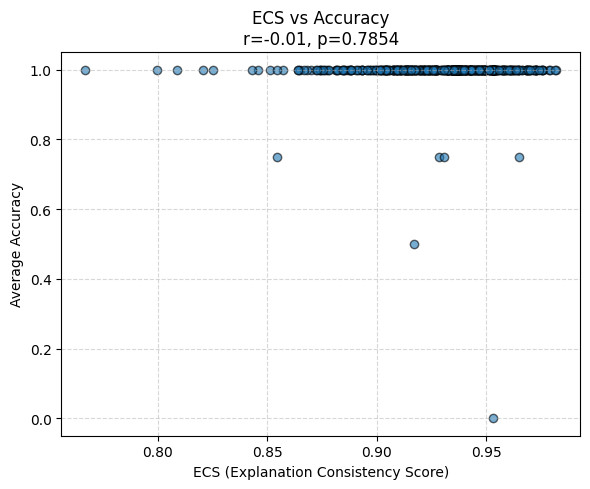

In [3]:
# =====================================================
# 📈 Correlation Analysis: ECS vs Accuracy
# =====================================================

!pip -q install pandas numpy scipy matplotlib

import pandas as pd
import numpy as np
from scipy.stats import pearsonr, spearmanr
import matplotlib.pyplot as plt

# =====================================================
# STEP 1: Load data
# =====================================================
ecs_file = "gsm8k_gemini_counterfactual_ECS_scores.csv"
acc_file = "gsm8k_gemini_counterfactual_accuracy.csv"

ecs_df = pd.read_csv(ecs_file)
acc_df = pd.read_csv(acc_file)

print(f"✅ Loaded ECS file with {len(ecs_df)} rows")
print(f"✅ Loaded Accuracy file with {len(acc_df)} rows")

# =====================================================
# STEP 2: Merge datasets on 'id'
# =====================================================
df = pd.merge(acc_df, ecs_df[['id', 'ECS']], on='id', how='inner')

# Drop rows with missing data in relevant columns
df = df.dropna(subset=['ECS', 'average_accuracy'])
print(f"✅ Loaded {len(df)} valid rows for correlation analysis")

# =====================================================
# STEP 3: Compute correlations
# =====================================================
pearson_acc, p_acc = pearsonr(df['ECS'], df['average_accuracy'])
spearman_acc, sp_p_acc = spearmanr(df['ECS'], df['average_accuracy'])

# =====================================================
# STEP 4: Print correlation results
# =====================================================
print("\n📊 Correlation Analysis: ECS ↔ Average Accuracy")
print("------------------------------------------------")
print(f"🔹 Pearson correlation:  {pearson_acc:.3f} (p={p_acc:.4f})")
print(f"🔹 Spearman correlation: {spearman_acc:.3f} (p={sp_p_acc:.4f})")

# =====================================================
# STEP 5: Visualization
# =====================================================
plt.figure(figsize=(6, 5))
plt.scatter(df['ECS'], df['average_accuracy'], alpha=0.6, edgecolor='black')
plt.xlabel("ECS (Explanation Consistency Score)")
plt.ylabel("Average Accuracy")
plt.title(f"ECS vs Accuracy\nr={pearson_acc:.2f}, p={p_acc:.4f}")
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()



**Mistral Accuracy**

In [46]:
# =====================================================
# 🧠 Mistral 7B: Extract Final Answers (multi-number) & Compute Accuracy
# =====================================================

import pandas as pd
import numpy as np
import re
from tqdm import tqdm

# =====================================================
# STEP 1: Load files
# =====================================================
mistral_file = "gsm8k_mistral7B_counterfactual_CoT.csv"
gold_file = "gsm8k_counterfactuals.csv"
output_file = "gsm8k_mistral7B_counterfactual_accuracy.csv"

mistral_df = pd.read_csv(mistral_file)
gold_df = pd.read_csv(gold_file)

print(f"✅ Loaded Mistral CoT file with {len(mistral_df)} rows")
print(f"✅ Loaded GSM8K gold file with {len(gold_df)} rows")

# =====================================================
# TEMP FILTER: Exclude bad IDs (non-numeric or NaN answers)
# =====================================================
bad_ids = [
    7,61,69,143,182,207,288,367,370,  #weirdd leftover plain answers on gemini , 367 super weid
    58,#weird for mistral but also wrong answer
    27,36,212,303,315,373,390,#weird ones of gemini 
    362,322, #weird mistral math execution
    9,12,29,35,65,80,102,122,130,135,304,337,361,368,402,420,451,465,#round calculations are wrong
    10, 14, 21, 37, 42, 43, 53, 54, 57, 100, 104, 106, 107, 109, 111, 112, 117, 118, 119,
    123, 133, 141, 147, 161, 162, 164, 171, 176, 179, 190, 209, 211, 214, 219, 220, 227,
    231, 232, 235, 237, 238, 245, 246, 250, 259, 261, 263, 266, 268, 284, 287, 291, 296,
    298, 312, 314, 319, 320, 324, 338, 345, 360, 363, 366, 377, 378, 381, 391, 397, 428,
    438, 440, 442, 454, 459, 461, 469, 481, 482, 489, 496, 498
]





mistral_df = mistral_df[~mistral_df["id"].isin(bad_ids)].reset_index(drop=True)
gold_df = gold_df[~gold_df["id"].isin(bad_ids)].reset_index(drop=True)

print(f"🧹 Temporarily excluded {len(bad_ids)} rows with invalid or missing answers")
print(f"📉 New Mistral dataset length: {len(mistral_df)}")

# =====================================================
# STEP 2: Extraction and comparison helpers
# =====================================================

def extract_final_answer(text):
    """
    Extract ALL numeric values after 'Final Answer:' (space-separated).
    e.g. 'Final Answer: 5, 90, and 450' -> '5 90 450'
    """
    if not isinstance(text, str):
        return ""
    m = re.search(r'final\s*answer\s*:\s*(.*)', text, flags=re.IGNORECASE | re.DOTALL)
    if not m:
        return ""
    after = m.group(1).strip().splitlines()[0].strip().strip('“”"\'')
    nums = re.findall(r'[-+]?\$?\s*([\d,]+(?:\.\d+)?(?:e[+-]?\d+)?)', after, flags=re.IGNORECASE)
    if nums:
        cleaned = [n.replace('$', '').replace(',', '').strip() for n in nums]
        return " ".join(cleaned)
    return ""

def extract_gsm8k_answer(text):
    """Extract gold answer after '####'."""
    if not isinstance(text, str):
        return None
    m = re.search(r"####\s*(.*)", text)
    return m.group(1).strip() if m else text.strip()

def is_correct(preds, truth):
    """
    Return 1 if ANY numeric value in preds matches truth (after cleaning).
    Example: '30000 30' vs '30' -> correct (30 matches)
    """
    try:
        if not isinstance(preds, str) or not isinstance(truth, str):
            return 0
        preds_list = [p.strip() for p in preds.split() if p.strip()]
        for p in preds_list:
            try:
                if float(p) == float(truth):
                    return 1
            except:
                continue
        return 0
    except:
        return 0

# =====================================================
# STEP 3: Extract Mistral answers
# =====================================================

cols = [
    "cot_original_answer",
    "cot_counterfactual_1_answer",
    "cot_counterfactual_2_answer",
    "cot_counterfactual_3_answer"
]

for c in cols:
    mistral_df[c + "_extracted"] = mistral_df[c].apply(extract_final_answer)

print("✅ Extracted all numeric final answers from Mistral outputs")

# =====================================================
# STEP 4: Compare with gold answers
# =====================================================

results = []
print("🔍 Comparing extracted answers with GSM8K gold labels...")

for i in tqdm(range(len(mistral_df))):
    row = {"id": mistral_df.loc[i, "id"]}
    
    gold_answers = {
        "original": extract_gsm8k_answer(gold_df.loc[i, "original_answer"]),
        "counterfactual_1": extract_gsm8k_answer(gold_df.loc[i, "counterfactual_1_answer"]),
        "counterfactual_2": extract_gsm8k_answer(gold_df.loc[i, "counterfactual_2_answer"]),
        "counterfactual_3": extract_gsm8k_answer(gold_df.loc[i, "counterfactual_3_answer"]),
    }

    mistral_answers = {
        "original": mistral_df.loc[i, "cot_original_answer_extracted"],
        "counterfactual_1": mistral_df.loc[i, "cot_counterfactual_1_answer_extracted"],
        "counterfactual_2": mistral_df.loc[i, "cot_counterfactual_2_answer_extracted"],
        "counterfactual_3": mistral_df.loc[i, "cot_counterfactual_3_answer_extracted"],
    }

    # Compute per-column correctness
    for k in gold_answers.keys():
        correct = is_correct(mistral_answers[k], gold_answers[k])
        row[f"mistral_{k}_answer"] = mistral_answers[k]
        row[f"gsm8k_{k}_answer"] = gold_answers[k]
        row[f"correct_{k}"] = correct

    # Compute per-row average accuracy (across 4)
    row["average_accuracy"] = np.mean([row[f"correct_{k}"] for k in gold_answers.keys()])
    results.append(row)

compare_df = pd.DataFrame(results)

# =====================================================
# STEP 5: Compute overall statistics
# =====================================================

def col_accuracy(col):
    return 100 * compare_df[f"correct_{col}"].mean()

accuracy = {
    k: col_accuracy(k)
    for k in ["original", "counterfactual_1", "counterfactual_2", "counterfactual_3"]
}

print("\n✅ Accuracy Results (%):")
for k, v in accuracy.items():
    print(f"{k}: {v:.2f}%")

overall_acc = np.mean(list(accuracy.values()))
print(f"\n🌟 Overall Average Accuracy: {overall_acc:.2f}%")

# =====================================================
# STEP 6: Save results
# =====================================================

drop_cols = [c for c in compare_df.columns if c.startswith("correct_")]
clean_df = compare_df.drop(columns=drop_cols)
clean_df.to_csv(output_file, index=False)

print(f"\n💾 Saved Mistral 7B accuracy results to '{output_file}'")



✅ Loaded Mistral CoT file with 500 rows
✅ Loaded GSM8K gold file with 500 rows
🧹 Temporarily excluded 119 rows with invalid or missing answers
📉 New Mistral dataset length: 381
✅ Extracted all numeric final answers from Mistral outputs
🔍 Comparing extracted answers with GSM8K gold labels...


100%|██████████████████████████████████████| 381/381 [00:00<00:00, 21139.64it/s]


✅ Accuracy Results (%):
original: 49.34%
counterfactual_1: 47.77%
counterfactual_2: 46.98%
counterfactual_3: 50.92%

🌟 Overall Average Accuracy: 48.75%

💾 Saved Mistral 7B accuracy results to 'gsm8k_mistral7B_counterfactual_accuracy.csv'


**Mistral ECS scores**

In [ ]:
# =====================================================
# 📊 Compute Explainability Consistency Score (ECS)
# for Mistral 7B Counterfactual CoT Rationales
# (Excluding specified IDs)
# =====================================================

!pip -q install sentence-transformers tqdm pandas numpy scikit-learn

import pandas as pd
import numpy as np
from itertools import combinations
from tqdm import tqdm
from sentence_transformers import SentenceTransformer

# =====================================================
# STEP 1: Load Mistral CoT results
# =====================================================
input_file = "gsm8k_mistral7B_counterfactual_CoT.csv"
output_file = "gsm8k_mistral7B_counterfactual_ECS_scores.csv"

mistral_df = pd.read_csv(input_file)
print(f"✅ Loaded {len(mistral_df)} examples from {input_file}")

# =====================================================
# STEP 2: Exclude specific IDs (temporary, in-memory only)
# =====================================================

# IDs you excluded earlier (Gemini + Mistral invalids)
bad_ids = [
    7, 61, 69, 143, 182, 207, 288, 367, 370,  # weird leftover plain answers on gemini
    58,  # weird for mistral but also wrong answer
    27, 36, 212, 303, 315, 373, 390,  # weird gemini ones
    10, 14, 21, 37, 42, 43, 53, 54, 57, 100, 104, 106, 107, 109, 111, 112, 117, 118, 119,
    123, 133, 141, 147, 161, 162, 164, 171, 176, 179, 190, 209, 211, 214, 219, 220, 227,
    231, 232, 235, 237, 238, 245, 246, 250, 259, 261, 263, 266, 268, 284, 287, 291, 296,
    298, 312, 314, 319, 320, 324, 338, 345, 360, 363, 366, 377, 378, 381, 391, 397, 428,
    438, 440, 442, 454, 459, 461, 469, 481, 482, 489, 496, 498
]




# Filter out invalid rows
mistral_df = mistral_df[~mistral_df["id"].isin(bad_ids)].reset_index(drop=True)

print(f"🧹 Excluded {len(bad_ids)} IDs from ECS calculation.")
print(f"✅ Remaining rows after filtering: {len(mistral_df)}")

# =====================================================
# STEP 3: Initialize embedding model
# =====================================================
print("🚀 Loading embedding model: all-MiniLM-L6-v2 ...")
model = SentenceTransformer("all-MiniLM-L6-v2")

# =====================================================
# STEP 4: Define ECS computation function
# =====================================================
def compute_ecs_semantic(rationales):
    """
    Compute the Explanation Consistency Score (ECS):
    mean cosine similarity between all pairs of explanations (semantic meaning).

    rationales: list of strings (rationales from perturbed questions)
    returns: mean pairwise cosine similarity (float)
    """
    texts = [t for t in rationales if isinstance(t, str) and t.strip()]
    if len(texts) < 2:
        return np.nan

    pairs = list(combinations(texts, 2))
    sim_scores = []

    for a, b in pairs:
        emb = model.encode([a, b], normalize_embeddings=True)
        sim = float(np.dot(emb[0], emb[1]))  # cosine similarity
        sim_scores.append(sim)

    return np.mean(sim_scores)

# =====================================================
# STEP 5: Compute ECS for each example
# =====================================================
ecs_scores = []

print("🧮 Computing ECS (semantic consistency) for each example...")
for _, row in tqdm(mistral_df.iterrows(), total=len(mistral_df)):
    ecs = compute_ecs_semantic([
        row.get("cot_original_answer"),
        row.get("cot_counterfactual_1_answer"),
        row.get("cot_counterfactual_2_answer"),
        row.get("cot_counterfactual_3_answer"),
    ])
    ecs_scores.append(ecs)

mistral_df["ECS"] = ecs_scores

# =====================================================
# STEP 6: Compute overall ECS mean
# =====================================================
overall_ecs = np.nanmean(mistral_df["ECS"])
print(f"\n🔍 Average Explanation Consistency Score (ECS): {overall_ecs:.3f}")

# =====================================================
# STEP 7: Save results
# =====================================================
mistral_df.to_csv(output_file, index=False)
print(f"💾 Saved ECS-annotated results to '{output_file}'")


**Mistral ECS-Accuracy correlation**

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)



[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: pip install --upgrade pip
✅ Loaded ECS file with 401 rows
✅ Loaded Accuracy file with 381 rows
✅ Loaded 381 valid rows for correlation analysis

📊 Correlation Analysis (Mistral 7B): ECS ↔ Average Accuracy
------------------------------------------------------------
🔹 Pearson correlation:  0.274 (p=0.0000)
🔹 Spearman correlation: 0.261 (p=0.0000)


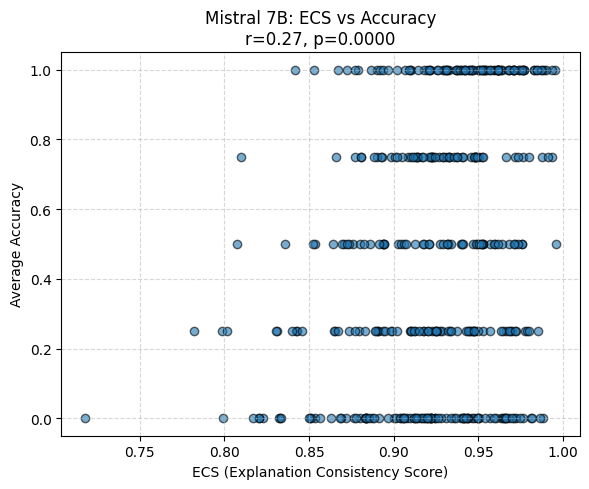

In [48]:
# =====================================================
# 📈 Correlation Analysis: ECS vs Accuracy (Mistral 7B)
# =====================================================

!pip -q install pandas numpy scipy matplotlib

import pandas as pd
import numpy as np
from scipy.stats import pearsonr, spearmanr
import matplotlib.pyplot as plt

# =====================================================
# STEP 1: Load data
# =====================================================
ecs_file = "gsm8k_mistral7B_counterfactual_ECS_scores.csv"
acc_file = "gsm8k_mistral7B_counterfactual_accuracy.csv"

ecs_df = pd.read_csv(ecs_file)
acc_df = pd.read_csv(acc_file)

print(f"✅ Loaded ECS file with {len(ecs_df)} rows")
print(f"✅ Loaded Accuracy file with {len(acc_df)} rows")

# =====================================================
# STEP 2: Merge datasets on 'id'
# =====================================================
df = pd.merge(acc_df, ecs_df[['id', 'ECS']], on='id', how='inner')

# Drop rows with missing data
df = df.dropna(subset=['ECS', 'average_accuracy'])
print(f"✅ Loaded {len(df)} valid rows for correlation analysis")

# =====================================================
# STEP 3: Compute correlations
# =====================================================
pearson_acc, p_acc = pearsonr(df['ECS'], df['average_accuracy'])
spearman_acc, sp_p_acc = spearmanr(df['ECS'], df['average_accuracy'])

# =====================================================
# STEP 4: Print correlation results
# =====================================================
print("\n📊 Correlation Analysis (Mistral 7B): ECS ↔ Average Accuracy")
print("------------------------------------------------------------")
print(f"🔹 Pearson correlation:  {pearson_acc:.3f} (p={p_acc:.4f})")
print(f"🔹 Spearman correlation: {spearman_acc:.3f} (p={sp_p_acc:.4f})")

# =====================================================
# STEP 5: Visualization
# =====================================================
plt.figure(figsize=(6, 5))
plt.scatter(df['ECS'], df['average_accuracy'], alpha=0.6, edgecolor='black')
plt.xlabel("ECS (Explanation Consistency Score)")
plt.ylabel("Average Accuracy")
plt.title(f"Mistral 7B: ECS vs Accuracy\nr={pearson_acc:.2f}, p={p_acc:.4f}")
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


**LLAMA**

**Llama Accuracy**

In [14]:
# =====================================================
# 🧠 LLaMA 3: Extract Final Answers & Compute Accuracy (Filtered)
# =====================================================

import pandas as pd
import numpy as np
import re
import math
from tqdm import tqdm

# =====================================================
# STEP 1: Load input files
# =====================================================
llama_file = "gsm8k_llama3_counterfactual_COT.csv"
gold_file = "gsm8k_counterfactuals.csv"
output_file = "gsm8k_llama3_counterfactual_accuracy.csv"

llama_df = pd.read_csv(llama_file)
gold_df = pd.read_csv(gold_file)

print(f"✅ Loaded LLaMA3 CoT file with {len(llama_df)} rows")
print(f"✅ Loaded GSM8K gold file with {len(gold_df)} rows")

# =====================================================
# TEMP FILTER: Exclude bad IDs (only in-memory)
# =====================================================


bad_ids = [
    # Weird leftover plain answers on Gemini
    7, 61, 69, 143, 182, 207, 288, 367, 370,

    # Weird Mistral and Gemini edge cases
    58, 27, 36, 212, 303, 315, 373, 390,
    
    # 🧠 Newly added LLaMA 3 invalid / NaN answers
    83, 98, 103, 111, 120, 181, 209, 219,
    239, 248, 319, 395, 446, 495
]



print(f"🧹 Excluding {len(bad_ids)} total bad IDs across models.")

# Apply temporary filtering (does not modify CSVs)
llama_df = llama_df[~llama_df["id"].isin(bad_ids)].reset_index(drop=True)
gold_df = gold_df[~gold_df["id"].isin(bad_ids)].reset_index(drop=True)

print(f"📉 Remaining rows after filtering: {len(llama_df)}")

# =====================================================
# STEP 2: Helper functions
# =====================================================

def extract_llm_answer(text):
    """
    Extract the numeric final answer that follows the *exact* phrase 'Final Answer:'.
    - Only uses 'Final Answer:' (case-sensitive)
    - Skips placeholders like <number or expression>
    - Handles comma-formatted numbers like 6,000
    """
    if not isinstance(text, str):
        return None
    s = text.strip()

    pattern = re.compile(r"Final Answer\s*:\s*(.*)")
    matches = list(pattern.finditer(s))
    if not matches:
        return None

    after = matches[0].group(1).strip()

    placeholder_re = re.compile(r"^<\s*(number|num|expression|ans)\s*[^>]*>$", re.IGNORECASE)
    if placeholder_re.match(after) and len(matches) > 1:
        after = matches[1].group(1).strip()

    after_clean = re.sub(r"(?<=\d),(?=\d)", "", after)

    num_match = re.search(r"[-+]?\d*\.?\d+(?:/\d+)?", after_clean)
    if num_match:
        return num_match.group(0)

    # Try next line
    lines = s.splitlines()
    for i, line in enumerate(lines):
        if "Final Answer:" in line:
            for j in range(i + 1, len(lines)):
                next_line = lines[j].strip()
                if not next_line:
                    continue
                next_line = re.sub(r"(?<=\d),(?=\d)", "", next_line)
                num_match = re.search(r"[-+]?\d*\.?\d+(?:/\d+)?", next_line)
                if num_match:
                    return num_match.group(0)
                break
            break

    return None


def normalize_answer(ans):
    """Normalize numeric or text answers (handles commas, decimals, fractions)."""
    if ans is None:
        return None
    ans = ans.strip().lower().replace(",", "")
    match = re.search(r"[-+]?\d*\.?\d+(?:/\d+)?", ans)
    if match:
        return match.group(0)
    return ans


def answers_equal(a, b, tol=1e-6):
    """Compare answers numerically when possible, else by string."""
    if a is None or b is None:
        return False
    try:
        fa, fb = float(a), float(b)
        return math.isclose(fa, fb, rel_tol=tol, abs_tol=tol)
    except ValueError:
        return str(a).strip().lower() == str(b).strip().lower()


def extract_gsm8k_answer(text):
    """Extract gold answer after '####'."""
    if not isinstance(text, str):
        return None
    m = re.search(r"####\s*(.*)", text)
    return m.group(1).strip() if m else text.strip()


# =====================================================
# STEP 3–6: (Unchanged, same as before)
# =====================================================

cols = [
    "cot_original_answer",
    "cot_counterfactual_1_answer",
    "cot_counterfactual_2_answer",
    "cot_counterfactual_3_answer",
]

for c in cols:
    llama_df[c + "_extracted"] = llama_df[c].apply(extract_llm_answer)

print("✅ Extracted final answers from all LLaMA3 CoT columns")

# =====================================================
# STEP X: Manually verified near-miss corrections
# =====================================================
manual_near_misses = {
    (12, "counterfactual_2"), (12, "counterfactual_3"),
    (21, "counterfactual_3"), (35, "counterfactual_3"),
    (41, "counterfactual_3"), (43, "counterfactual_2"),
    (102, "counterfactual_3"), (109, "counterfactual_2"),
    (135, "counterfactual_1"), (135, "counterfactual_2"), (135, "counterfactual_3"),
    (142, "counterfactual_3"), (169, "counterfactual_3"),
    (179, "counterfactual_3"), (187, "counterfactual_2"),
    (241, "counterfactual_3"), (250, "counterfactual_1"), (250, "counterfactual_2"),
    (256, "counterfactual_2"), (256, "counterfactual_3"),
    (263, "counterfactual_1"), (279, "counterfactual_3"),
    (291, "counterfactual_2"), (320, "counterfactual_1"),
    (337, "counterfactual_3"), (355, "original"),
    (361, "counterfactual_3"), (369, "counterfactual_2"),
    (377, "counterfactual_3"), (388, "counterfactual_2"),
    (431, "counterfactual_3"), (438, "counterfactual_2"),
    (481, "counterfactual_3"), (483, "counterfactual_3"),
    (484, "counterfactual_3"), (488, "counterfactual_3")
}
print(f"🧩 Loaded {len(manual_near_misses)} manually verified near-miss corrections")

# =====================================================
# STEP 4: Compare extracted vs. gold answers
# =====================================================

results = []
print("🔍 Comparing extracted answers with GSM8K gold labels...")

for i in tqdm(range(len(llama_df))):
    row = {"id": llama_df.loc[i, "id"]}
    
    gold_answers = {
        "original": extract_gsm8k_answer(gold_df.loc[i, "original_answer"]),
        "counterfactual_1": extract_gsm8k_answer(gold_df.loc[i, "counterfactual_1_answer"]),
        "counterfactual_2": extract_gsm8k_answer(gold_df.loc[i, "counterfactual_2_answer"]),
        "counterfactual_3": extract_gsm8k_answer(gold_df.loc[i, "counterfactual_3_answer"]),
    }

    llama_answers = {
        "original": llama_df.loc[i, "cot_original_answer_extracted"],
        "counterfactual_1": llama_df.loc[i, "cot_counterfactual_1_answer_extracted"],
        "counterfactual_2": llama_df.loc[i, "cot_counterfactual_2_answer_extracted"],
        "counterfactual_3": llama_df.loc[i, "cot_counterfactual_3_answer_extracted"],
    }

    for k in gold_answers.keys():
        a, b = normalize_answer(llama_answers[k]), normalize_answer(gold_answers[k])
        correct = 0

        if a is not None and b is not None:
            try:
                fa, fb = float(a), float(b)
                diff = abs(fa - fb)
                # ✅ Exact numeric or textual match
                if math.isclose(fa, fb, rel_tol=1e-6, abs_tol=1e-6):
                    correct = 1
                # ✅ Near-miss accepted only if in manual list
                elif diff < 0.9 and (row["id"], k) in manual_near_misses:
                    correct = 1
                # ❌ Near-miss rejected (not in manual list)
                elif diff < 0.9 and (row["id"], k) not in manual_near_misses:
                    correct = 0
            except ValueError:
                # Non-numeric, fallback to string equality
                correct = int(str(a).strip().lower() == str(b).strip().lower())

        row[f"llama_{k}_answer"] = llama_answers[k]
        row[f"gsm8k_{k}_answer"] = gold_answers[k]
        row[f"correct_{k}"] = correct

    row["average_accuracy"] = np.mean([row[f"correct_{k}"] for k in gold_answers.keys()])
    results.append(row)

compare_df = pd.DataFrame(results)

def col_accuracy(col):
    return 100 * compare_df[f"correct_{col}"].mean()

accuracy = {k: col_accuracy(k) for k in ["original", "counterfactual_1", "counterfactual_2", "counterfactual_3"]}

print("\n✅ Accuracy Results (%):")
for k, v in accuracy.items():
    print(f"{k}: {v:.2f}%")

overall_acc = np.mean(list(accuracy.values()))
print(f"\n🌟 Overall Average Accuracy: {overall_acc:.2f}%")

drop_cols = [c for c in compare_df.columns if c.startswith("correct_")]
clean_df = compare_df.drop(columns=drop_cols)
clean_df.to_csv(output_file, index=False)

print(f"\n💾 Saved LLaMA 3 accuracy results to '{output_file}'")



✅ Loaded LLaMA3 CoT file with 500 rows
✅ Loaded GSM8K gold file with 500 rows
🧹 Excluding 31 total bad IDs across models.
📉 Remaining rows after filtering: 469
✅ Extracted final answers from all LLaMA3 CoT columns
🧩 Loaded 36 manually verified near-miss corrections
🔍 Comparing extracted answers with GSM8K gold labels...


100%|██████████████████████████████████████| 469/469 [00:00<00:00, 21341.70it/s]


✅ Accuracy Results (%):
original: 78.25%
counterfactual_1: 76.33%
counterfactual_2: 76.12%
counterfactual_3: 75.05%

🌟 Overall Average Accuracy: 76.44%

💾 Saved LLaMA 3 accuracy results to 'gsm8k_llama3_counterfactual_accuracy.csv'


**Llama ECS**

In [49]:
# =====================================================
# 📊 Compute Explainability Consistency Score (ECS)
# for LLaMA 3 Counterfactual CoT Rationales
# =====================================================

!pip -q install sentence-transformers tqdm pandas numpy scikit-learn

import pandas as pd
import numpy as np
from itertools import combinations
from tqdm import tqdm
from sentence_transformers import SentenceTransformer

# =====================================================
# STEP 1: Load LLaMA CoT results
# =====================================================
input_file = "gsm8k_llama3_counterfactual_COT.csv"
output_file = "gsm8k_llama3_counterfactual_ECS_scores.csv"

llama_df = pd.read_csv(input_file)
print(f"✅ Loaded {len(llama_df)} examples from {input_file}")

# =====================================================
# STEP 2: Exclude specific IDs (optional, temporary)
# =====================================================
bad_ids = [
    # Weird leftover plain answers on Gemini
    7, 61, 69, 143, 182, 207, 288, 367, 370,

    # Weird Mistral and Gemini edge cases
    58, 27, 36, 212, 303, 315, 373, 390,
    
    # 🧠 Newly added LLaMA 3 invalid / NaN answers
    83, 98, 103, 111, 120, 181, 209, 219,
    239, 248, 319, 395, 446, 495
]

llama_df = llama_df[~llama_df["id"].isin(bad_ids)].reset_index(drop=True)
print(f"🧹 Excluded {len(bad_ids)} IDs for ECS calculation")
print(f"✅ Remaining rows: {len(llama_df)}")

# =====================================================
# STEP 3: Load embedding model
# =====================================================
print("🚀 Loading embedding model: all-MiniLM-L6-v2 ...")
model = SentenceTransformer("all-MiniLM-L6-v2")

# =====================================================
# STEP 4: ECS computation function
# =====================================================
def compute_ecs_semantic(rationales):
    """
    Compute the Explanation Consistency Score (ECS):
    mean cosine similarity between all pairs of explanations (semantic meaning).

    rationales: list of strings (rationales from perturbed questions)
    returns: mean pairwise cosine similarity (float)
    """
    texts = [t for t in rationales if isinstance(t, str) and t.strip()]
    if len(texts) < 2:
        return np.nan

    pairs = list(combinations(texts, 2))
    sim_scores = []

    for a, b in pairs:
        emb = model.encode([a, b], normalize_embeddings=True)
        sim = float(np.dot(emb[0], emb[1]))  # cosine similarity
        sim_scores.append(sim)

    return np.mean(sim_scores)

# =====================================================
# STEP 5: Compute ECS for each example
# =====================================================
ecs_scores = []
print("🧮 Computing ECS (semantic consistency) for each example...")
for _, row in tqdm(llama_df.iterrows(), total=len(llama_df)):
    ecs = compute_ecs_semantic([
        row.get("cot_original_answer"),
        row.get("cot_counterfactual_1_answer"),
        row.get("cot_counterfactual_2_answer"),
        row.get("cot_counterfactual_3_answer"),
    ])
    ecs_scores.append(ecs)

llama_df["ECS"] = ecs_scores

# =====================================================
# STEP 6: Compute overall ECS mean
# =====================================================
overall_ecs = np.nanmean(llama_df["ECS"])
print(f"\n🔍 Average Explanation Consistency Score (ECS): {overall_ecs:.3f}")

# =====================================================
# STEP 7: Save ECS-annotated results
# =====================================================
llama_df.to_csv(output_file, index=False)
print(f"💾 Saved ECS-annotated results to '{output_file}'")


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)



[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: pip install --upgrade pip
✅ Loaded 500 examples from gsm8k_llama3_counterfactual_COT.csv
🧹 Excluded 31 IDs for ECS calculation
✅ Remaining rows: 469
🚀 Loading embedding model: all-MiniLM-L6-v2 ...
🧮 Computing ECS (semantic consistency) for each example...


100%|█████████████████████████████████████████| 469/469 [01:07<00:00,  6.95it/s]



🔍 Average Explanation Consistency Score (ECS): 0.928
💾 Saved ECS-annotated results to 'gsm8k_llama3_counterfactual_ECS_scores.csv'


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)



[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: pip install --upgrade pip
✅ Loaded ECS file with 469 rows
✅ Loaded Accuracy file with 469 rows
✅ 469 valid rows for correlation analysis after dropping missing values

📊 Correlation Analysis (LLaMA 3): ECS ↔ Average Accuracy
------------------------------------------------------------
🔹 Pearson correlation:  0.241 (p=0.0000)
🔹 Spearman correlation: 0.244 (p=0.0000)


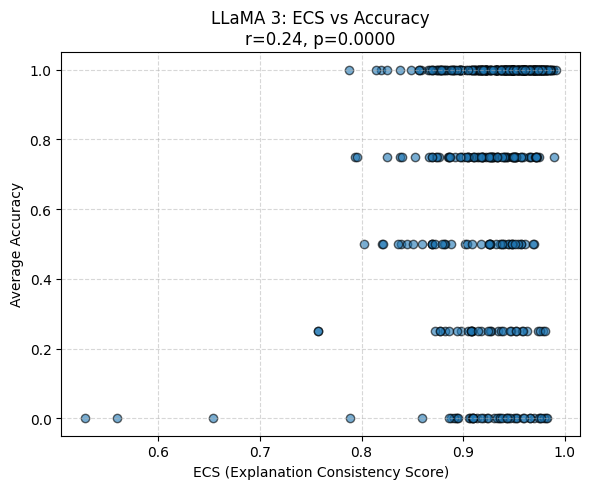

In [50]:
# =====================================================
# 📈 Correlation Analysis: ECS vs Accuracy (LLaMA 3)
# =====================================================

!pip -q install pandas numpy scipy matplotlib

import pandas as pd
import numpy as np
from scipy.stats import pearsonr, spearmanr
import matplotlib.pyplot as plt

# =====================================================
# STEP 1: Load ECS and Accuracy data
# =====================================================
ecs_file = "gsm8k_llama3_counterfactual_ECS_scores.csv"
acc_file = "gsm8k_llama3_counterfactual_accuracy.csv"

ecs_df = pd.read_csv(ecs_file)
acc_df = pd.read_csv(acc_file)

print(f"✅ Loaded ECS file with {len(ecs_df)} rows")
print(f"✅ Loaded Accuracy file with {len(acc_df)} rows")

# =====================================================
# STEP 2: Merge datasets on 'id'
# =====================================================
df = pd.merge(acc_df, ecs_df[['id', 'ECS']], on='id', how='inner')

# Drop rows with missing ECS or average_accuracy
df = df.dropna(subset=['ECS', 'average_accuracy'])
print(f"✅ {len(df)} valid rows for correlation analysis after dropping missing values")

# =====================================================
# STEP 3: Compute Pearson and Spearman correlations
# =====================================================
pearson_corr, pearson_p = pearsonr(df['ECS'], df['average_accuracy'])
spearman_corr, spearman_p = spearmanr(df['ECS'], df['average_accuracy'])

# =====================================================
# STEP 4: Print correlation results
# =====================================================
print("\n📊 Correlation Analysis (LLaMA 3): ECS ↔ Average Accuracy")
print("------------------------------------------------------------")
print(f"🔹 Pearson correlation:  {pearson_corr:.3f} (p={pearson_p:.4f})")
print(f"🔹 Spearman correlation: {spearman_corr:.3f} (p={spearman_p:.4f})")

# =====================================================
# STEP 5: Scatter plot
# =====================================================
plt.figure(figsize=(6, 5))
plt.scatter(df['ECS'], df['average_accuracy'], alpha=0.6, edgecolor='black')
plt.xlabel("ECS (Explanation Consistency Score)")
plt.ylabel("Average Accuracy")
plt.title(f"LLaMA 3: ECS vs Accuracy\nr={pearson_corr:.2f}, p={pearson_p:.4f}")
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


**Post Analysis llama gsm8k**

In [7]:

import pandas as pd
import numpy as np\
from itertools import combinations
from tqdm import tqdm
from sentence_transformers import SentenceTransformer

# =====================================================
# STEP 1: Load perturbed questions
# =====================================================
questions_df = pd.read_csv("gsm8k/gsm8k_perturbed_full.csv")
print(f"✅ Loaded {len(questions_df)} examples with perturbed questions")

# =====================================================
# STEP 2: Initialize embedding model
# =====================================================
print("🚀 Loading embedding model: all-MiniLM-L6-v2 ...")
model = SentenceTransformer('all-MiniLM-L6-v2')

# =====================================================
# STEP 3: Define ECS computation function (same as for rationales)
# =====================================================
def compute_ecs_semantic(texts):
    """
    Compute mean pairwise cosine similarity between a list of texts
    """
    texts = [t for t in texts if isinstance(t, str) and t.strip()]
    if len(texts) < 2:
        return np.nan

    pairs = list(combinations(texts, 2))
    sim_scores = []

    for a, b in pairs:
        emb = model.encode([a, b], normalize_embeddings=True)
        sim = float(np.dot(emb[0], emb[1]))  # cosine similarity
        sim_scores.append(sim)

    return np.mean(sim_scores)

# =====================================================
# STEP 4: Compute ECS for each example
# =====================================================
question_ecs_scores = []

print("🧠 Computing ECS for perturbed questions...")
for _, row in tqdm(questions_df.iterrows(), total=len(questions_df)):
    ecs = compute_ecs_semantic([
        row.get('original'),
        row.get('lexical'),
        row.get('syntactic'),
        row.get('contextual')
    ])
    question_ecs_scores.append(ecs)

questions_df['Question_ECS'] = question_ecs_scores

# =====================================================
# STEP 5: Compute overall mean ECS for questions
# =====================================================
overall_question_ecs = np.nanmean(questions_df['Question_ECS'])
print(f"\n🔍 Average Question ECS: {overall_question_ecs:.3f}")

# =====================================================
# STEP 6: Save results
# =====================================================
output_file = "gsm8k/gsm8k_questions_ECS_scores.csv"
questions_df.to_csv(output_file, index=False)
print(f"💾 Saved Question ECS results to {output_file}")


✅ Loaded 500 examples with perturbed questions
🚀 Loading embedding model: all-MiniLM-L6-v2 ...
🧠 Computing ECS for perturbed questions...


100%|█████████████████████████████████████████| 500/500 [00:40<00:00, 12.39it/s]


🔍 Average Question ECS: 0.904
💾 Saved Question ECS results to gsm8k/gsm8k_questions_ECS_scores.csv


🗑️ Removed 121 examples based on remove_ids.
✅ 379 examples remaining after filtering.


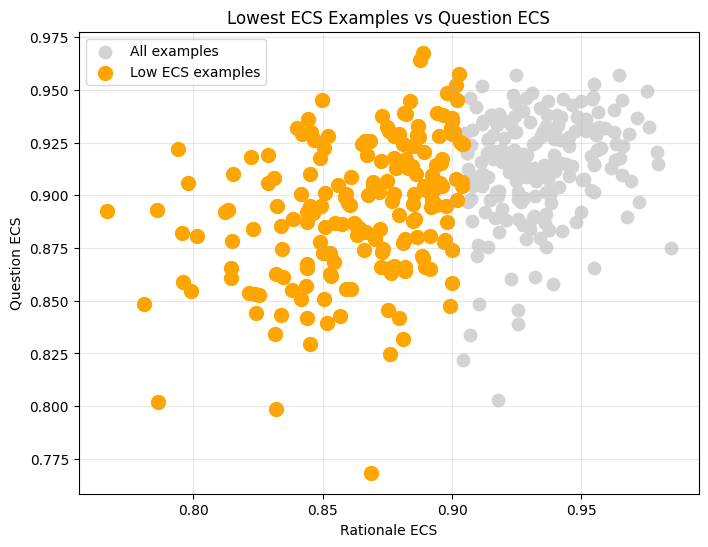

💾 Saved top 20 lowest ECS rationales ranked by ECS to gsm8k/low_ecs_rationales_llama3_gsm8k.csv


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# Load LLaMA3 rationale ECS
# -----------------------------
rationale_df = pd.read_csv("gsm8k/gsm8k_llama3_ECS_scores.csv")

# Load question ECS
question_df = pd.read_csv("gsm8k/gsm8k_questions_ECS_scores.csv")

# -----------------------------
# Merge ECS scores
# -----------------------------
merged_df = rationale_df.merge(
    question_df[['id','Question_ECS']],
    on='id',
    how='left'
)

# -----------------------------
# Exclude specific IDs
# -----------------------------
remove_ids = [
    2,7,27, 30, 33,36, 46, 47, 66, 82,85, 98, 103, 106, 110,111, 120,123, 127,128,135,143,145,146,149,
    150, 160, 168, 177, 190 ,196,204,207,209,212,214,215, 219, 221,224,229,230,238,263,265,277,282,285,286, 287, 289,291, 309,314,317,323,326,336,339,340,342,352,355,
    357, 362,367, 369,376 ,378,380, 384,385,398, 403,416,420,424,425,431, 434,439,442,468,471,487,489,492,
    36,51,75,63,69,92,93,100,112,115,116,125,130,170,183,219,225,237,257,271,
    303,311,315,332,347,348,350,357,367,369,371,372,374,445,454,460,462,488,489,499
]
# Count before removing
num_before = len(merged_df)

# Apply filtering
merged_df = merged_df[~merged_df['id'].isin(remove_ids)]

# Count after removing
num_after = len(merged_df)
num_removed = num_before - num_after

print(f"🗑️ Removed {num_removed} examples based on remove_ids.")
print(f"✅ {num_after} examples remaining after filtering.")


# -----------------------------
# Step 1: Select the lowest 20 ECS examples
# -----------------------------
low_20_ecs = merged_df.sort_values('ECS', ascending=True).head(190).copy()##CHECK HERE -------------------------------------------------------------

# -----------------------------
# Step 2: Compute ECS difference (Rationale ECS - Question ECS) for reference
# -----------------------------
low_20_ecs['ECS_diff'] = low_20_ecs['ECS'] - low_20_ecs['Question_ECS']

# -----------------------------
# Step 3: Rank these 20 by ECS (lowest first)
# -----------------------------
low_20_ranked = low_20_ecs.sort_values('ECS', ascending=True)

#print("🔹 Top 20 lowest ECS examples ranked by ECS:")
#print(low_20_ranked[['id','ECS','Question_ECS','ECS_diff']])

# -----------------------------
# Scatter plot
# -----------------------------
plt.figure(figsize=(8,6))
plt.scatter(merged_df['ECS'], merged_df['Question_ECS'], color='lightgray', s=80, label='All examples')
plt.scatter(low_20_ranked['ECS'], low_20_ranked['Question_ECS'], color='orange', s=100, label='Low ECS examples')
plt.xlabel("Rationale ECS")
plt.ylabel("Question ECS")
plt.title("Lowest ECS Examples vs Question ECS")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# -----------------------------
# Step 4: Export the corresponding LLaMA3 rationales
# -----------------------------
llama_rationales_df = pd.read_csv("gsm8k/gsm8k_llama3_CoT_responses_merged_clean.csv")
low_rationales = llama_rationales_df[llama_rationales_df['id'].isin(low_20_ranked['id'].tolist())]

# Merge correct answers
answers_df = pd.read_csv("gsm8k/gsm8k_500_rows_with_answers.csv")
low_rationales = low_rationales.merge(
    answers_df[['id','answer']],
    on='id',
    how='left'
).rename(columns={'answer':'correct_answer'})

# Merge ECS and ECS_diff for reference, then sort by ECS
low_rationales = low_rationales.merge(
    low_20_ranked[['id','ECS','ECS_diff']],
    on='id',
    how='left'
).sort_values('ECS', ascending=True)

# Optional: drop ECS_diff if you don't need it in the CSV
# low_rationales = low_rationales.drop(columns=['ECS_diff'])

# Save CSV
output_file = "gsm8k/low_ecs_rationales_llama3_gsm8k.csv"
low_rationales.to_csv(output_file, index=False)
print(f"💾 Saved top 20 lowest ECS rationales ranked by ECS to {output_file}")



🗑️ Removed 120 examples based on remove_ids.
✅ 380 examples remaining after filtering.
🔹 Top 20 high ECS examples ranked by ECS:


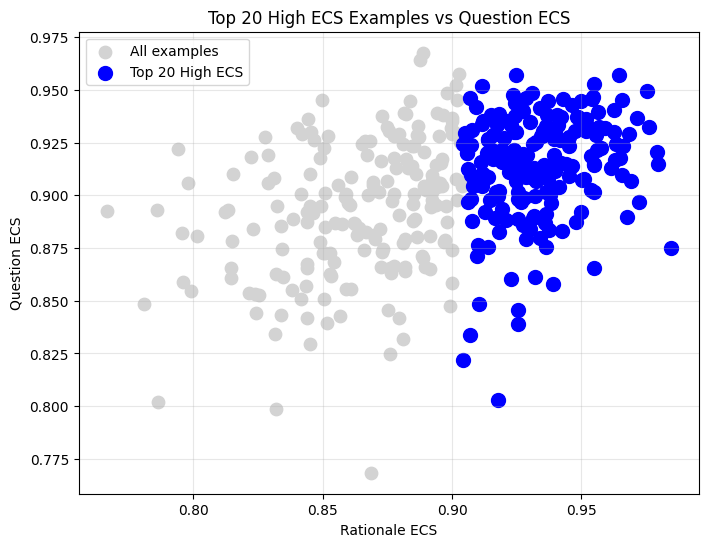

💾 Saved top 20 high ECS rationales ranked by ECS to gsm8k/high_ecs_rationales_llama3_gsm8k.csv


In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# Load LLaMA3 rationale ECS
# -----------------------------
rationale_df = pd.read_csv("gsm8k/gsm8k_llama3_ECS_scores.csv")

# Load question ECS
question_df = pd.read_csv("gsm8k/gsm8k_questions_ECS_scores.csv")

# -----------------------------
# Merge ECS scores
# -----------------------------
merged_df = rationale_df.merge(
    question_df[['id','Question_ECS']],
    on='id',
    how='left'
)

# -----------------------------
# Exclude specific IDs if needed
# -----------------------------
remove_ids = [
    2,7,27, 30, 36, 46, 47, 66, 82,85, 98, 103, 106, 110,111, 120,123, 127,128,135,143,145,146,149,
    150, 160, 168, 177, 190 ,196,204,207,209,212,214, 219,221,224, 229,230,238,263, 265,277,282,285,286, 287, 289,291, 309,314,317,323,326,336,339,340,342,352,355,
    357,362, 367, 369,376, 378,380, 384,385,398, 403, 416,420,424,425,431, 434,439,442,468,471,487,489, 492,
    36,51,75,63,69,92,93,100,112,115,116,125,130,170,183,215,219,225,237,257,271,
    303,311,315,332,347,348,350,357,367,369,371,372,374,445,454,460,462,488,489,499
]
# Count before removing
num_before = len(merged_df)

# Apply filtering
merged_df = merged_df[~merged_df['id'].isin(remove_ids)]

# Count after removing
num_after = len(merged_df)
num_removed = num_before - num_after

print(f"🗑️ Removed {num_removed} examples based on remove_ids.")
print(f"✅ {num_after} examples remaining after filtering.")


# -----------------------------
# Step 1: Select top 20 examples by Rationale ECS
# -----------------------------
top_20_ecs = merged_df.sort_values('ECS', ascending=False).head(190).copy()#CHECK HERE ------------------------------------------------------------

# -----------------------------
# Step 2: Compute ECS difference (for reference only)
# -----------------------------
top_20_ecs['ECS_diff'] = top_20_ecs['ECS'] - top_20_ecs['Question_ECS']

# -----------------------------
# Step 3: Rank the top 20 by ECS (highest first)
# -----------------------------
top_20_ranked = top_20_ecs.sort_values('ECS', ascending=False)
print("🔹 Top 20 high ECS examples ranked by ECS:")
#print(top_20_ranked[['id','ECS','Question_ECS','ECS_diff']])

# -----------------------------
# Scatter plot
# -----------------------------
plt.figure(figsize=(8,6))
plt.scatter(merged_df['ECS'], merged_df['Question_ECS'], color='lightgray', s=80, label='All examples')
plt.scatter(top_20_ranked['ECS'], top_20_ranked['Question_ECS'], color='blue', s=100, label='Top 20 High ECS')
plt.xlabel("Rationale ECS")
plt.ylabel("Question ECS")
plt.title("Top 20 High ECS Examples vs Question ECS")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# -----------------------------
# Export the top 20 rationales for inspection
# -----------------------------
llama_rationales_df = pd.read_csv("gsm8k/gsm8k_llama3_CoT_responses_merged_clean.csv")
top_rationales = llama_rationales_df[llama_rationales_df['id'].isin(top_20_ranked['id'].tolist())]

# Merge ECS and ECS_diff for reference
top_rationales = top_rationales.merge(
    top_20_ranked[['id','ECS','ECS_diff']],
    on='id',
    how='left'
)

# Sort by ECS (highest first)
top_rationales = top_rationales.sort_values('ECS', ascending=False)

# Merge correct answers
answers_df = pd.read_csv("gsm8k/gsm8k_500_rows_with_answers.csv")
top_rationales = top_rationales.merge(
    answers_df[['id','answer']],
    on='id',
    how='left'
).rename(columns={'answer':'correct_answer'})

# Optional: drop ECS_diff if you don't need it in the CSV
# top_rationales = top_rationales.drop(columns=['ECS_diff'])

# Save CSV
output_file = "gsm8k/high_ecs_rationales_llama3_gsm8k.csv"
top_rationales.to_csv(output_file, index=False)
print(f"💾 Saved top 20 high ECS rationales ranked by ECS to {output_file}")




In [3]:
import pandas as pd
import re
import math

# =====================================================
# STEP 1: Define helper functions
# =====================================================
def extract_llm_answer(text):
    """
    Extract the numeric final answer that follows the *exact* phrase 'Final Answer:'.
    - Only uses 'Final Answer:' (case-sensitive)
    - Skips placeholders like <number or expression>
    - Handles comma-formatted numbers like 6,000
    """
    if not isinstance(text, str):
        return None
    s = text.strip()

    # Strictly match 'Final Answer:' (not lowercase variants)
    pattern = re.compile(r"Final Answer\s*:\s*(.*)")
    matches = list(pattern.finditer(s))
    if not matches:
        return None

    # Extract text after the first 'Final Answer:'
    after = matches[0].group(1).strip()

    # If placeholder-like content — skip to the next "Final Answer:"
    placeholder_re = re.compile(r"^<\s*(number|num|expression|ans)\s*[^>]*>$", re.IGNORECASE)
    if placeholder_re.match(after) and len(matches) > 1:
        after = matches[1].group(1).strip()

    # Remove commas in numbers for easier parsing (e.g., 6,000 -> 6000)
    after_clean = re.sub(r"(?<=\d),(?=\d)", "", after)

    # Try to directly find numeric info in that line
    num_match = re.search(r"[-+]?\d*\.?\d+(?:/\d+)?", after_clean)
    if num_match:
        return num_match.group(0)

    # If not found, maybe the number is on the next line
    lines = s.splitlines()
    for i, line in enumerate(lines):
        if "Final Answer:" in line:
            # Look at the next non-empty line
            for j in range(i + 1, len(lines)):
                next_line = lines[j].strip()
                if not next_line:
                    continue
                next_line = re.sub(r"(?<=\d),(?=\d)", "", next_line)
                num_match = re.search(r"[-+]?\d*\.?\d+(?:/\d+)?", next_line)
                if num_match:
                    return num_match.group(0)
                break
            break

    return None





def extract_gsm8k_answer(text):
    """Extract the gold answer after '####'."""
    match = re.search(r"####\s*(.*)", str(text))
    return match.group(1).strip() if match else None


def normalize_answer(ans):
    """Normalize numeric or text answers (handles commas, decimals, fractions)."""
    if ans is None:
        return None
    ans = ans.strip().lower().replace(",", "")
    match = re.search(r"[-+]?\d*\.?\d+(?:/\d+)?", ans)
    if match:
        return match.group(0)
    return ans


def answers_equal(a, b, tol=1e-6):
    """Compare answers numerically if possible, otherwise by string."""
    if a is None or b is None:
        return False
    try:
        return math.isclose(float(a), float(b), rel_tol=tol, abs_tol=tol)
    except ValueError:
        return str(a).strip().lower() == str(b).strip().lower()


# =====================================================
# STEP 2: Function to calculate average accuracy for a file
# =====================================================
def compute_accuracy(file_path):
    df = pd.read_csv(file_path)
    results = []

    for i, row in df.iterrows():
        correct = extract_gsm8k_answer(row["correct_answer"])
        correct_norm = normalize_answer(correct)
        correctness = []
        extracted_answers = {}

        for col in ["cot_original", "cot_lexical", "cot_syntactic", "cot_contextual"]:
            llm_ans = extract_llm_answer(row[col])
            llm_norm = normalize_answer(llm_ans)
            extracted_answers[col] = llm_norm
            correctness.append(int(answers_equal(llm_norm, correct_norm)))

        row_result = {
            "id": row["id"],
            "correct_answer": correct_norm,
            **{f"{col}_extracted": val for col, val in extracted_answers.items()},
            "average_accuracy": sum(correctness) / len(correctness)
        }
        results.append(row_result)

    compare_df = pd.DataFrame(results)

    # Compute average accuracy
    accuracy_per_column = {
        col: compare_df.apply(lambda r: answers_equal(r[f"{col}_extracted"], r["correct_answer"]), axis=1).mean()
        for col in ["cot_original", "cot_lexical", "cot_syntactic", "cot_contextual"]
    }

    overall_avg_accuracy = sum(accuracy_per_column.values()) / len(accuracy_per_column) * 100
    return compare_df, accuracy_per_column, overall_avg_accuracy


# =====================================================
# STEP 3: Process low ECS file
# =====================================================
low_file = "gsm8k/low_ecs_rationales_llama3_gsm8k.csv"
low_df, low_acc_cols, low_overall = compute_accuracy(low_file)
print("🔹 Low ECS examples:")
for col, acc in low_acc_cols.items():
    print(f"{col}: {acc*100:.2f}%")
print(f"Overall average accuracy: {low_overall:.2f}%\n")

# =====================================================
# STEP 4: Process high ECS file
# =====================================================
high_file = "gsm8k/high_ecs_rationales_llama3_gsm8k.csv"
high_df, high_acc_cols, high_overall = compute_accuracy(high_file)
print("🔹 High ECS examples:")
for col, acc in high_acc_cols.items():
    print(f"{col}: {acc*100:.2f}%")
print(f"Overall average accuracy: {high_overall:.2f}%\n")

# =====================================================
# STEP 5: Optionally save comparison summaries
# =====================================================
low_df.to_csv("gsm8k/low_ecs_accuracy_summary.csv", index=False)
high_df.to_csv("gsm8k/high_ecs_accuracy_summary.csv", index=False)
print("🎉 Saved comparison summaries for both low and high ECS examples.")





🔹 Low ECS examples:
cot_original: 74.74%
cot_lexical: 74.74%
cot_syntactic: 74.74%
cot_contextual: 69.47%
Overall average accuracy: 73.42%

🔹 High ECS examples:
cot_original: 90.00%
cot_lexical: 90.53%
cot_syntactic: 87.37%
cot_contextual: 87.89%
Overall average accuracy: 88.95%

🎉 Saved comparison summaries for both low and high ECS examples.


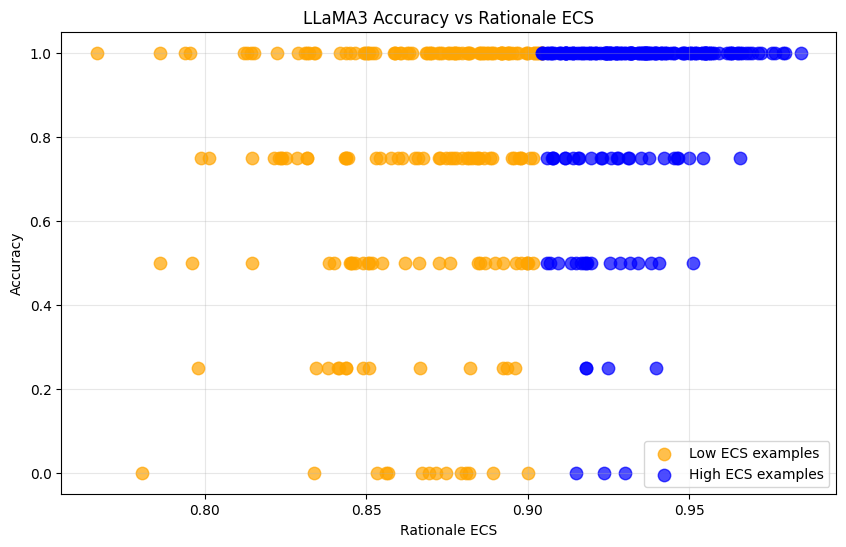

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# Load accuracy summaries
# =========================
low_df = pd.read_csv("gsm8k/low_ecs_accuracy_summary.csv")
high_df = pd.read_csv("gsm8k/high_ecs_accuracy_summary.csv")

# =========================
# Load ECS scores
# =========================
ecs_df = pd.read_csv("gsm8k/gsm8k_llama3_ECS_scores.csv")[["id", "ECS"]]

# =========================
# Merge ECS scores into low/high accuracy data
# =========================
low_plot_df = low_df.merge(ecs_df, on="id", how="left")
high_plot_df = high_df.merge(ecs_df, on="id", how="left")

# =========================
# Scatter plot
# =========================
plt.figure(figsize=(10,6))

# Low ECS points
plt.scatter(
    low_plot_df['ECS'],
    low_plot_df['average_accuracy'],
    color='orange',
    s=80,
    alpha=0.7,
    label='Low ECS examples'
)

# High ECS points
plt.scatter(
    high_plot_df['ECS'],
    high_plot_df['average_accuracy'],
    color='blue',
    s=80,
    alpha=0.7,
    label='High ECS examples'
)

plt.xlabel("Rationale ECS")
plt.ylabel("Accuracy")
plt.title("LLaMA3 Accuracy vs Rationale ECS")
plt.grid(alpha=0.3)
plt.legend()
plt.show()


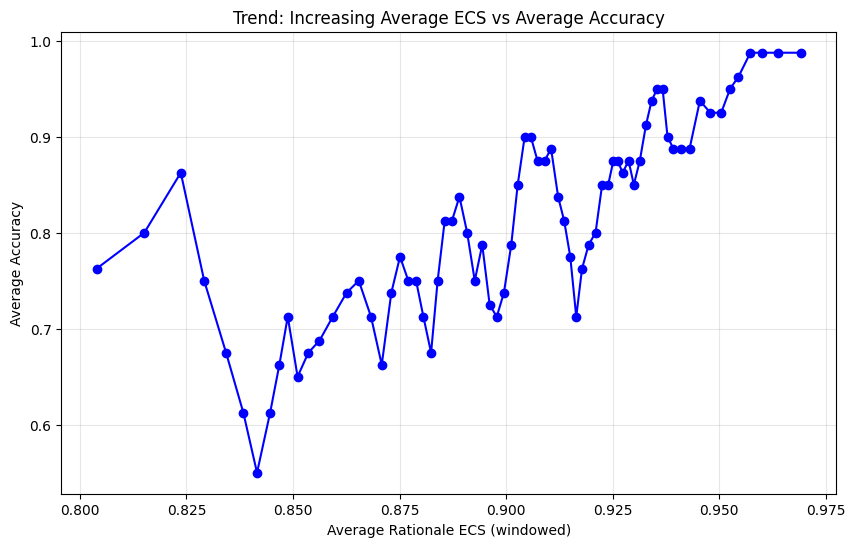

💾 Saved rolling window ECS vs accuracy summary


In [5]:
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# File paths
# -----------------------------
ecs_file = "gsm8k/gsm8k_llama3_ECS_scores.csv"
low_accuracy_file = "gsm8k/low_ecs_accuracy_summary.csv"
high_accuracy_file = "gsm8k/high_ecs_accuracy_summary.csv"

# -----------------------------
# Load ECS and accuracy data
# -----------------------------
ecs_df = pd.read_csv(ecs_file)[["id", "ECS"]]
low_df = pd.read_csv(low_accuracy_file)[["id","average_accuracy"]]
high_df = pd.read_csv(high_accuracy_file)[["id","average_accuracy"]]

# Merge low/high accuracy into a single dataframe
accuracy_df = pd.concat([low_df, high_df], ignore_index=True)
combined_df = accuracy_df.merge(ecs_df, on="id", how="left")

# -----------------------------
# Sort by ECS
# -----------------------------
combined_df = combined_df.sort_values("ECS").reset_index(drop=True)

# -----------------------------
# Parameters for windowing
# -----------------------------
window_size = 20  # number of examples per window
step_size = 5     # step to slide the window
avg_ecs_list = []
avg_acc_list = []

# -----------------------------
# Compute rolling averages
# -----------------------------
for start in range(0, len(combined_df) - window_size + 1, step_size):
    window = combined_df.iloc[start:start+window_size]
    avg_ecs_list.append(window['ECS'].mean())
    avg_acc_list.append(window['average_accuracy'].mean())

# -----------------------------
# Plot
# -----------------------------
plt.figure(figsize=(10,6))
plt.plot(avg_ecs_list, avg_acc_list, marker='o', color='blue')
plt.xlabel("Average Rationale ECS (windowed)")
plt.ylabel("Average Accuracy")
plt.title("Trend: Increasing Average ECS vs Average Accuracy")
plt.grid(alpha=0.3)
plt.show()

# -----------------------------
# Optional: save rolling average results
# -----------------------------
rolling_df = pd.DataFrame({
    "avg_ECS": avg_ecs_list,
    "avg_accuracy": avg_acc_list
})
rolling_df.to_csv("gsm8k/rolling_avg_ecs_accuracy.csv", index=False)
print("💾 Saved rolling window ECS vs accuracy summary")


/var/folders/vk/18ngtwrs58n0x_sklvrh_58h0000gn/T/ipykernel_85468/533528209.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_stats = df.groupby('ecs_bin').agg(


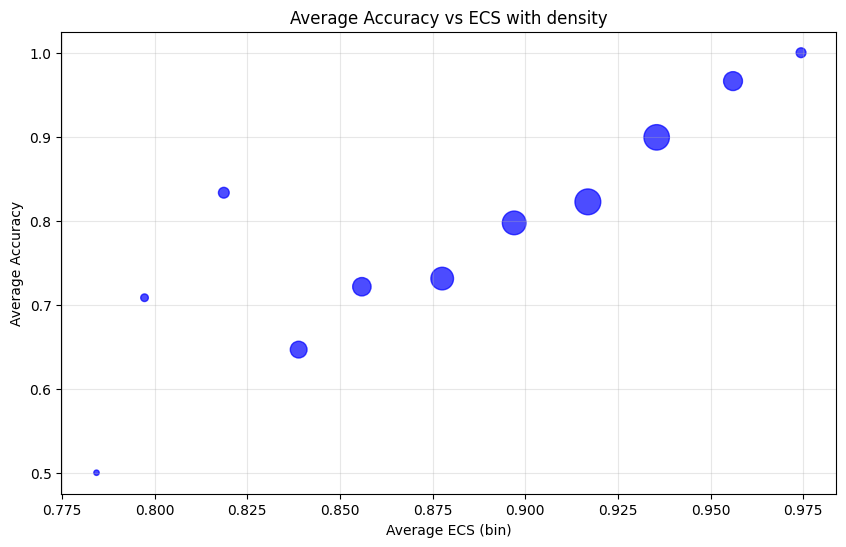

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load data
ecs_df = pd.read_csv("gsm8k/gsm8k_llama3_ECS_scores.csv")[["id","ECS"]]
low_df = pd.read_csv("gsm8k/low_ecs_accuracy_summary.csv")
high_df = pd.read_csv("gsm8k/high_ecs_accuracy_summary.csv")

# Merge everything
df = pd.concat([low_df, high_df], ignore_index=True)
df = df.merge(ecs_df, on="id", how="left")

# Bin ECS scores
bins = np.arange(df['ECS'].min(), df['ECS'].max()+0.02, 0.02)
df['ecs_bin'] = pd.cut(df['ECS'], bins=bins)

# Compute average accuracy and count per bin
bin_stats = df.groupby('ecs_bin').agg(
    avg_ECS=('ECS','mean'),
    avg_accuracy=('average_accuracy','mean'),
    count=('id','count')
).reset_index()

# Scatter plot
plt.figure(figsize=(10,6))
plt.scatter(bin_stats['avg_ECS'], bin_stats['avg_accuracy'], 
            s=bin_stats['count']*5,  # scale size by number of examples
            alpha=0.7, color='blue')
plt.xlabel("Average ECS (bin)")
plt.ylabel("Average Accuracy")
plt.title("Average Accuracy vs ECS with density")
plt.grid(alpha=0.3)
plt.show()


/var/folders/vk/18ngtwrs58n0x_sklvrh_58h0000gn/T/ipykernel_17152/1181982399.py:33: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_density = df.groupby('ecs_bin')['id'].count()
/var/folders/vk/18ngtwrs58n0x_sklvrh_58h0000gn/T/ipykernel_17152/1181982399.py:34: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_mid = df.groupby('ecs_bin')['ECS'].mean()


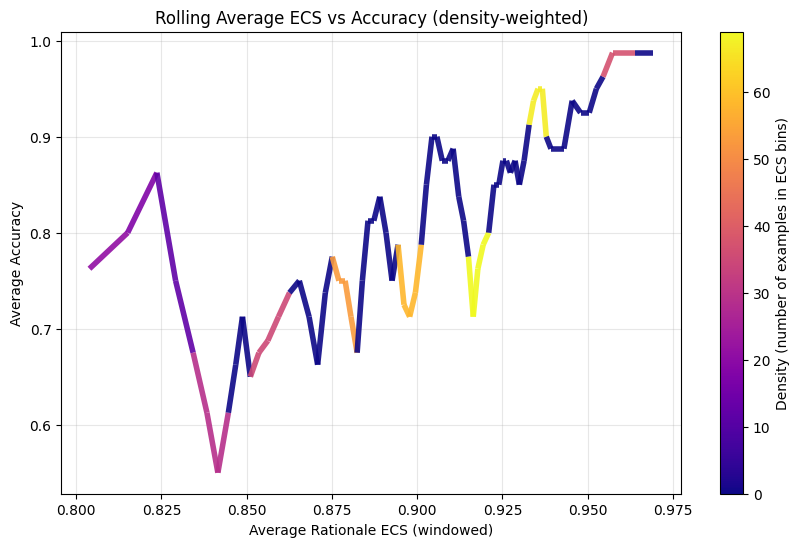

💾 Saved rolling window ECS vs accuracy with density info


In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.collections import LineCollection
from matplotlib.colors import Normalize
import matplotlib.cm as cm

# -----------------------------
# File paths
# -----------------------------
ecs_file = "gsm8k/gsm8k_llama3_ECS_scores.csv"
low_accuracy_file = "gsm8k/low_ecs_accuracy_summary.csv"
high_accuracy_file = "gsm8k/high_ecs_accuracy_summary.csv"

# -----------------------------
# Load data
# -----------------------------
ecs_df = pd.read_csv(ecs_file)[["id","ECS"]]
low_df = pd.read_csv(low_accuracy_file)[["id","average_accuracy"]]
high_df = pd.read_csv(high_accuracy_file)[["id","average_accuracy"]]

df = pd.concat([low_df, high_df], ignore_index=True)
df = df.merge(ecs_df, on="id", how="left")
df = df.sort_values("ECS").reset_index(drop=True)

# -----------------------------
# Bin ECS to compute density
# -----------------------------
bin_width = 0.02
bins = np.arange(df['ECS'].min(), df['ECS'].max() + bin_width, bin_width)
df['ecs_bin'] = pd.cut(df['ECS'], bins=bins)

bin_density = df.groupby('ecs_bin')['id'].count()
bin_mid = df.groupby('ecs_bin')['ECS'].mean()

bin_stats = pd.DataFrame({
    'bin_mid': bin_mid,
    'density': bin_density
}).reset_index(drop=True)

# -----------------------------
# Rolling window parameters
# -----------------------------
window_size = 20
step_size = 5

avg_ecs_list = []
avg_acc_list = []
window_density = []

# -----------------------------
# Compute rolling averages and assign density
# -----------------------------
for start in range(0, len(df) - window_size + 1, step_size):
    window = df.iloc[start:start+window_size]
    avg_ecs_list.append(window['ECS'].mean())
    avg_acc_list.append(window['average_accuracy'].mean())
    
    ecs_min, ecs_max = window['ECS'].min(), window['ECS'].max()
    overlapping_bins = bin_stats[(bin_stats['bin_mid'] >= ecs_min) & (bin_stats['bin_mid'] <= ecs_max)]
    window_density.append(overlapping_bins['density'].sum())

# -----------------------------
# Prepare colored line
# -----------------------------
points = np.array([avg_ecs_list, avg_acc_list]).T.reshape(-1, 1, 2)
segments = np.concatenate([points[:-1], points[1:]], axis=1)

norm = Normalize(vmin=min(window_density), vmax=max(window_density))
# Change colormap to 'plasma' or 'coolwarm' for better contrast
colors = cm.plasma(norm(window_density[:-1]))

lc = LineCollection(segments, colors=colors, linewidth=4, alpha=0.9)  # thicker line

# -----------------------------
# Plot
# -----------------------------
fig, ax = plt.subplots(figsize=(10,6))
ax.add_collection(lc)
ax.autoscale()
ax.set_xlabel("Average Rationale ECS (windowed)")
ax.set_ylabel("Average Accuracy")
ax.set_title("Rolling Average ECS vs Accuracy (density-weighted)")
ax.grid(alpha=0.3)

# Colorbar
sm = cm.ScalarMappable(cmap=cm.plasma, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax)
cbar.set_label("Density (number of examples in ECS bins)")

plt.show()

# -----------------------------
# Save results
# -----------------------------
rolling_df = pd.DataFrame({
    "avg_ECS": avg_ecs_list,
    "avg_accuracy": avg_acc_list,
    "density": window_density
})
rolling_df.to_csv("gsm8k/rolling_avg_ecs_accuracy_density_windowed.csv", index=False)
print("💾 Saved rolling window ECS vs accuracy with density info")



/var/folders/vk/18ngtwrs58n0x_sklvrh_58h0000gn/T/ipykernel_85468/3176764603.py:35: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_density = df.groupby('ecs_bin')['id'].count()
/var/folders/vk/18ngtwrs58n0x_sklvrh_58h0000gn/T/ipykernel_85468/3176764603.py:36: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_mid = df.groupby('ecs_bin')['ECS'].mean()
/var/folders/vk/18ngtwrs58n0x_sklvrh_58h0000gn/T/ipykernel_85468/3176764603.py:114: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.leg

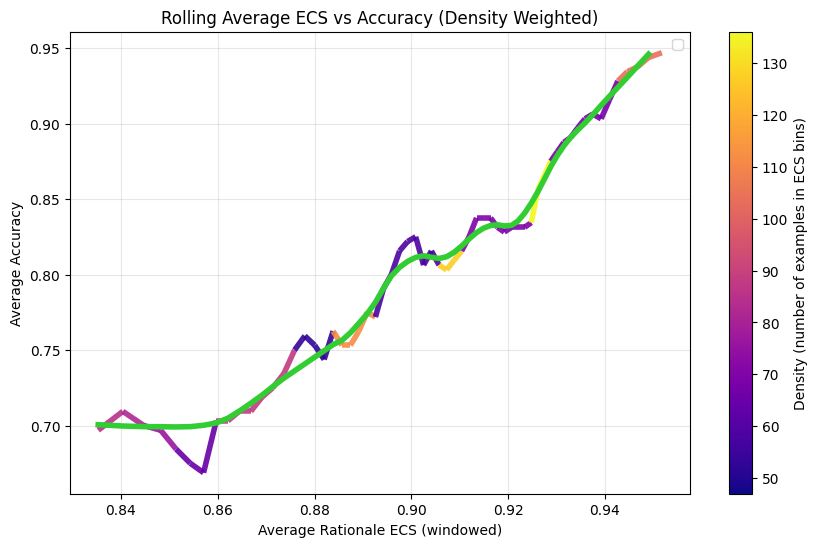

💾 Saved rolling window ECS vs accuracy with density info
✨ Smoothed trend added (LOWESS using high-density regions).


In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.collections import LineCollection
from matplotlib.colors import Normalize
import matplotlib.cm as cm
from statsmodels.nonparametric.smoothers_lowess import lowess

# -----------------------------
# File paths
# -----------------------------
ecs_file = "gsm8k/gsm8k_llama3_ECS_scores.csv"
low_accuracy_file = "gsm8k/low_ecs_accuracy_summary.csv"
high_accuracy_file = "gsm8k/high_ecs_accuracy_summary.csv"


# -----------------------------
# Load data
# -----------------------------
ecs_df = pd.read_csv(ecs_file)[["id","ECS"]]
low_df = pd.read_csv(low_accuracy_file)[["id","average_accuracy"]]
high_df = pd.read_csv(high_accuracy_file)[["id","average_accuracy"]]

df = pd.concat([low_df, high_df], ignore_index=True)
df = df.merge(ecs_df, on="id", how="left")
df = df.sort_values("ECS").reset_index(drop=True)

# -----------------------------
# Bin ECS to compute density
# -----------------------------
bin_width = 0.02
bins = np.arange(df['ECS'].min(), df['ECS'].max() + bin_width, bin_width)
df['ecs_bin'] = pd.cut(df['ECS'], bins=bins)

bin_density = df.groupby('ecs_bin')['id'].count()
bin_mid = df.groupby('ecs_bin')['ECS'].mean()

bin_stats = pd.DataFrame({
    'bin_mid': bin_mid,
    'density': bin_density
}).reset_index(drop=True)

# -----------------------------
# Rolling window parameters
# -----------------------------
window_size = 80
step_size = 5

avg_ecs_list = []
avg_acc_list = []
window_density = []

# -----------------------------
# Compute rolling averages and assign density
# -----------------------------
for start in range(0, len(df) - window_size + 1, step_size):
    window = df.iloc[start:start+window_size]
    avg_ecs_list.append(window['ECS'].mean())
    avg_acc_list.append(window['average_accuracy'].mean())
    
    ecs_min, ecs_max = window['ECS'].min(), window['ECS'].max()
    overlapping_bins = bin_stats[(bin_stats['bin_mid'] >= ecs_min) & (bin_stats['bin_mid'] <= ecs_max)]
    window_density.append(overlapping_bins['density'].sum())

# -----------------------------
# Prepare colored zigzag line
# -----------------------------
points = np.array([avg_ecs_list, avg_acc_list]).T.reshape(-1, 1, 2)
segments = np.concatenate([points[:-1], points[1:]], axis=1)

norm = Normalize(vmin=min(window_density), vmax=max(window_density))
colors = cm.plasma(norm(window_density[:-1]))

lc = LineCollection(segments, colors=colors, linewidth=4, alpha=0.9)

# -----------------------------
# Create plot
# -----------------------------
fig, ax = plt.subplots(figsize=(10,6))
ax.add_collection(lc)
ax.autoscale()
ax.set_xlabel("Average Rationale ECS (windowed)")
ax.set_ylabel("Average Accuracy")
ax.set_title("Rolling Average ECS vs Accuracy (Density Weighted)")
ax.grid(alpha=0.3)

# -----------------------------
# Colorbar
# -----------------------------
sm = cm.ScalarMappable(cmap=cm.plasma, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax)
cbar.set_label("Density (number of examples in ECS bins)")

# -----------------------------
# Smooth only high-density regions
# -----------------------------
# -----------------------------
# Smooth only high-density regions
# -----------------------------
density_threshold = np.percentile(window_density, 20)  # keep top 40% dense windows
mask = np.array(window_density) >= density_threshold

ecs_high = np.array(avg_ecs_list)[mask]
acc_high = np.array(avg_acc_list)[mask]

# LOWESS smoothing (more smooth)
smooth = lowess(acc_high, ecs_high, frac=0.2, return_sorted=True)  # increased frac
smooth_ecs = smooth[:,0]
smooth_acc = smooth[:,1]

# Plot smoothed trend backbone (green line)
ax.plot(smooth_ecs, smooth_acc, color="#32CD32", linewidth=4)
ax.legend()




plt.show()

print("💾 Saved rolling window ECS vs accuracy with density info")
print("✨ Smoothed trend added (LOWESS using high-density regions).")


**Mistral post analysis**

In [9]:
forbidden_ids = {
    7,66,103,127,135,145,
    146,149,150,190,207,212,
    326,355,362,
    384,420,431,468,
    471
}


✅ 314 examples remaining after filtering.


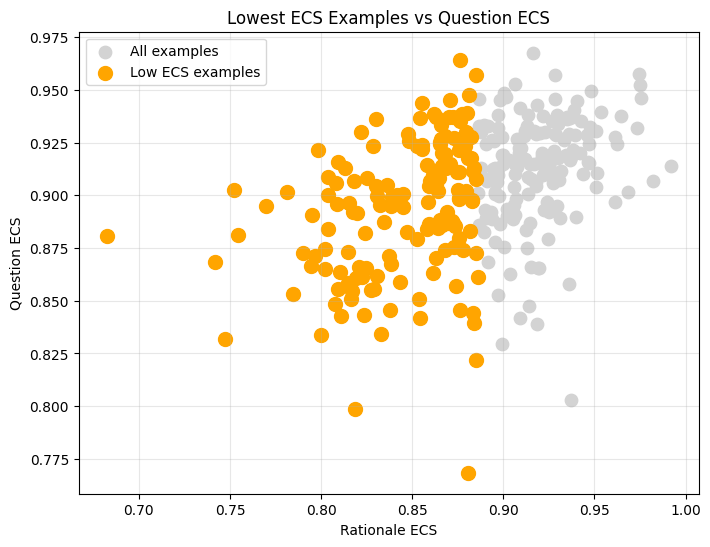

💾 Saved top 20 lowest ECS rationales ranked by ECS to gsm8k/low_ecs_rationales_mistral_gsm8k.csv


NameError: name 'forbidden_ids' is not defined

In [13]:
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# Load LLaMA3 rationale ECS
# -----------------------------
rationale_df = pd.read_csv("gsm8k/gsm8k_mistral7B_ECS.csv")

# Load question ECS
question_df = pd.read_csv("gsm8k/gsm8k_questions_ECS_scores.csv")

# -----------------------------
# Merge ECS scores
# -----------------------------
merged_df = rationale_df.merge(
    question_df[['id','Question_ECS']],
    on='id',
    how='left'
)

# -----------------------------
# Exclude specific IDs
# -----------------------------
remove_ids = [
    2,7,21, 22,24,27,37, 40, 42,44, 47,52, 54, 57,58,66,71,76,85,105, 109, 111, 117, 120,121, 123,128,131, 133,135, 140,143, 144,145,146, 147,149,150,159,
    161,162,164,166, 176, 177, 178, 180, 181, 186,196, 197,207,204, 209, 211,212, 214,215, 220, 221,224, 227,229,
    230, 232, 238, 239, 242, 249, 250,258,261, 263,274, 277, 281, 282, 283, 284,285,286,287,289, 298,
    306, 309, 310, 312, 314,317, 319,321,323,326,332,334,336,338,339,340,342, 351,352, 353,354,355,255,361,362,365, 370,372, 376, 377, 380, 381,384,385,386,386,387,
    391,398 ,409,410,414, 415,416,420, 422,424,425,431,434,439,442,445, 448, 455, 459, 461,468, 469,471,472,487 ,492, 
    36, 51, 75, 63, 69, 92, 93, 100, 112, 115, 116, 125, 130, 170, 183,190,
    219, 225, 237, 257, 271,279, 303, 311, 315, 347, 348, 350, 357, 367, 369,
    371, 374, 429,454, 460, 462, 488, 489, 499
]

# Count before removing
num_before = len(merged_df)

# Apply filtering
merged_df = merged_df[~merged_df['id'].isin(remove_ids)]

# Count after removing
num_after = len(merged_df)
num_removed = num_before - num_after


print(f"✅ {num_after} examples remaining after filtering.")


# -----------------------------
# Step 1: Select the lowest 20 ECS examples
# -----------------------------
low_20_ecs = merged_df.sort_values('ECS', ascending=True).head(157).copy()##CHECK HERE -------------------------------------------------------------

# -----------------------------
# Step 2: Compute ECS difference (Rationale ECS - Question ECS) for reference
# -----------------------------
low_20_ecs['ECS_diff'] = low_20_ecs['ECS'] - low_20_ecs['Question_ECS']

# -----------------------------
# Step 3: Rank these 20 by ECS (lowest first)
# -----------------------------
low_20_ranked = low_20_ecs.sort_values('ECS', ascending=True)

#print("🔹 Top 20 lowest ECS examples ranked by ECS:")
#print(low_20_ranked[['id','ECS','Question_ECS','ECS_diff']])

# -----------------------------
# Scatter plot
# -----------------------------
plt.figure(figsize=(8,6))
plt.scatter(merged_df['ECS'], merged_df['Question_ECS'], color='lightgray', s=80, label='All examples')
plt.scatter(low_20_ranked['ECS'], low_20_ranked['Question_ECS'], color='orange', s=100, label='Low ECS examples')
plt.xlabel("Rationale ECS")
plt.ylabel("Question ECS")
plt.title("Lowest ECS Examples vs Question ECS")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# -----------------------------
# Step 4: Export the corresponding LLaMA3 rationales
# -----------------------------
mistral_rationales_df = pd.read_csv("gsm8k/gsm8k_mistral7B_CoT_responses_merged.csv")
low_rationales = mistral_rationales_df[mistral_rationales_df['id'].isin(low_20_ranked['id'].tolist())]

# Merge correct answers
answers_df = pd.read_csv("gsm8k/gsm8k_500_rows_with_answers.csv")
low_rationales = low_rationales.merge(
    answers_df[['id','answer']],
    on='id',
    how='left'
).rename(columns={'answer':'correct_answer'})

# Merge ECS and ECS_diff for reference, then sort by ECS
low_rationales = low_rationales.merge(
    low_20_ranked[['id','ECS','ECS_diff']],
    on='id',
    how='left'
).sort_values('ECS', ascending=True)

# Optional: drop ECS_diff if you don't need it in the CSV
# low_rationales = low_rationales.drop(columns=['ECS_diff'])

# Save CSV
output_file = "gsm8k/low_ecs_rationales_mistral_gsm8k.csv"
low_rationales.to_csv(output_file, index=False)
print(f"💾 Saved top 20 lowest ECS rationales ranked by ECS to {output_file}")




# ---------------------------------------------------------
# CHECK: Forbidden IDs in final low ECS output
# ---------------------------------------------------------
df_check = pd.read_csv("gsm8k/low_ecs_rationales_mistral_gsm8k.csv")

last_10_ids = set(df_check.tail(10)["id"].tolist())
bad_ids = last_10_ids & forbidden_ids

if bad_ids:
    print("⚠️ WARNING: Forbidden IDs detected in LAST 10 LOW-ECS OUTPUT ROWS!")
    print("Forbidden IDs:", sorted(bad_ids))
else:
    print("✅ No forbidden IDs in the last 10 low-ECS rows.")


✅ 314 examples remaining after filtering.
🔹 Top 20 high ECS examples ranked by ECS:


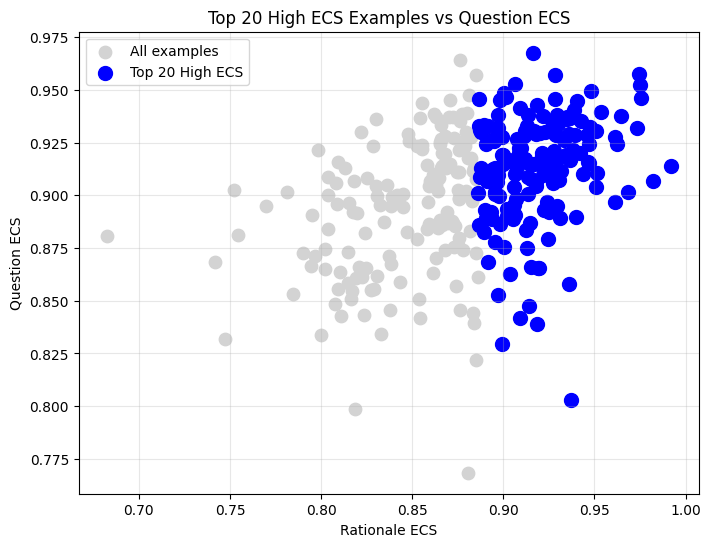

💾 Saved top 20 high ECS rationales ranked by ECS to gsm8k/high_ecs_rationales_mistral_gsm8k.csv


NameError: name 'forbidden_ids' is not defined

In [14]:
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# Load LLaMA3 rationale ECS
# -----------------------------
rationale_df = pd.read_csv("gsm8k/gsm8k_mistral7B_ECS.csv")

# Load question ECS
question_df = pd.read_csv("gsm8k/gsm8k_questions_ECS_scores.csv")

# -----------------------------
# Merge ECS scores
# -----------------------------
merged_df = rationale_df.merge(
    question_df[['id','Question_ECS']],
    on='id',
    how='left'
)

# -----------------------------
# Exclude specific IDs if needed
# -----------------------------
remove_ids = [
    2,7,21, 22,24,27,37, 40, 42,44, 47,52, 54, 57,58,66,71,76,85,105, 109, 111, 117, 120,121, 123,128,131, 133,135, 140,143, 144,145,146, 147,149,150,159,
    161,162,164,166, 176, 177, 178, 180, 181, 186,196, 197,207,204, 209, 211,212, 214,215, 220, 221,224, 227,229,
    230, 232, 238, 239, 242, 249, 250,258,261, 263,274, 277, 281, 282, 283, 284,285,286,287,289, 298,
    306, 309, 310, 312, 314,317, 319,321,323,326,332,334,336,338,339,340,342, 351,352, 353,354,355,255,361,362,365, 370,372, 376, 377, 380, 381,384,385,386,386,387,
    391,398 ,409,410,414, 415,416,420, 422,424,425,431,434,439,442,445, 448, 455, 459, 461,468, 469,471,472,487 ,492, 
    36, 51, 75, 63, 69, 92, 93, 100, 112, 115, 116, 125, 130, 170, 183,190,
    219, 225, 237, 257, 271,279, 303, 311, 315, 347, 348, 350, 357, 367, 369,
    371, 374, 429,454, 460, 462, 488, 489, 499
]

# Count before removing
num_before = len(merged_df)

# Apply filtering
merged_df = merged_df[~merged_df['id'].isin(remove_ids)]

# Count after removing
num_after = len(merged_df)
num_removed = num_before - num_after


print(f"✅ {num_after} examples remaining after filtering.")


# -----------------------------
# Step 1: Select top 20 examples by Rationale ECS
# -----------------------------
top_20_ecs = merged_df.sort_values('ECS', ascending=False).head(157).copy()#CHECK HERE ------------------------------------------------------------

# -----------------------------
# Step 2: Compute ECS difference (for reference only)
# -----------------------------
top_20_ecs['ECS_diff'] = top_20_ecs['ECS'] - top_20_ecs['Question_ECS']

# -----------------------------
# Step 3: Rank the top 20 by ECS (highest first)
# -----------------------------
top_20_ranked = top_20_ecs.sort_values('ECS', ascending=False)
print("🔹 Top 20 high ECS examples ranked by ECS:")
#print(top_20_ranked[['id','ECS','Question_ECS','ECS_diff']])

# -----------------------------
# Scatter plot
# -----------------------------
plt.figure(figsize=(8,6))
plt.scatter(merged_df['ECS'], merged_df['Question_ECS'], color='lightgray', s=80, label='All examples')
plt.scatter(top_20_ranked['ECS'], top_20_ranked['Question_ECS'], color='blue', s=100, label='Top 20 High ECS')
plt.xlabel("Rationale ECS")
plt.ylabel("Question ECS")
plt.title("Top 20 High ECS Examples vs Question ECS")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# -----------------------------
# Export the top 20 rationales for inspection
# -----------------------------
mistral_rationales_df = pd.read_csv("gsm8k/gsm8k_mistral7B_CoT_responses_merged.csv")
top_rationales = mistral_rationales_df[mistral_rationales_df['id'].isin(top_20_ranked['id'].tolist())]

# Merge ECS and ECS_diff for reference
top_rationales = top_rationales.merge(
    top_20_ranked[['id','ECS','ECS_diff']],
    on='id',
    how='left'
)

# Sort by ECS (highest first)
top_rationales = top_rationales.sort_values('ECS', ascending=False)

# Merge correct answers
answers_df = pd.read_csv("gsm8k/gsm8k_500_rows_with_answers.csv")
top_rationales = top_rationales.merge(
    answers_df[['id','answer']],
    on='id',
    how='left'
).rename(columns={'answer':'correct_answer'})

# Optional: drop ECS_diff if you don't need it in the CSV
# top_rationales = top_rationales.drop(columns=['ECS_diff'])

# Save CSV
output_file = "gsm8k/high_ecs_rationales_mistral_gsm8k.csv"
top_rationales.to_csv(output_file, index=False)
print(f"💾 Saved top 20 high ECS rationales ranked by ECS to {output_file}")




# ---------------------------------------------------------
# CHECK: Forbidden IDs in final high ECS output
# ---------------------------------------------------------
df_check = pd.read_csv("gsm8k/high_ecs_rationales_mistral_gsm8k.csv")

last_10_ids = set(df_check.tail(10)["id"].tolist())
bad_ids = last_10_ids & forbidden_ids

if bad_ids:
    print("⚠️ WARNING: Forbidden IDs detected in LAST 10 HIGH-ECS OUTPUT ROWS!")
    print("Forbidden IDs:", sorted(bad_ids))
else:
    print("✅ No forbidden IDs in the last 10 high-ECS rows.")


In [15]:
import pandas as pd
import re


# =====================================================
# Helper: Extract final answer from Mistral CoT
# =====================================================
def extract_final_answer(text):
    """Extract one or more numeric values after 'Final Answer:'"""
    if not isinstance(text, str):
        return " "
    m = re.search(r'final\s*answer\s*:\s*(.*)', text,
                  flags=re.IGNORECASE | re.DOTALL)
    if not m:
        return " "
    after = m.group(1).strip().splitlines()[0].strip().strip('“”"\'')
    nums = re.findall(r'[-+]?\$?\s*([\d,]+(?:\.\d+)?(?:e[+-]?\d+)?)', after)
    if nums:
        cleaned = [n.replace("$","").replace(",","").strip() for n in nums]
        return " ".join(cleaned)
    return " "


# =====================================================
# Helper: Extract GSM8K gold numeric answer
# =====================================================
def extract_ground_truth(text):
    if not isinstance(text, str):
        return " "
    m = re.search(r'####\s*([-+]?\$?\s*[\d,]+(?:\.\d+)?)', text)
    if m:
        return m.group(1).replace("$","").replace(",","").strip()
    return " "


# =====================================================
# Helper: Compare prediction vs truth
# =====================================================
def is_correct(preds, truth):
    if not isinstance(preds, str) or not isinstance(truth, str):
        return 0
    preds_list = [p.strip() for p in preds.split() if p.strip()]
    for p in preds_list:
        try:
            if float(p) == float(truth):
                return 1
        except:
            continue
    return 0


# =====================================================
# CORE FUNCTION — includes extracted answers in output CSV
# =====================================================
def compute_accuracy(file_path):

    df = pd.read_csv(file_path)

    # Extract numeric predictions
    df["final_original"]  = df["cot_original"].apply(extract_final_answer)
    df["final_lexical"]   = df["cot_lexical"].apply(extract_final_answer)
    df["final_syntactic"] = df["cot_syntactic"].apply(extract_final_answer)
    df["final_contextual"]= df["cot_contextual"].apply(extract_final_answer)

    # Load GSM8K gold answers
    answers_df = pd.read_csv("gsm8k/gsm8k_500_rows_with_answers.csv")
    answers_df["correct_answer"] = answers_df["answer"].apply(extract_ground_truth)

    # Normalize ID format
    df["id"] = df["id"].astype(str).str.strip()
    answers_df["id"] = answers_df["id"].astype(str).str.strip()

    # Merge answers
    df = df.merge(answers_df[["id","correct_answer"]], on="id", how="left")

    # FIX duplicate columns
    if "correct_answer_x" in df.columns:
        df = df.drop(columns=["correct_answer_x"])
    if "correct_answer_y" in df.columns:
        df = df.rename(columns={"correct_answer_y": "correct_answer"})

    # Compute correctness for each rationale
    for col in ["final_original","final_lexical","final_syntactic","final_contextual"]:
        df[col + "_correct"] = df.apply(
            lambda r: is_correct(r[col], r["correct_answer"]), axis=1
        )

    # Per-example average accuracy
    df["accuracy"] = df[
        ["final_original_correct","final_lexical_correct",
         "final_syntactic_correct","final_contextual_correct"]
    ].mean(axis=1)

    # Per-column summary
    column_accuracy = {
        col: df[col + "_correct"].mean()
        for col in ["final_original","final_lexical","final_syntactic","final_contextual"]
    }

    overall_accuracy = df["accuracy"].mean()

    # =========================================================
    # OUTPUT FORMAT SAME AS LLAMA:
    # id, correct_answer, final_original, final_lexical, ...
    # average_accuracy
    # =========================================================
    out_df = df[[
        "id",
        "correct_answer",
        "final_original",
        "final_lexical",
        "final_syntactic",
        "final_contextual",
        "accuracy"
    ]].copy()

    # Convert accuracy to percentage
    out_df["accuracy"] = (out_df["accuracy"] * 100).round(2)

    return out_df, column_accuracy, overall_accuracy


# =====================================================
# Run LOW ECS
# =====================================================
low_df, low_cols, low_overall = compute_accuracy("gsm8k/low_ecs_rationales_mistral_gsm8k.csv")

print("🔹 Low ECS examples:")
for k,v in low_cols.items():
    print(f"{k}: {v*100:.2f}%")
print(f"Overall average accuracy: {low_overall*100:.2f}%\n")

low_df.to_csv("gsm8k/low_ecs_accuracy_mistral.csv", index=False)


# =====================================================
# Run HIGH ECS
# =====================================================
high_df, high_cols, high_overall = compute_accuracy("gsm8k/high_ecs_rationales_mistral_gsm8k.csv")

print("🔹 High ECS examples:")
for k,v in high_cols.items():
    print(f"{k}: {v*100:.2f}%")
print(f"Overall average accuracy: {high_overall*100:.2f}%\n")

high_df.to_csv("gsm8k/high_ecs_accuracy_mistral.csv", index=False)

print("🎉 Accuracy summaries saved successfully!")


🔹 Low ECS examples:
final_original: 46.50%
final_lexical: 54.78%
final_syntactic: 51.59%
final_contextual: 52.23%
Overall average accuracy: 51.27%

🔹 High ECS examples:
final_original: 64.33%
final_lexical: 63.06%
final_syntactic: 61.78%
final_contextual: 67.52%
Overall average accuracy: 64.17%

🎉 Accuracy summaries saved successfully!


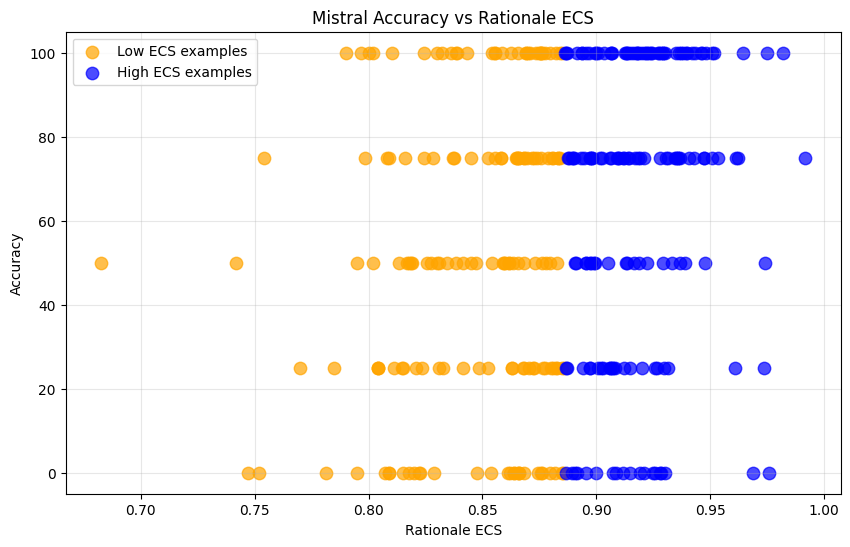

In [16]:
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# Load accuracy summaries (NOT raw rationales)
# =========================
low_df = pd.read_csv("gsm8k/low_ecs_accuracy_mistral.csv")
high_df = pd.read_csv("gsm8k/high_ecs_accuracy_mistral.csv")

# Rename accuracy to average_accuracy (to match your old plotting code)
low_df = low_df.rename(columns={"accuracy": "average_accuracy"})
high_df = high_df.rename(columns={"accuracy": "average_accuracy"})

# =========================
# Load ECS scores
# =========================
ecs_df = pd.read_csv("gsm8k/gsm8k_mistral7B_ECS.csv")[["id", "ECS"]]

# Ensure IDs are strings
low_df["id"] = low_df["id"].astype(str)
high_df["id"] = high_df["id"].astype(str)
ecs_df["id"] = ecs_df["id"].astype(str)

# =========================
# Merge ECS scores
# =========================
low_plot_df = low_df.merge(ecs_df, on="id", how="left")
high_plot_df = high_df.merge(ecs_df, on="id", how="left")

# =========================
# Scatter plot
# =========================
plt.figure(figsize=(10,6))

plt.scatter(
    low_plot_df['ECS'],
    low_plot_df['average_accuracy'],
    color='orange',
    s=80,
    alpha=0.7,
    label='Low ECS examples'
)

plt.scatter(
    high_plot_df['ECS'],
    high_plot_df['average_accuracy'],
    color='blue',
    s=80,
    alpha=0.7,
    label='High ECS examples'
)

plt.xlabel("Rationale ECS")
plt.ylabel("Accuracy")
plt.title("Mistral Accuracy vs Rationale ECS")
plt.grid(alpha=0.3)
plt.legend()
plt.show()



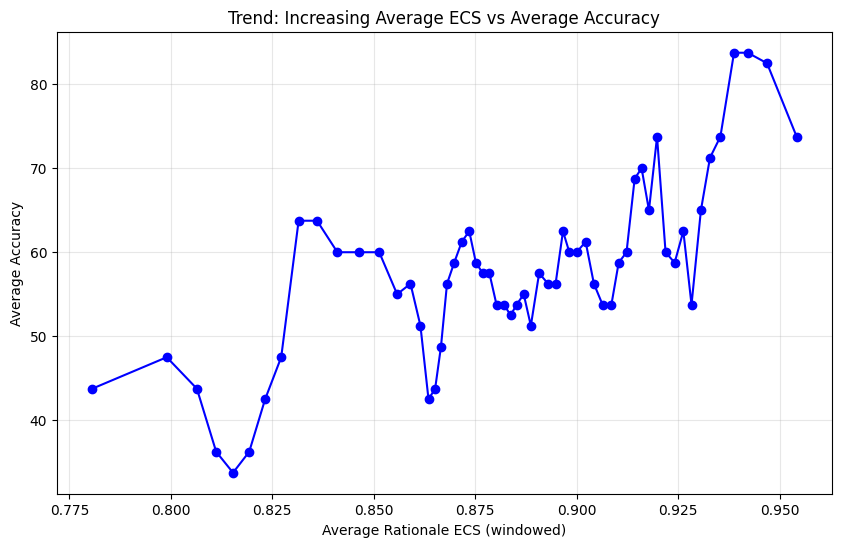

💾 Saved rolling window ECS vs accuracy summary


In [17]:
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# File paths
# -----------------------------
ecs_file = "gsm8k/gsm8k_mistral7B_ECS.csv"
low_accuracy_file = "gsm8k/low_ecs_accuracy_mistral.csv"
high_accuracy_file = "gsm8k/high_ecs_accuracy_mistral.csv"

# -----------------------------
# Load ECS and accuracy data
# -----------------------------
ecs_df = pd.read_csv(ecs_file)[["id", "ECS"]]
low_df = pd.read_csv(low_accuracy_file)[["id","accuracy"]]
high_df = pd.read_csv(high_accuracy_file)[["id","accuracy"]]

# Merge low/high accuracy into a single dataframe
accuracy_df = pd.concat([low_df, high_df], ignore_index=True)
combined_df = accuracy_df.merge(ecs_df, on="id", how="left")

# -----------------------------
# Sort by ECS
# -----------------------------
combined_df = combined_df.sort_values("ECS").reset_index(drop=True)

# -----------------------------
# Parameters for windowing
# -----------------------------
window_size = 20  # number of examples per window
step_size = 5     # step to slide the window
avg_ecs_list = []
avg_acc_list = []

# -----------------------------
# Compute rolling averages
# -----------------------------
for start in range(0, len(combined_df) - window_size + 1, step_size):
    window = combined_df.iloc[start:start+window_size]
    avg_ecs_list.append(window['ECS'].mean())
    avg_acc_list.append(window['accuracy'].mean())

# -----------------------------
# Plot
# -----------------------------
plt.figure(figsize=(10,6))
plt.plot(avg_ecs_list, avg_acc_list, marker='o', color='blue')
plt.xlabel("Average Rationale ECS (windowed)")
plt.ylabel("Average Accuracy")
plt.title("Trend: Increasing Average ECS vs Average Accuracy")
plt.grid(alpha=0.3)
plt.show()

# -----------------------------
# Optional: save rolling average results
# -----------------------------
rolling_df = pd.DataFrame({
    "avg_ECS": avg_ecs_list,
    "avg_accuracy": avg_acc_list
})
rolling_df.to_csv("gsm8k/rolling_avg_ecs_accuracy_mistral.csv", index=False)
print("💾 Saved rolling window ECS vs accuracy summary")

/var/folders/vk/18ngtwrs58n0x_sklvrh_58h0000gn/T/ipykernel_85468/1743846236.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_stats = df.groupby('ecs_bin').agg(


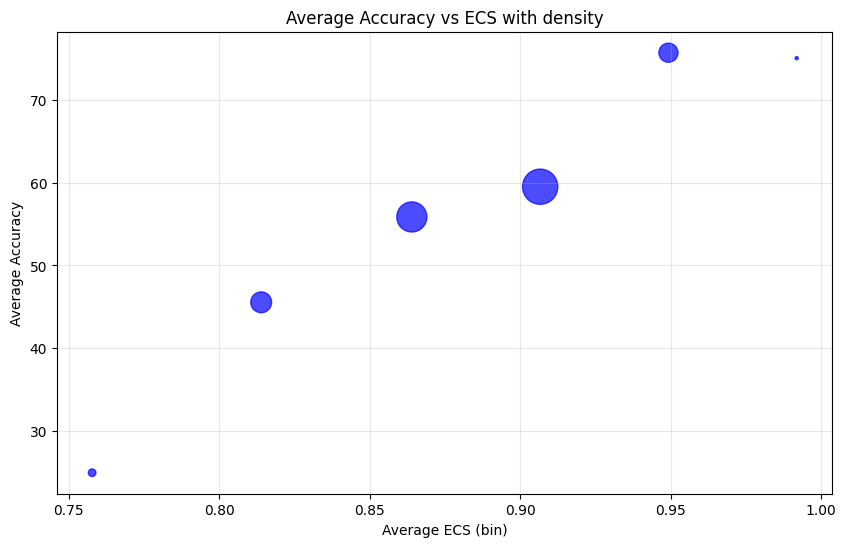

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load data
ecs_df = pd.read_csv("gsm8k/gsm8k_mistral7B_ECS.csv")[["id","ECS"]]
low_df = pd.read_csv("gsm8k/low_ecs_accuracy_mistral.csv")
high_df = pd.read_csv("gsm8k/high_ecs_accuracy_mistral.csv")

# Merge everything
df = pd.concat([low_df, high_df], ignore_index=True)
df = df.merge(ecs_df, on="id", how="left")

# Bin ECS scores
bins = np.arange(df['ECS'].min(), df['ECS'].max()+0.05, 0.05)
df['ecs_bin'] = pd.cut(df['ECS'], bins=bins)

# Compute average accuracy and count per bin
bin_stats = df.groupby('ecs_bin').agg(
    avg_ECS=('ECS','mean'),
    avg_accuracy=('accuracy','mean'),
    count=('id','count')
).reset_index()

# Scatter plot
plt.figure(figsize=(10,6))
plt.scatter(bin_stats['avg_ECS'], bin_stats['avg_accuracy'], 
            s=bin_stats['count']*5,  # scale size by number of examples
            alpha=0.7, color='blue')
plt.xlabel("Average ECS (bin)")
plt.ylabel("Average Accuracy")
plt.title("Average Accuracy vs ECS with density")
plt.grid(alpha=0.3)
plt.show()


/var/folders/vk/18ngtwrs58n0x_sklvrh_58h0000gn/T/ipykernel_20261/4265682309.py:34: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_density = df.groupby('ecs_bin')['id'].count()
/var/folders/vk/18ngtwrs58n0x_sklvrh_58h0000gn/T/ipykernel_20261/4265682309.py:35: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_mid = df.groupby('ecs_bin')['ECS'].mean()
/var/folders/vk/18ngtwrs58n0x_sklvrh_58h0000gn/T/ipykernel_20261/4265682309.py:113: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.leg

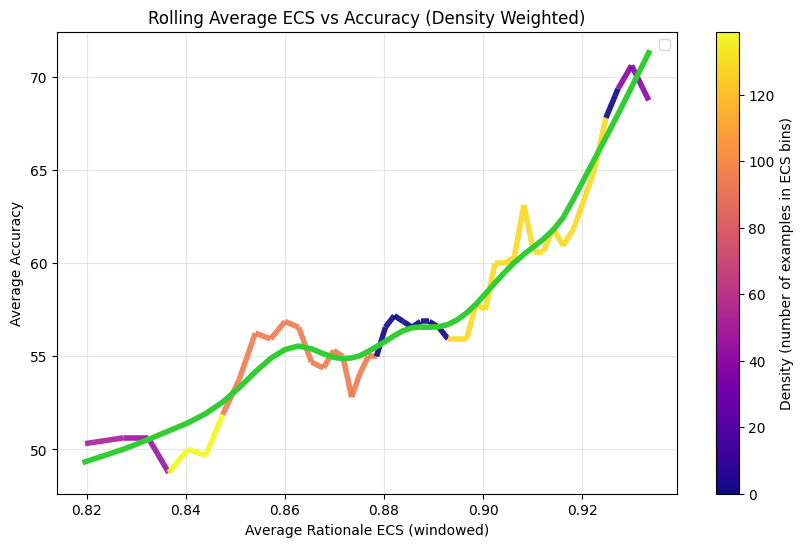

💾 Saved rolling window ECS vs accuracy with density info
✨ Smoothed trend added (LOWESS using high-density regions).


In [82]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.collections import LineCollection
from matplotlib.colors import Normalize
import matplotlib.cm as cm
from statsmodels.nonparametric.smoothers_lowess import lowess

# -----------------------------
# File paths
# -----------------------------
ecs_file = "gsm8k/gsm8k_mistral7B_ECS.csv"
low_accuracy_file = "gsm8k/low_ecs_accuracy_mistral.csv"
high_accuracy_file = "gsm8k/high_ecs_accuracy_mistral.csv"

# -----------------------------
# Load data
# -----------------------------
ecs_df = pd.read_csv(ecs_file)[["id","ECS"]]
low_df = pd.read_csv(low_accuracy_file)[["id","accuracy"]]
high_df = pd.read_csv(high_accuracy_file)[["id","accuracy"]]

df = pd.concat([low_df, high_df], ignore_index=True)
df = df.merge(ecs_df, on="id", how="left")
df = df.sort_values("ECS").reset_index(drop=True)

# -----------------------------
# Bin ECS to compute density
# -----------------------------
bin_width = 0.05
bins = np.arange(df['ECS'].min(), df['ECS'].max() + bin_width, bin_width)
df['ecs_bin'] = pd.cut(df['ECS'], bins=bins)

bin_density = df.groupby('ecs_bin')['id'].count()
bin_mid = df.groupby('ecs_bin')['ECS'].mean()

bin_stats = pd.DataFrame({
    'bin_mid': bin_mid,
    'density': bin_density
}).reset_index(drop=True)

# -----------------------------
# Rolling window parameters
# -----------------------------
window_size = 80
step_size = 5

avg_ecs_list = []
avg_acc_list = []
window_density = []

# -----------------------------
# Compute rolling averages and assign density
# -----------------------------
for start in range(0, len(df) - window_size + 1, step_size):
    window = df.iloc[start:start+window_size]
    avg_ecs_list.append(window['ECS'].mean())
    avg_acc_list.append(window['accuracy'].mean())
    
    ecs_min, ecs_max = window['ECS'].min(), window['ECS'].max()
    overlapping_bins = bin_stats[(bin_stats['bin_mid'] >= ecs_min) & (bin_stats['bin_mid'] <= ecs_max)]
    window_density.append(overlapping_bins['density'].sum())

# -----------------------------
# Prepare colored zigzag line
# -----------------------------
points = np.array([avg_ecs_list, avg_acc_list]).T.reshape(-1, 1, 2)
segments = np.concatenate([points[:-1], points[1:]], axis=1)

norm = Normalize(vmin=min(window_density), vmax=max(window_density))
colors = cm.plasma(norm(window_density[:-1]))

lc = LineCollection(segments, colors=colors, linewidth=4, alpha=0.9)

# -----------------------------
# Create plot
# -----------------------------
fig, ax = plt.subplots(figsize=(10,6))
ax.add_collection(lc)
ax.autoscale()
ax.set_xlabel("Average Rationale ECS (windowed)")
ax.set_ylabel("Average Accuracy")
ax.set_title("Rolling Average ECS vs Accuracy (Density Weighted)")
ax.grid(alpha=0.3)

# -----------------------------
# Colorbar
# -----------------------------
sm = cm.ScalarMappable(cmap=cm.plasma, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax)
cbar.set_label("Density (number of examples in ECS bins)")

# -----------------------------
# Smooth only high-density regions
# -----------------------------
# -----------------------------
# Smooth only high-density regions
# -----------------------------
density_threshold = np.percentile(window_density, 0)  # keep top 40% dense windows
mask = np.array(window_density) >= density_threshold

ecs_high = np.array(avg_ecs_list)[mask]
acc_high = np.array(avg_acc_list)[mask]

# LOWESS smoothing (more smooth)
smooth = lowess(acc_high, ecs_high, frac=0.30, return_sorted=True)  # increased frac
smooth_ecs = smooth[:,0]
smooth_acc = smooth[:,1]

# Plot smoothed trend backbone (green line)
ax.plot(smooth_ecs, smooth_acc, color="#32CD32", linewidth=4)
ax.legend()



plt.show()

print("💾 Saved rolling window ECS vs accuracy with density info")
print("✨ Smoothed trend added (LOWESS using high-density regions).")


/var/folders/vk/18ngtwrs58n0x_sklvrh_58h0000gn/T/ipykernel_17152/4013216438.py:34: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_density = df.groupby('ecs_bin')['id'].count()
/var/folders/vk/18ngtwrs58n0x_sklvrh_58h0000gn/T/ipykernel_17152/4013216438.py:35: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_mid = df.groupby('ecs_bin')['ECS'].mean()


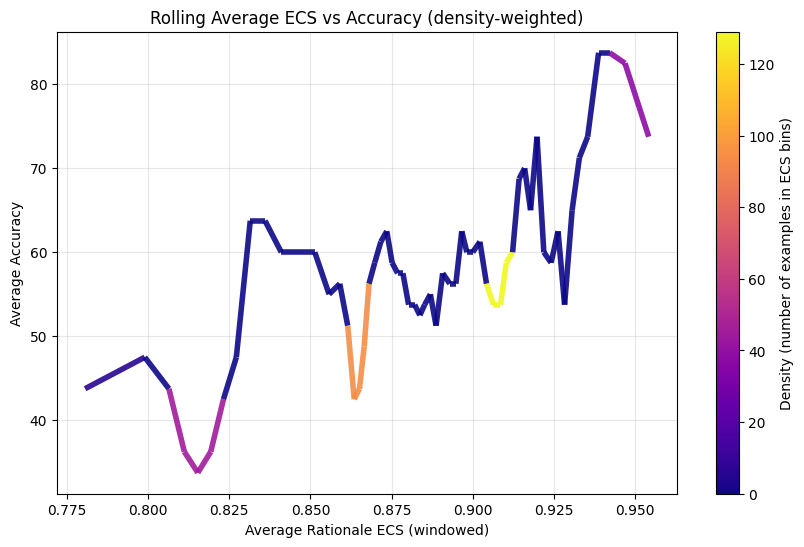

💾 Saved rolling window ECS vs accuracy with density info


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.collections import LineCollection
from matplotlib.colors import Normalize
import matplotlib.cm as cm

# -----------------------------
# File paths
# -----------------------------
ecs_file = "gsm8k/gsm8k_mistral7B_ECS.csv"
low_accuracy_file = "gsm8k/low_ecs_accuracy_mistral.csv"
high_accuracy_file = "gsm8k/high_ecs_accuracy_mistral.csv"


# -----------------------------
# Load data
# -----------------------------
ecs_df = pd.read_csv(ecs_file)[["id","ECS"]]
low_df = pd.read_csv(low_accuracy_file)[["id","accuracy"]]
high_df = pd.read_csv(high_accuracy_file)[["id","accuracy"]]

df = pd.concat([low_df, high_df], ignore_index=True)
df = df.merge(ecs_df, on="id", how="left")
df = df.sort_values("ECS").reset_index(drop=True)

# -----------------------------
# Bin ECS to compute density
# -----------------------------
bin_width = 0.05
bins = np.arange(df['ECS'].min(), df['ECS'].max() + bin_width, bin_width)
df['ecs_bin'] = pd.cut(df['ECS'], bins=bins)

bin_density = df.groupby('ecs_bin')['id'].count()
bin_mid = df.groupby('ecs_bin')['ECS'].mean()

bin_stats = pd.DataFrame({
    'bin_mid': bin_mid,
    'density': bin_density
}).reset_index(drop=True)

# -----------------------------
# Rolling window parameters
# -----------------------------
window_size = 20
step_size = 5

avg_ecs_list = []
avg_acc_list = []
window_density = []

# -----------------------------
# Compute rolling averages and assign density
# -----------------------------
for start in range(0, len(df) - window_size + 1, step_size):
    window = df.iloc[start:start+window_size]
    avg_ecs_list.append(window['ECS'].mean())
    avg_acc_list.append(window['accuracy'].mean())
    
    ecs_min, ecs_max = window['ECS'].min(), window['ECS'].max()
    overlapping_bins = bin_stats[(bin_stats['bin_mid'] >= ecs_min) & (bin_stats['bin_mid'] <= ecs_max)]
    window_density.append(overlapping_bins['density'].sum())

# -----------------------------
# Prepare colored line
# -----------------------------
points = np.array([avg_ecs_list, avg_acc_list]).T.reshape(-1, 1, 2)
segments = np.concatenate([points[:-1], points[1:]], axis=1)

norm = Normalize(vmin=min(window_density), vmax=max(window_density))
# Change colormap to 'plasma' or 'coolwarm' for better contrast
colors = cm.plasma(norm(window_density[:-1]))

lc = LineCollection(segments, colors=colors, linewidth=4, alpha=0.9)  # thicker line

# -----------------------------
# Plot
# -----------------------------
fig, ax = plt.subplots(figsize=(10,6))
ax.add_collection(lc)
ax.autoscale()
ax.set_xlabel("Average Rationale ECS (windowed)")
ax.set_ylabel("Average Accuracy")
ax.set_title("Rolling Average ECS vs Accuracy (density-weighted)")
ax.grid(alpha=0.3)

# Colorbar
sm = cm.ScalarMappable(cmap=cm.plasma, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax)
cbar.set_label("Density (number of examples in ECS bins)")

plt.show()

# -----------------------------
# Save results
# -----------------------------
rolling_df = pd.DataFrame({
    "avg_ECS": avg_ecs_list,
    "avg_accuracy": avg_acc_list,
    "density": window_density
})
rolling_df.to_csv("gsm8k/rolling_avg_ecs_accuracy_density_mistral.csv.csv", index=False)
print("💾 Saved rolling window ECS vs accuracy with density info")


**Gemini post analysis**

🗑️ Removed 0 examples based on remove_ids.
✅ 417 examples remaining after filtering.


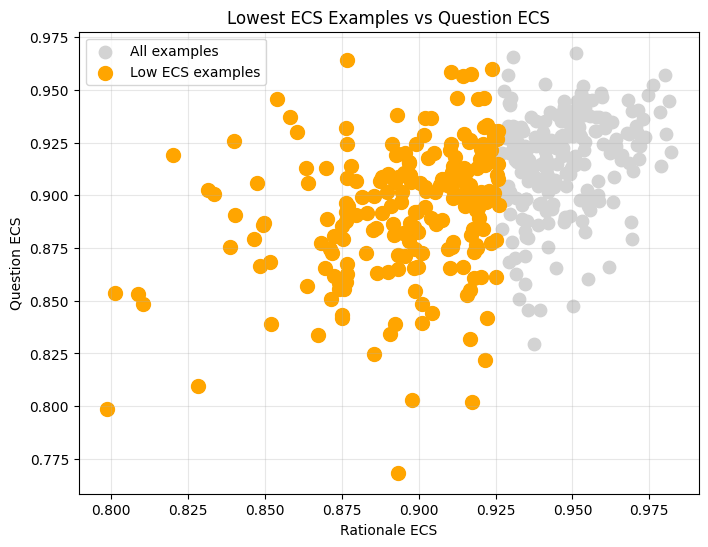

💾 Saved top 20 lowest ECS rationales ranked by ECS to gsm8k/low_ecs_rationales_gemini_gsm8k.csv


In [1043]:
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# Load LLaMA3 rationale ECS
# -----------------------------
rationale_df = pd.read_csv("gsm8k/gsm8k_gemini_ECS_scores.csv")

# Load question ECS
question_df = pd.read_csv("gsm8k/gsm8k_questions_ECS_scores.csv")

# -----------------------------
# Merge ECS scores
# -----------------------------
merged_df = rationale_df.merge(
    question_df[['id','Question_ECS']],
    on='id',
    how='left'
)

# -----------------------------
# Exclude specific IDs
# -----------------------------
remove_ids = [
    7, 47, 61, 66, 90, 107, 111, 123,132, 143, 146, 150, 159, 166, 172,177, 209, 212, 214,235,260, 263, 284, 287, 288, 297, 306, 309, 319, 320, 328, 334, 345, 362, 468, 471, 475, 487, #empty
    36,51,63,69,75,92,93,100,103,112,115,116,125,130,170,183,207,219,225,237,257,259,271,273,
    303,311,315,347,348,350,357,364,367,369,371,374,376,409,454,460,462,484,488,489,499
]

# Count before removing
num_before = len(merged_df)

# Apply filtering
merged_df = merged_df[~merged_df['id'].isin(remove_ids)]

# Count after removing
num_after = len(merged_df)
num_removed = num_before - num_after

print(f"🗑️ Removed {num_removed} examples based on remove_ids.")
print(f"✅ {num_after} examples remaining after filtering.")


# -----------------------------
# Step 1: Select the lowest 20 ECS examples
# -----------------------------
low_20_ecs = merged_df.sort_values('ECS', ascending=True).head(208).copy()##CHECK HERE -------------------------------------------------------------

# -----------------------------
# Step 2: Compute ECS difference (Rationale ECS - Question ECS) for reference
# -----------------------------
low_20_ecs['ECS_diff'] = low_20_ecs['ECS'] - low_20_ecs['Question_ECS']

# -----------------------------
# Step 3: Rank these 20 by ECS (lowest first)
# -----------------------------
low_20_ranked = low_20_ecs.sort_values('ECS', ascending=True)

#print("🔹 Top 20 lowest ECS examples ranked by ECS:")
#print(low_20_ranked[['id','ECS','Question_ECS','ECS_diff']])

# -----------------------------
# Scatter plot
# -----------------------------
plt.figure(figsize=(8,6))
plt.scatter(merged_df['ECS'], merged_df['Question_ECS'], color='lightgray', s=80, label='All examples')
plt.scatter(low_20_ranked['ECS'], low_20_ranked['Question_ECS'], color='orange', s=100, label='Low ECS examples')
plt.xlabel("Rationale ECS")
plt.ylabel("Question ECS")
plt.title("Lowest ECS Examples vs Question ECS")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# -----------------------------
# Step 4: Export the corresponding LLaMA3 rationales
# -----------------------------
llama_rationales_df = pd.read_csv("gsm8k/gsm8k_gemini_CoT_responses_correct.csv")
low_rationales = llama_rationales_df[llama_rationales_df['id'].isin(low_20_ranked['id'].tolist())]

# Merge correct answers
answers_df = pd.read_csv("gsm8k/gsm8k_500_rows_with_answers.csv")
low_rationales = low_rationales.merge(
    answers_df[['id','answer']],
    on='id',
    how='left'
).rename(columns={'answer':'correct_answer'})

# Merge ECS and ECS_diff for reference, then sort by ECS
low_rationales = low_rationales.merge(
    low_20_ranked[['id','ECS','ECS_diff']],
    on='id',
    how='left'
).sort_values('ECS', ascending=True)

# Optional: drop ECS_diff if you don't need it in the CSV
# low_rationales = low_rationales.drop(columns=['ECS_diff'])

# Save CSV
output_file = "gsm8k/low_ecs_rationales_gemini_gsm8k.csv"
low_rationales.to_csv(output_file, index=False)
print(f"💾 Saved top 20 lowest ECS rationales ranked by ECS to {output_file}")

🗑️ Removed 0 examples based on remove_ids.
✅ 417 examples remaining after filtering.
🔹 Top 20 high ECS examples ranked by ECS:


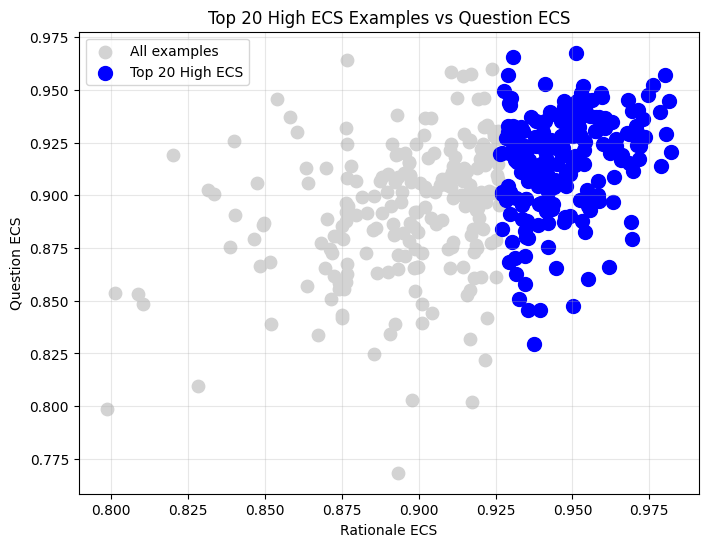

💾 Saved top 20 high ECS rationales ranked by ECS to gsm8k/high_ecs_rationales_gemini_gsm8k.csv


In [1042]:
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# Load LLaMA3 rationale ECS
rationale_df = pd.read_csv("gsm8k/gsm8k_gemini_ECS_scores.csv")

# Load question ECS
question_df = pd.read_csv("gsm8k/gsm8k_questions_ECS_scores.csv")

# -----------------------------
# Merge ECS scores
# -----------------------------
merged_df = rationale_df.merge(
    question_df[['id','Question_ECS']],
    on='id',
    how='left'
)

# -----------------------------
# Exclude specific IDs if needed
# -----------------------------
remove_ids = [
    7, 47, 61, 66, 90,103, 107, 111, 123, 132,143, 146, 150, 159, 166, 172,177, 209, 212, 214,235,260 ,263, 284, 287, 288, 297, 306, 309, 319, 320, 328, 334, 345, 362, 468, 471, 475, 487, #empty
    36,51,63,69,75,92,93,100,112,115,116,125,130,170,183,219,207,225,237,257,259,271,273,
    303,311,315,347,348,350,357,364,367,369,371,374,376,409,454,460,462,484,488,489,499
]
# Count before removing
num_before = len(merged_df)

# Apply filtering
merged_df = merged_df[~merged_df['id'].isin(remove_ids)]

# Count after removing
num_after = len(merged_df)
num_removed = num_before - num_after

print(f"🗑️ Removed {num_removed} examples based on remove_ids.")
print(f"✅ {num_after} examples remaining after filtering.")


# -----------------------------
# Step 1: Select top 20 examples by Rationale ECS
# -----------------------------
top_20_ecs = merged_df.sort_values('ECS', ascending=False).head(209).copy()#CHECK HERE ------------------------------------------------------------

# -----------------------------
# Step 2: Compute ECS difference (for reference only)
# -----------------------------
top_20_ecs['ECS_diff'] = top_20_ecs['ECS'] - top_20_ecs['Question_ECS']

# -----------------------------
# Step 3: Rank the top 20 by ECS (highest first)
# -----------------------------
top_20_ranked = top_20_ecs.sort_values('ECS', ascending=False)
print("🔹 Top 20 high ECS examples ranked by ECS:")
#print(top_20_ranked[['id','ECS','Question_ECS','ECS_diff']])

# -----------------------------
# Scatter plot
# -----------------------------
plt.figure(figsize=(8,6))
plt.scatter(merged_df['ECS'], merged_df['Question_ECS'], color='lightgray', s=80, label='All examples')
plt.scatter(top_20_ranked['ECS'], top_20_ranked['Question_ECS'], color='blue', s=100, label='Top 20 High ECS')
plt.xlabel("Rationale ECS")
plt.ylabel("Question ECS")
plt.title("Top 20 High ECS Examples vs Question ECS")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# -----------------------------
# Export the top 20 rationales for inspection
# -----------------------------
mistral_rationales_df = pd.read_csv("gsm8k/gsm8k_gemini_CoT_responses_correct.csv")
top_rationales = mistral_rationales_df[mistral_rationales_df['id'].isin(top_20_ranked['id'].tolist())]

# Merge ECS and ECS_diff for reference
top_rationales = top_rationales.merge(
    top_20_ranked[['id','ECS','ECS_diff']],
    on='id',
    how='left'
)

# Sort by ECS (highest first)
top_rationales = top_rationales.sort_values('ECS', ascending=False)

# Merge correct answers
answers_df = pd.read_csv("gsm8k/gsm8k_500_rows_with_answers.csv")
top_rationales = top_rationales.merge(
    answers_df[['id','answer']],
    on='id',
    how='left'
).rename(columns={'answer':'correct_answer'})

# Optional: drop ECS_diff if you don't need it in the CSV
# top_rationales = top_rationales.drop(columns=['ECS_diff'])

# Save CSV
output_file = "gsm8k/high_ecs_rationales_gemini_gsm8k.csv"
top_rationales.to_csv(output_file, index=False)
print(f"💾 Saved top 20 high ECS rationales ranked by ECS to {output_file}")




# ---------------------------------------------------------
# CHECK: Forbidden IDs in final high ECS output



In [1044]:
import pandas as pd
import re
from decimal import Decimal, InvalidOperation
import numpy as np


# =====================================================
# GSM8K GOLD ANSWER EXTRACTION
# =====================================================
def extract_gsm8k_answer(text):
    if not isinstance(text, str):
        return None
    m = re.search(r"####\s*(.*)", text)
    return m.group(1).strip() if m else text.strip()


# =====================================================
# GEMINI FINAL ANSWER EXTRACTION
# =====================================================
def extract_gemini_answer(text):
    if not isinstance(text, str):
        return None

    s = text.strip()

    patterns = [
        r"[Tt]he\s+final\s+answer\s+is\s+\\?\$?\\?boxed\{?([^\}\$]+)\}?",
        r"[Ff]inal\s+[Aa]nswer\s*[:=\-–—]?\s*\\?\$?\\?boxed\{?([^\}\$]+)\}?",
        r"[Tt]he\s+final\s+answer\s+is\s+([^\n\r]*)",
        r"[Ff]inal\s+[Aa]nswer\s*[:=\-–—]?\s*([^\n\r]*)",
    ]

    candidate = None
    for pat in patterns:
        m = re.search(pat, s)
        if m:
            candidate = m.group(1)
            break

    # Also detect \boxed{}
    if candidate is None:
        m = re.search(r"\\boxed\{([^}]*)\}", s)
        if m:
            candidate = m.group(1)

    if candidate is None:
        return None

    # Cleanup
    candidate = candidate.strip()
    candidate = re.sub(r"\\text\{[^}]*\}", "", candidate)
    candidate = candidate.replace("\\(", "").replace("\\)", "")
    candidate = candidate.replace("$", "").replace(",", "")
    candidate = candidate.replace("⁄", "/")
    candidate = candidate.replace("≈", " ").replace("∼", " ").strip()

    # Fraction handling
    frac = re.search(r"\\frac\{\s*([\-+]?\d+)\s*\}\{\s*([\-+]?\d+)\s*\}", candidate)
    if frac:
        return f"{frac.group(1)}/{frac.group(2)}"

    mixed = re.search(r"^\s*([\-+]?\d+)\s+(\d+)\s*/\s*(\d+)\s*$", candidate)
    if mixed:
        return f"{mixed.group(1)} {mixed.group(2)}/{mixed.group(3)}"

    simple_frac = re.search(r"^\s*\(?\s*([\-+]?\d+)\s*/\s*([\-+]?\d+)\s*\)?\s*$", candidate)
    if simple_frac:
        return f"{simple_frac.group(1)}/{simple_frac.group(2)}"

    cleaned = re.sub(r"[^0-9\.\-+/ ]", " ", candidate).strip()
    any_frac = re.search(r"([\-+]?\d+\s+\d+/\d+)|([\-+]?\d+/\d+)", cleaned)
    if any_frac:
        return any_frac.group(0).strip()

    num_match = re.search(r"[-+]?\d*\.?\d+", cleaned)
    if num_match:
        return num_match.group(0)

    return None


# =====================================================
# NORMALIZATION & COMPARISON
# =====================================================
def to_decimal(s):
    if s is None:
        return None
    t = str(s).strip().lower()
    if t == "":
        return None

    t = t.replace(",", "").replace("⁄", "/").replace("≈", " ").replace("∼", " ").strip()

    m = re.fullmatch(r"\s*([\-+]?\d+)\s+(\d+)\s*/\s*(\d+)\s*", t)
    if m:
        whole, num, den = Decimal(m.group(1)), Decimal(m.group(2)), Decimal(m.group(3))
        if den == 0:
            return None
        frac = num / den
        return whole + frac if whole >= 0 else whole - frac

    m = re.fullmatch(r"\s*([\-+]?\d+)\s*/\s*([\-+]?\d+)\s*", t)
    if m:
        num, den = Decimal(m.group(1)), Decimal(m.group(2))
        if den == 0:
            return None
        return num / den

    m = re.fullmatch(r"\(\s*([\-+]?\d+)\s*/\s*([\-+]?\d+)\s*\)", t)
    if m:
        num, den = Decimal(m.group(1)), Decimal(m.group(2))
        if den == 0:
            return None
        return num / den

    try:
        return Decimal(t)
    except InvalidOperation:
        return None


def answers_equal(a, b, precision=2, tol=Decimal("1e-9")):
    da, db = to_decimal(a), to_decimal(b)

    if da is not None and db is not None:
        da_r = da.quantize(Decimal("1." + "0" * precision))
        db_r = db.quantize(Decimal("1." + "0" * precision))
        return (da_r - db_r).copy_abs() <= tol

    return str(a).strip().lower() == str(b).strip().lower()


# =====================================================
# CORE ACCURACY COMPUTATION
# =====================================================
def compute_accuracy(file_path):

    df = pd.read_csv(file_path)

    # Extract final answers
    df["final_original"]   = df["cot_original"].apply(extract_gemini_answer)
    df["final_lexical"]    = df["cot_lexical"].apply(extract_gemini_answer)
    df["final_syntactic"]  = df["cot_syntactic"].apply(extract_gemini_answer)
    df["final_contextual"] = df["cot_contextual"].apply(extract_gemini_answer)

    # Load GSM8K gold answers
    answers_df = pd.read_csv("gsm8k/gsm8k_500_rows_with_answers.csv")
    answers_df["correct_answer"] = answers_df["answer"].apply(extract_gsm8k_answer)

    # Normalize IDs
    df["id"] = df["id"].astype(str).str.strip()
    answers_df["id"] = answers_df["id"].astype(str).str.strip()

    # Merge
    df = df.merge(answers_df[["id","correct_answer"]], on="id", how="left")

    # FIX duplicate columns
    if "correct_answer_x" in df.columns:
        df = df.drop(columns=["correct_answer_x"])
    if "correct_answer_y" in df.columns:
        df = df.rename(columns={"correct_answer_y": "correct_answer"})

    # Compute correctness
    for col in ["final_original","final_lexical","final_syntactic","final_contextual"]:
        df.loc[:, col + "_correct"] = df.apply(
            lambda r: int(answers_equal(r[col], r["correct_answer"])), axis=1
        )

    df.loc[:, "accuracy"] = df[
        ["final_original_correct","final_lexical_correct",
         "final_syntactic_correct","final_contextual_correct"]
    ].mean(axis=1)

    # Per-column accuracy
    column_accuracy = {
        col: df[col + "_correct"].mean()
        for col in ["final_original","final_lexical","final_syntactic","final_contextual"]
    }

    overall_accuracy = df["accuracy"].mean()

    # Make a true COPY to avoid warnings
    out_df = df[[
        "id",
        "correct_answer",
        "final_original",
        "final_lexical",
        "final_syntactic",
        "final_contextual",
        "accuracy"
    ]].copy()

    # Safe assignment
    out_df.loc[:, "accuracy"] = (out_df["accuracy"] * 100).round(2)

    return out_df, column_accuracy, overall_accuracy


# =====================================================
# RUN LOW ECS
# =====================================================
low_df, low_cols, low_overall = compute_accuracy("gsm8k/low_ecs_rationales_gemini_gsm8k.csv")

print("🔹 Low ECS examples:")
for k,v in low_cols.items():
    print(f"{k}: {v*100:.2f}%")
print(f"Overall average accuracy: {low_overall*100:.2f}%\n")

low_df.to_csv("gsm8k/low_ecs_accuracy_gemini.csv", index=False)


# =====================================================
# RUN HIGH ECS
# =====================================================
high_df, high_cols, high_overall = compute_accuracy("gsm8k/high_ecs_rationales_gemini_gsm8k.csv")

print("🔹 High ECS examples:")
for k,v in high_cols.items():
    print(f"{k}: {v*100:.2f}%")
print(f"Overall average accuracy: {high_overall*100:.2f}%\n")

high_df.to_csv("gsm8k/high_ecs_accuracy_gemini.csv", index=False)

print("🎉 Gemini accuracy summaries saved successfully!")



🔹 Low ECS examples:
final_original: 100.00%
final_lexical: 100.00%
final_syntactic: 100.00%
final_contextual: 100.00%
Overall average accuracy: 100.00%

🔹 High ECS examples:
final_original: 99.52%
final_lexical: 100.00%
final_syntactic: 100.00%
final_contextual: 100.00%
Overall average accuracy: 99.88%

🎉 Gemini accuracy summaries saved successfully!


/var/folders/vk/18ngtwrs58n0x_sklvrh_58h0000gn/T/ipykernel_42170/3856163240.py:34: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_density = df.groupby('ecs_bin')['id'].count()
/var/folders/vk/18ngtwrs58n0x_sklvrh_58h0000gn/T/ipykernel_42170/3856163240.py:35: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_mid = df.groupby('ecs_bin')['ECS'].mean()


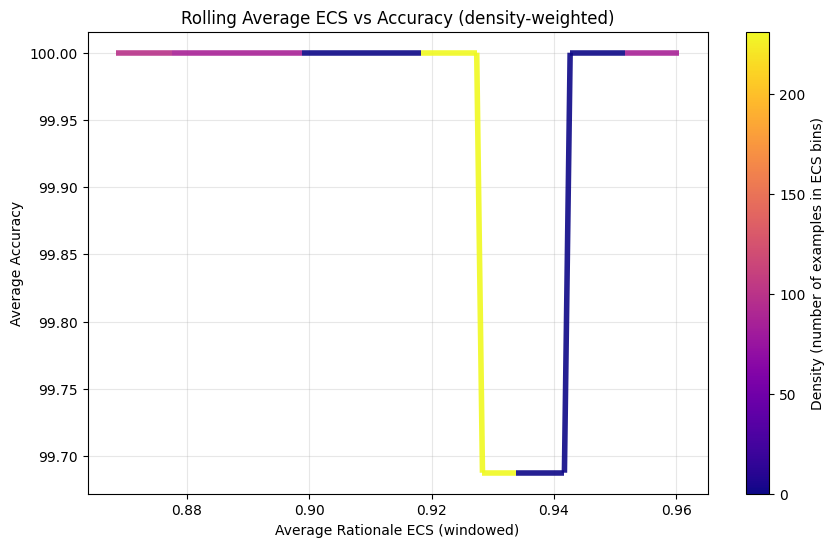

In [1047]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.collections import LineCollection
from matplotlib.colors import Normalize
import matplotlib.cm as cm

# -----------------------------
# File paths
# -----------------------------
;
# -----------------------------
# Load data
# -----------------------------
ecs_df = pd.read_csv(ecs_file)[["id","ECS"]]
low_df = pd.read_csv(low_accuracy_file)[["id","accuracy"]]
high_df = pd.read_csv(high_accuracy_file)[["id","accuracy"]]

df = pd.concat([low_df, high_df], ignore_index=True)
df = df.merge(ecs_df, on="id", how="left")
df = df.sort_values("ECS").reset_index(drop=True)

# -----------------------------
# Bin ECS to compute density
# -----------------------------
bin_width = 0.05
bins = np.arange(df['ECS'].min(), df['ECS'].max() + bin_width, bin_width)
df['ecs_bin'] = pd.cut(df['ECS'], bins=bins)

bin_density = df.groupby('ecs_bin')['id'].count()
bin_mid = df.groupby('ecs_bin')['ECS'].mean()

bin_stats = pd.DataFrame({
    'bin_mid': bin_mid,
    'density': bin_density
}).reset_index(drop=True)

# -----------------------------
# Rolling window parameters
# -----------------------------
window_size = 80
step_size = 5

avg_ecs_list = []
avg_acc_list = []
window_density = []

# -----------------------------
# Compute rolling averages and assign density
# -----------------------------
for start in range(0, len(df) - window_size + 1, step_size):
    window = df.iloc[start:start+window_size]
    avg_ecs_list.append(window['ECS'].mean())
    avg_acc_list.append(window['accuracy'].mean())
    
    ecs_min, ecs_max = window['ECS'].min(), window['ECS'].max()
    overlapping_bins = bin_stats[(bin_stats['bin_mid'] >= ecs_min) & (bin_stats['bin_mid'] <= ecs_max)]
    window_density.append(overlapping_bins['density'].sum())

# -----------------------------
# Prepare colored line
# -----------------------------
points = np.array([avg_ecs_list, avg_acc_list]).T.reshape(-1, 1, 2)
segments = np.concatenate([points[:-1], points[1:]], axis=1)

norm = Normalize(vmin=min(window_density), vmax=max(window_density))
# Change colormap to 'plasma' or 'coolwarm' for better contrast
colors = cm.plasma(norm(window_density[:-1]))

lc = LineCollection(segments, colors=colors, linewidth=4, alpha=0.9)  # thicker line

# -----------------------------
# Plot
# -----------------------------
fig, ax = plt.subplots(figsize=(10,6))
ax.add_collection(lc)
ax.autoscale()
ax.set_xlabel("Average Rationale ECS (windowed)")
ax.set_ylabel("Average Accuracy")
ax.set_title("Rolling Average ECS vs Accuracy (density-weighted)")
ax.grid(alpha=0.3)

# Colorbar
sm = cm.ScalarMappable(cmap=cm.plasma, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax)
cbar.set_label("Density (number of examples in ECS bins)")

plt.show()

# -----------------------------
# Save results
# -----------------------------
rolling_df = pd.DataFrame({
    "avg_ECS": avg_ecs_list,
    "avg_accuracy": avg_acc_list,
    "density": window_density
})



In [ ]:
remove_ids_2 = [2, 27, 85, 111, 123, 128, 135, 143, 145, 146, 149, 190, 196, 204, 207, 212, 214, 215, 221, 224, 229, 238, 263, 277, 282, 285, 286, 289, 314, 317, 323, 326, 332, 336, 339, 340, 342, 352, 355, 362, 372, 376, 380, 385, 398, 416, 424, 425, 431, 434, 439, 442, 445, 468, 471, 487, 492]


In [1048]:
import pandas as pd

# =========================
# Load accuracy summaries
# =========================
low_df = pd.read_csv("gsm8k/low_ecs_accuracy_summary.csv")
high_df = pd.read_csv("gsm8k/high_ecs_accuracy_summary.csv")

# =========================
# Merge (append) the two files
# =========================
combined_df = pd.concat([low_df, high_df], ignore_index=True)

# =========================
# Compute average accuracy across all rows
# Column name: "average_accuracy"
# =========================
avg_llama_accuracy = combined_df["average_accuracy"].mean()

print(f"🔹 Average LLaMA Accuracy (across low + high ECS sets): {avg_llama_accuracy:.4f}")

# =========================
# Load ECS scores
# =========================
ecs_df = pd.read_csv("gsm8k/gsm8k_llama3_ECS_scores.csv")  # contains column: ECS

# =========================
# Compute average ECS score
# =========================
avg_llama_ecs = ecs_df["ECS"].mean()

print(f"🔹 Average LLaMA ECS Score: {avg_llama_ecs:.4f}")


🔹 Average LLaMA Accuracy (across low + high ECS sets): 0.8118
🔹 Average LLaMA ECS Score: 0.8880


In [1049]:
import pandas as pd

# =========================
# Load Mistral Accuracy Files
# =========================
low_df = pd.read_csv("gsm8k/low_ecs_accuracy_mistral.csv")
high_df = pd.read_csv("gsm8k/high_ecs_accuracy_mistral.csv")

# =========================
# Merge the two files
# =========================
combined_df = pd.concat([low_df, high_df], ignore_index=True)

# =========================
# Compute average accuracy across all rows
# Column name: "accuracy" (percentage)
# =========================
avg_mistral_accuracy = combined_df["accuracy"].mean()

print(f"🔹 Average Mistral Accuracy (across low + high ECS sets): {avg_mistral_accuracy:.4f} %")

# =========================
# Load ECS scores
# =========================
ecs_df = pd.read_csv("gsm8k/gsm8k_mistral7B_ECS.csv")  # contains column: ECS

# =========================
# Compute average ECS value
# =========================
avg_mistral_ecs = ecs_df["ECS"].mean()

print(f"🔹 Average Mistral ECS Score: {avg_mistral_ecs:.4f}")


🔹 Average Mistral Accuracy (across low + high ECS sets): 57.7229 %
🔹 Average Mistral ECS Score: 0.8824


In [1050]:
import pandas as pd

# =========================
# Load Gemini Accuracy Files
# =========================
low_df = pd.read_csv("gsm8k/low_ecs_accuracy_gemini.csv")
high_df = pd.read_csv("gsm8k/high_ecs_accuracy_gemini.csv")

# =========================
# Merge low + high ECS accuracy data
# =========================
combined_df = pd.concat([low_df, high_df], ignore_index=True)

# =========================
# Compute average Gemini accuracy across all rows
# Column name: "accuracy" (percentage already)
# =========================
avg_gemini_accuracy = combined_df["accuracy"].mean()

print(f"🔹 Average Gemini Accuracy (across low + high ECS sets): {avg_gemini_accuracy:.4f} %")

# =========================
# Load Gemini ECS scores
# =========================
ecs_df = pd.read_csv("gsm8k/gsm8k_gemini_ECS_scores.csv")  # contains column ECS

# =========================
# Compute average Gemini ECS score
# =========================
avg_gemini_ecs = ecs_df["ECS"].mean()

print(f"🔹 Average Gemini ECS Score: {avg_gemini_ecs:.4f}")



🔹 Average Gemini Accuracy (across low + high ECS sets): 99.9400 %
🔹 Average Gemini ECS Score: 0.9208



🔹 Pearson correlation between ECS and Accuracy = 0.8994
   p-value = 2.8808e-01



/var/folders/vk/18ngtwrs58n0x_sklvrh_58h0000gn/T/ipykernel_20261/469487609.py:59: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


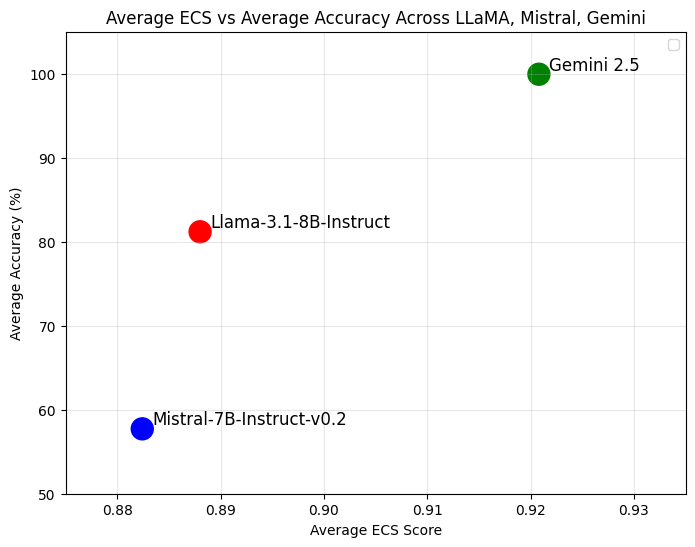

In [84]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import pearsonr

# ============================================================
# LOAD ALL MODEL DATA & COMPUTE AVERAGES
# ============================================================

# ----- LLaMA -----
llama_low = pd.read_csv("gsm8k/low_ecs_accuracy_summary.csv")
llama_high = pd.read_csv("gsm8k/high_ecs_accuracy_summary.csv")
llama_combined = pd.concat([llama_low, llama_high], ignore_index=True)
avg_llama_accuracy = llama_combined["average_accuracy"].mean() * 100   # FIXED
avg_llama_ecs = pd.read_csv("gsm8k/gsm8k_llama3_ECS_scores.csv")["ECS"].mean()

# ----- Mistral -----
mistral_low = pd.read_csv("gsm8k/low_ecs_accuracy_mistral.csv")
mistral_high = pd.read_csv("gsm8k/high_ecs_accuracy_mistral.csv")
mistral_combined = pd.concat([mistral_low, mistral_high], ignore_index=True)
avg_mistral_accuracy = mistral_combined["accuracy"].mean()  # already %
avg_mistral_ecs = pd.read_csv("gsm8k/gsm8k_mistral7B_ECS.csv")["ECS"].mean()

# ----- Gemini -----
gemini_low = pd.read_csv("gsm8k/low_ecs_accuracy_gemini.csv")
gemini_high = pd.read_csv("gsm8k/high_ecs_accuracy_gemini.csv")
gemini_combined = pd.concat([gemini_low, gemini_high], ignore_index=True)
avg_gemini_accuracy = gemini_combined["accuracy"].mean()  # already %
avg_gemini_ecs = pd.read_csv("gsm8k/gsm8k_gemini_ECS_scores.csv")["ECS"].mean()

# ============================================================
# PREPARE DATA FOR PLOTTING
# ============================================================

models = ["Llama-3.1-8B-Instruct", "Mistral-7B-Instruct-v0.2", "Gemini 2.5"]
ecs_scores = [avg_llama_ecs, avg_mistral_ecs, avg_gemini_ecs]
accuracies = [avg_llama_accuracy, avg_mistral_accuracy, avg_gemini_accuracy]

# Pearson correlation
corr, p_value = pearsonr(ecs_scores, accuracies)

print(f"\n🔹 Pearson correlation between ECS and Accuracy = {corr:.4f}")
print(f"   p-value = {p_value:.4e}\n")

# ============================================================
# PLOT
# ============================================================
plt.figure(figsize=(8,6))

plt.scatter(ecs_scores, accuracies, s=250, color=["red", "blue", "green"])

for i, model in enumerate(models):
    plt.text(ecs_scores[i] + 0.001, accuracies[i] + 0.5, model, fontsize=12)

plt.xlabel("Average ECS Score")
plt.ylabel("Average Accuracy (%)")
plt.title("Average ECS vs Average Accuracy Across LLaMA, Mistral, Gemini")
plt.grid(alpha=0.3)
plt.legend()

plt.xlim(0.875, 0.935)
plt.ylim(50, 105)

plt.show()


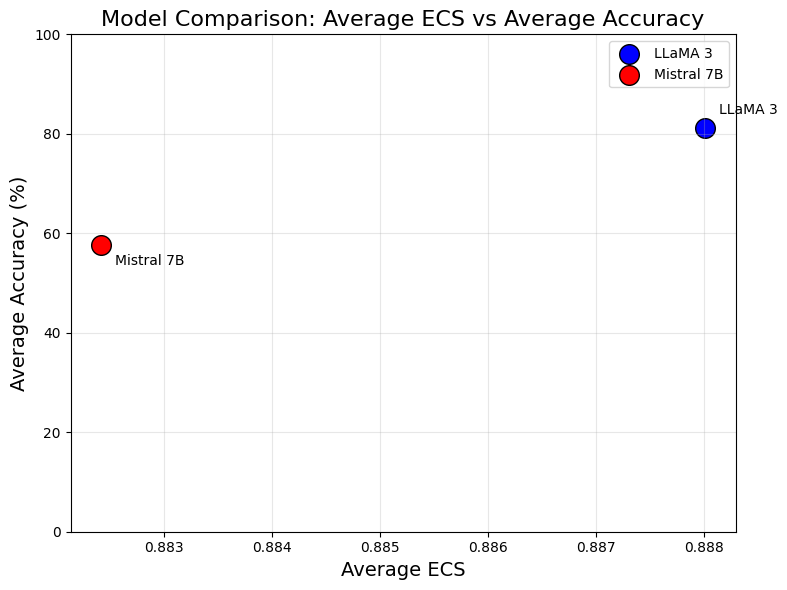

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# LOAD DATA
# ============================================================

# ----- LLaMA -----
llama_low = pd.read_csv("gsm8k/low_ecs_accuracy_summary.csv")
llama_high = pd.read_csv("gsm8k/high_ecs_accuracy_summary.csv")
llama_combined = pd.concat([llama_low, llama_high], ignore_index=True)

avg_llama_accuracy = llama_combined["average_accuracy"].mean() * 100  # convert to %
avg_llama_ecs = pd.read_csv("gsm8k/gsm8k_llama3_ECS_scores.csv")["ECS"].mean()

# ----- Mistral -----
mistral_low = pd.read_csv("gsm8k/low_ecs_accuracy_mistral.csv")
mistral_high = pd.read_csv("gsm8k/high_ecs_accuracy_mistral.csv")
mistral_combined = pd.concat([mistral_low, mistral_high], ignore_index=True)

avg_mistral_accuracy = mistral_combined["accuracy"].mean()  # already %
avg_mistral_ecs = pd.read_csv("gsm8k/gsm8k_mistral7B_ECS.csv")["ECS"].mean()

# ============================================================
# CREATE COMPARISON PLOT
# ============================================================

plt.figure(figsize=(8,6))

# Plot LLaMA
plt.scatter(avg_llama_ecs, avg_llama_accuracy, 
            color="blue", s=200, label="LLaMA 3", edgecolor="black")

# Plot Mistral
plt.scatter(avg_mistral_ecs, avg_mistral_accuracy, 
            color="red", s=200, label="Mistral 7B", edgecolor="black")

# Axis settings: start from 0 and increment by 20%
plt.ylim(0, 100)
plt.yticks(range(0, 101, 20))

# Labels
plt.xlabel("Average ECS", fontsize=14)
plt.ylabel("Average Accuracy (%)", fontsize=14)
plt.title("Model Comparison: Average ECS vs Average Accuracy", fontsize=16)

# Annotations
plt.annotate("LLaMA 3", (avg_llama_ecs, avg_llama_accuracy),
             textcoords="offset points", xytext=(10,10))
plt.annotate("Mistral 7B", (avg_mistral_ecs, avg_mistral_accuracy),
             textcoords="offset points", xytext=(10,-15))

plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


**Mistral Plausibility on GSM8K**

In [3]:
import os
import pandas as pd
from vertexai.generative_models import GenerativeModel
import vertexai
import time
import csv
from tqdm import tqdm
import re

# ---------------------------
# 1. SETUP & AUTH
# ---------------------------
SERVICE_ACCOUNT_PATH = r"llm-reasoning-475315-b0391b898b58.json"

# Check if file exists to prevent silent failures
if not os.path.exists(SERVICE_ACCOUNT_PATH):
    raise FileNotFoundError(f"❌ JSON file not found: {SERVICE_ACCOUNT_PATH}")

os.environ["GOOGLE_APPLICATION_CREDENTIALS"] = SERVICE_ACCOUNT_PATH

vertexai.init(project="llm-reasoning-475315", location="us-central1")
model = GenerativeModel("gemini-2.5-flash")
print("✅ Gemini model initialized.")

# ---------------------------
# 2. DEFINE EXCLUSION LIST
# ---------------------------
remove_ids = [
    2,7,21, 22,24,27,37, 40, 42,44, 47,52, 54, 57,58,66,71,76,85,105, 109, 111, 117, 120,121, 123,128,131, 133,135, 140,143, 144,145,146, 147,149,150,159,
    161,162,164,166, 176, 177, 178, 180, 181, 186,196, 197,207,204, 209, 211,212, 214,215, 220, 221,224, 227,229,
    230, 232, 238, 239, 242, 249, 250,258,261, 263,274, 277, 281, 282, 283, 284,285,286,287,289, 298,
    306, 309, 310, 312, 314,317, 319,321,323,326,332,334,336,338,339,340,342, 351,352, 353,354,355,255,361,362,365, 370,372, 376, 377, 380, 381,384,385,386,386,387,
    391,398 ,409,410,414, 415,416,420, 422,424,425,431,434,439,442,445, 448, 455, 459, 461,468, 469,471,472,487 ,492, 
    36, 51, 75, 63, 69, 92, 93, 100, 112, 115, 116, 125, 130, 170, 183,190,
    219, 225, 237, 257, 271,279, 303, 311, 315, 347, 348, 350, 357, 367, 369,
    371, 374, 429,454, 460, 462, 488, 489, 499
]
remove_ids = set(remove_ids)

# ---------------------------
# 3. HELPER: EXTRACT GOLD ANSWER
# ---------------------------
def extract_clean_answer(text):
    if pd.isna(text):
        return ""
    text = str(text)
    if "####" in text:
        return text.split("####")[-1].strip()
    return text.strip()

# ---------------------------
# 4. LOAD & MERGE DATA
# ---------------------------
# NOTE: Ensure these paths are exactly correct relative to where you run the script
try:
    df_questions = pd.read_csv("gsm8k/gsm8k_perturbed_full.csv")
    df_rationales = pd.read_csv("gsm8k/gsm8k_mistral7B_Cot_responses_merged.csv")
    df_answers = pd.read_csv("gsm8k/gsm8k_500_rows_with_answers.csv")
except FileNotFoundError as e:
    print(f"❌ Error loading CSVs: {e}")
    exit()

# Extract the clean answer
df_answers["clean_gold_answer"] = df_answers["answer"].apply(extract_clean_answer)

# Merge
merged = pd.merge(df_questions, df_rationales, on="id", how="inner")
merged = pd.merge(merged, df_answers[["id", "clean_gold_answer"]], on="id", how="inner")

print(f"📌 Merged dataset size BEFORE filtering: {len(merged)}")

# Filter
merged = merged[~merged["id"].isin(remove_ids)]
print(f"📌 Final dataset size AFTER filtering: {len(merged)}")

if len(merged) == 0:
    print("❌ ERROR: The merged dataset is empty! Check your IDs and CSV files.")
    exit()

# ---------------------------
# 5. PROMPT & SCORING
# ---------------------------
JUDGE_PROMPT = """
You are an expert evaluator of Mathematical Reasoning.

Your task is to judge the **plausibility and correctness of the MODEL RATIONALE** given the QUESTION and the GOLD ANSWER.

### INPUT DATA:
Question: {question}
Gold Answer: {gold_answer}
Model Rationale: {rationale}

### CRITERIA:
A plausible rationale must:
1. Interpret the question correctly.
2. Perform logical reasoning steps.
3. Perform correct arithmetic calculations.
4. Reach a final answer that matches the Gold Answer (or is mathematically equivalent).

### SCORING RUBRIC (1–5):
5 = Excellent (Correct logic, correct math, correct answer).
4 = Good (Correct logic and answer, but minor phrasing issues or implicit steps).
3 = Weak (Method is mostly correct, but contains a minor arithmetic error leading to a slightly wrong answer).
2 = Flawed (Major logical gap or wrong formula, even if the answer is accidentally close).
1 = Incorrect (Completely wrong logic, hallucinations, or correct answer derived from wrong numbers).

### OUTPUT:
Output ONLY the integer score (1–5).
"""

def score_math_rationale(question, gold_answer, rationale):
    if pd.isna(rationale) or str(rationale).strip() == "":
        return 0 
        
    prompt = JUDGE_PROMPT.format(
        question=question,
        gold_answer=gold_answer,
        rationale=rationale
    )

    try:
        resp = model.generate_content(prompt)
        text = resp.text.strip()
        match = re.search(r"\b([1-5])\b", text)
        if match:
            return int(match.group(1))
        return None
    except Exception as e:
        # print(f"API Error: {e}") # Optional: Uncomment to see specific API errors
        return None

# ---------------------------
# 6. EXECUTION LOOP
# ---------------------------
output_path = "gsm8k/gsm8k_gemini_plausibility_scores.csv"

# Ensure the directory exists
output_dir = os.path.dirname(output_path)
if output_dir and not os.path.exists(output_dir):
    os.makedirs(output_dir)

write_header = not os.path.exists(output_path)

print(f"🚀 Starting to score {len(merged)} rows. Outputting to: {output_path}")

# Open the file in 'append' mode
with open(output_path, "a", newline="", encoding="utf-8") as f:
    writer = csv.writer(f)

    if write_header:
        writer.writerow(["id", "plaus_original", "plaus_lexical", "plaus_syntactic", "plaus_contextual"])
        f.flush() # Flush header immediately
        print("📝 Created new output file with header.")

    # Use tqdm to show progress bar
    for idx, row in tqdm(merged.iterrows(), total=len(merged), desc="Scoring"):
        ex_id = row["id"]
        gold_ans = row["clean_gold_answer"]

        # 1. Original
        s_orig = score_math_rationale(row["original"], gold_ans, row["cot_original"])
        
        # 2. Lexical
        s_lex = score_math_rationale(row["lexical"], gold_ans, row["cot_lexical"])
        
        # 3. Syntactic
        s_syn = score_math_rationale(row["syntactic"], gold_ans, row["cot_syntactic"])
        
        # 4. Contextual 
        s_ctx = score_math_rationale(row["contextual"], gold_ans, row["cot_contextual"])

        # Write to CSV
        writer.writerow([ex_id, s_orig, s_lex, s_syn, s_ctx])
        
        # --- CRITICAL FIX ---
        f.flush() 
        os.fsync(f.fileno()) 
        # This forces the OS to save the line to the physical disk immediately
        # --------------------

        # Small sleep to prevent hitting rate limits too hard
        time.sleep(0.2)

print("🎉 DONE! All scores saved.")

/Users/mariosellinidis/Desktop/computer science/Diploma Thesis/thesis-ecs/venv/lib/python3.12/site-packages/vertexai/generative_models/_generative_models.py:433: UserWarning: This feature is deprecated as of June 24, 2025 and will be removed on June 24, 2026. For details, see https://cloud.google.com/vertex-ai/generative-ai/docs/deprecations/genai-vertexai-sdk.
  warning_logs.show_deprecation_warning()


✅ Gemini model initialized.
📌 Merged dataset size BEFORE filtering: 500
📌 Final dataset size AFTER filtering: 314
🚀 Starting to score 314 rows. Outputting to: gsm8k/gsm8k_gemini_plausibility_scores.csv
📝 Created new output file with header.


Scoring: 100%|██████████████████████████████| 314/314 [1:54:12<00:00, 21.82s/it]

🎉 DONE! All scores saved.


**calculate pmean**

In [4]:
import pandas as pd
import os

# ---------------------------
# 1. SETUP PATHS
# ---------------------------
input_path = "gsm8k/gsm8k_mistral_plausibility_scores.csv"
output_path = "gsm8k/gsm8k_mistral_plausibility_with_pmean.csv"

# Check if input file exists
if not os.path.exists(input_path):
    raise FileNotFoundError(f"❌ Input file not found: {input_path}")

# ---------------------------
# 2. LOAD DATA
# ---------------------------
df = pd.read_csv(input_path)
print(f"✅ Loaded {len(df)} rows from {input_path}")

# ---------------------------
# 3. CALCULATE P_MEAN
# ---------------------------
# Define the columns to average
score_cols = ["plaus_original", "plaus_lexical", "plaus_syntactic", "plaus_contextual"]

# Create 'pmean' column
# axis=1 means calculate across columns (row-by-row)
# numeric_only=True ensures we don't crash if there's weird data, though your data should be clean integers
df["pmean"] = df[score_cols].mean(axis=1)

# Optional: Round to 2 decimal places for cleaner reading
df["pmean"] = df["pmean"].round(2)

# ---------------------------
# 4. SAVE OUTPUT
# ---------------------------
df.to_csv(output_path, index=False)

print("------------------------------------------------")
print("SAMPLE PREVIEW:")
print(df[["id", "pmean"] + score_cols].head())
print("------------------------------------------------")
print(f"🎉 Success! New file saved with P_mean column to: {output_path}")

✅ Loaded 314 rows from gsm8k/gsm8k_mistral_plausibility_scores.csv
------------------------------------------------
SAMPLE PREVIEW:
   id  pmean  plaus_original  plaus_lexical  plaus_syntactic  plaus_contextual
0   1    4.0               5              1                5                 5
1   3    5.0               5              5                5                 5
2   4    4.0               5              5                1                 5
3   5    4.0               5              1                5                 5
4   6    3.5               3              5                1                 5
------------------------------------------------
🎉 Success! New file saved with P_mean column to: gsm8k/gsm8k_mistral_plausibility_with_pmean.csv


🔗 Final merged dataset size: 314 rows


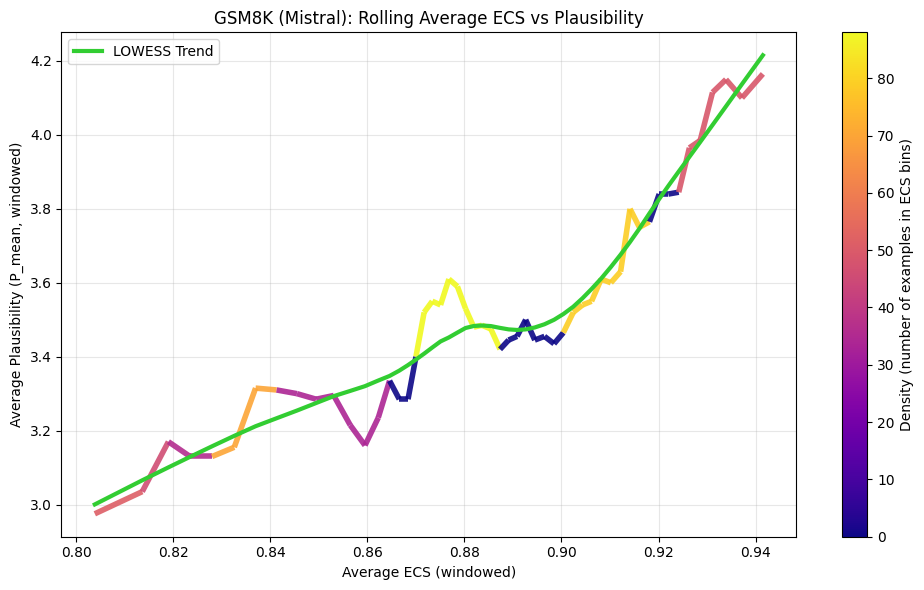

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.collections import LineCollection
from matplotlib.colors import Normalize
import matplotlib.cm as cm
from statsmodels.nonparametric.smoothers_lowess import lowess

# -----------------------------
# 1. SETUP FILES (CORRECTED)
# -----------------------------
plaus_file = "gsm8k/gsm8k_mistral_plausibility_with_pmean.csv"
ecs_file   = "gsm8k/gsm8k_mistral7B_ECS.csv"  # <--- Updated File

# -----------------------------
# 2. LOAD & MERGE DATA
# -----------------------------
# Load Plausibility
plaus_df = pd.read_csv(plaus_file)

# Ensure consistent column naming for pmean
if "pmean" not in plaus_df.columns and "Pmean" in plaus_df.columns:
    plaus_df.rename(columns={"Pmean": "pmean"}, inplace=True)

plaus_df = plaus_df[["id", "pmean"]]

# Load ECS
ecs_df = pd.read_csv(ecs_file)

# Ensure we select the correct column "ECS"
if "ECS" not in ecs_df.columns:
    raise ValueError(f"❌ Column 'ECS' not found in {ecs_file}. Columns are: {ecs_df.columns}")

ecs_df = ecs_df[["id", "ECS"]]

# Merge: Inner join ensures we only keep IDs present in BOTH files
df = plaus_df.merge(ecs_df, on="id", how="inner")

# Sort by ECS (Critical for the rolling window logic)
df = df.sort_values("ECS").reset_index(drop=True)

# Ensure numeric types
df["pmean"] = pd.to_numeric(df["pmean"], errors="coerce")
df["ECS"] = pd.to_numeric(df["ECS"], errors="coerce")

# Drop any rows that became NaN
df = df.dropna(subset=["pmean", "ECS"])

print(f"🔗 Final merged dataset size: {len(df)} rows")

# -----------------------------
# 3. BIN DATA (For Density)
# -----------------------------
# Create bins for ECS to calculate density
bin_width = 0.03
bins = np.arange(df["ECS"].min(), df["ECS"].max() + bin_width, bin_width)
df["ecs_bin"] = pd.cut(df["ECS"], bins=bins)

# Calculate density per bin
bin_density = df.groupby("ecs_bin", observed=True)["id"].count()
bin_mid = df.groupby("ecs_bin", observed=True)["ECS"].mean()

bin_stats = pd.DataFrame({
    "bin_mid": bin_mid,
    "density": bin_density
}).reset_index(drop=True)

# -----------------------------
# 4. ROLLING WINDOW CALCULATIONS
# -----------------------------
# Adjust window size if necessary. 
# For ~400 items, window=80 provides good smoothing without hiding too much detail.
window_size = 50 
step_size = 5

avg_ecs_list = []
avg_plaus_list = []
window_density = []

# Loop through sorted data
for start in range(0, len(df) - window_size + 1, step_size):
    window = df.iloc[start:start + window_size]

    avg_ecs_list.append(window["ECS"].mean())
    avg_plaus_list.append(window["pmean"].mean())

    # Calculate density for this specific window range
    ecs_min, ecs_max = window["ECS"].min(), window["ECS"].max()
    
    overlapping_bins = bin_stats[
        (bin_stats["bin_mid"] >= ecs_min) & 
        (bin_stats["bin_mid"] <= ecs_max)
    ]
    
    window_density.append(overlapping_bins["density"].sum())

# -----------------------------
# 5. PREPARE PLOT LINES
# -----------------------------
# Create segments for the "snake" line
points = np.array([avg_ecs_list, avg_plaus_list]).T.reshape(-1, 1, 2)
segments = np.concatenate([points[:-1], points[1:]], axis=1)

# Normalize density for color mapping
norm = Normalize(vmin=min(window_density), vmax=max(window_density))
colors = cm.plasma(norm(window_density[:-1]))

lc = LineCollection(segments, colors=colors, linewidth=4, alpha=0.9)

# -----------------------------
# 6. PLOTTING
# -----------------------------
fig, ax = plt.subplots(figsize=(10, 6))
ax.add_collection(lc)
ax.autoscale()
ax.set_xlabel("Average ECS (windowed)")
ax.set_ylabel("Average Plausibility (P_mean, windowed)")
ax.set_title("GSM8K (Mistral): Rolling Average ECS vs Plausibility")
ax.grid(alpha=0.3)

# Add Colorbar
sm = cm.ScalarMappable(cmap=cm.plasma, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax)
cbar.set_label("Density (number of examples in ECS bins)")

# -----------------------------
# 7. LOWESS SMOOTHING
# -----------------------------
density_threshold = np.percentile(window_density, 0) # 0 = keep all
mask = np.array(window_density) >= density_threshold

ecs_high = np.array(avg_ecs_list)[mask]
plaus_high = np.array(avg_plaus_list)[mask]

# frac=0.4 controls the smoothness.
smooth = lowess(plaus_high, ecs_high, frac=0.40, return_sorted=True)

smooth_ecs   = smooth[:, 0]
smooth_plaus = smooth[:, 1]

# Plot the smooth trend line
ax.plot(smooth_ecs, smooth_plaus, color="#32CD32", linewidth=3, label="LOWESS Trend")
ax.legend()

plt.tight_layout()
plt.show()

🔗 Final merged dataset: 314 rows


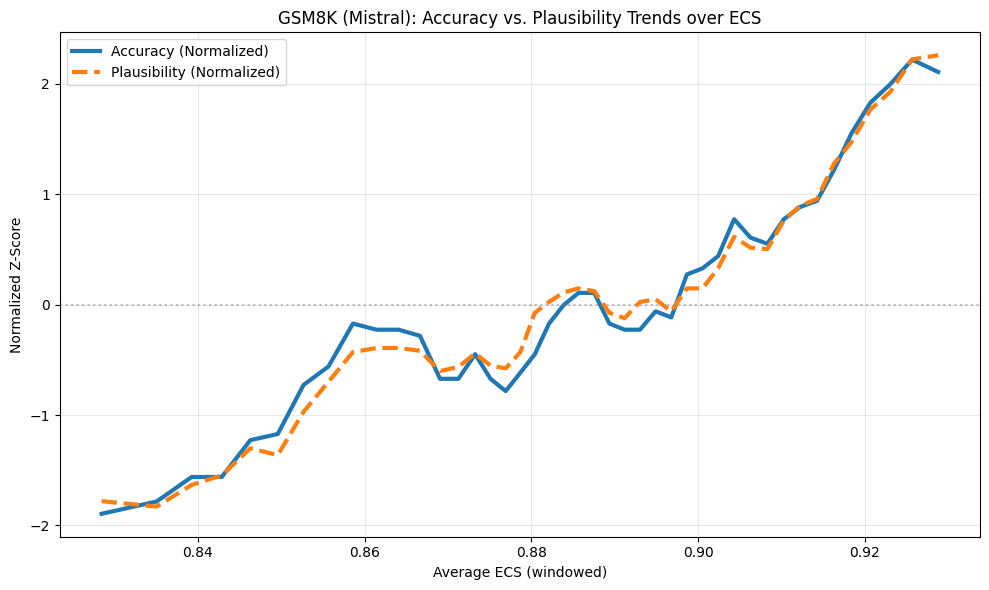

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# 1. SETUP FILES
# -----------------------------
plaus_file = "gsm8k/gsm8k_mistral_plausibility_with_pmean.csv"
ecs_file   = "gsm8k/gsm8k_mistral7B_ECS.csv"
acc_file   = "gsm8k/gsm8k_mistral7B_Accuracy_Consistency.csv" # Ensure this path is correct

# -----------------------------
# 2. LOAD DATA
# -----------------------------
# Load Plausibility
plaus_df = pd.read_csv(plaus_file)
# Normalize column name to 'pmean'
if "Pmean" in plaus_df.columns:
    plaus_df.rename(columns={"Pmean": "pmean"}, inplace=True)
plaus_df = plaus_df[["id", "pmean"]]

# Load ECS
ecs_df = pd.read_csv(ecs_file)[["id", "ECS"]]

# Load Accuracy
# Assuming the column is named 'accuracy'
acc_df = pd.read_csv(acc_file)[["id", "accuracy"]]

# -----------------------------
# 3. MERGE & PREPROCESS
# -----------------------------
# Merge all three dataframes on 'id'
df = acc_df.merge(plaus_df, on="id", how="inner") \
           .merge(ecs_df, on="id", how="inner")

# Ensure numeric types
for col in ["accuracy", "pmean", "ECS"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Drop missing values
df = df.dropna()

# SORT by ECS is critical for the rolling window to represent "Low to High Consistency"
df = df.sort_values("ECS").reset_index(drop=True)

print(f"🔗 Final merged dataset: {len(df)} rows")

# -----------------------------
# 4. ROLLING WINDOW CALCULATIONS
# -----------------------------
# Adjusted for GSM8K size (~400 rows). 
# Window=60 provides a good balance of smoothness vs detail.
window_size = 100
step_size = 5

ecs_avg_list = []
acc_avg_list = []
plaus_avg_list = []

for start in range(0, len(df) - window_size + 1, step_size):
    window = df.iloc[start:start + window_size]

    ecs_avg_list.append(window["ECS"].mean())
    acc_avg_list.append(window["accuracy"].mean())
    plaus_avg_list.append(window["pmean"].mean())

# Convert to numpy arrays for vector math
ecs_arr   = np.array(ecs_avg_list)
acc_arr   = np.array(acc_avg_list)
plaus_arr = np.array(plaus_avg_list)

# -----------------------------
# 5. NORMALIZATION (Z-SCORE)
# -----------------------------
# This scales both metrics to mean=0, std=1 so they can be compared on the same chart
def zscore(x):
    return (x - np.mean(x)) / np.std(x)

acc_norm   = zscore(acc_arr)
plaus_norm = zscore(plaus_arr)

# -----------------------------
# 6. PLOTTING
# -----------------------------
plt.figure(figsize=(10, 6))

# Plot Accuracy Trend
plt.plot(
    ecs_arr,
    acc_norm,
    label="Accuracy (Normalized)",
    linewidth=3,
    color="#1f77b4" # Blue
)

# Plot Plausibility Trend
plt.plot(
    ecs_arr,
    plaus_norm,
    label="Plausibility (Normalized)",
    linewidth=3,
    color="#ff7f0e", # Orange
    linestyle="--"    # Dashed to distinguish easily
)

# Add a zero line for reference (mean)
plt.axhline(0, color="gray", linestyle=":", alpha=0.5)

plt.xlabel("Average ECS (windowed)")
plt.ylabel("Normalized Z-Score")
plt.title("GSM8K (Mistral): Accuracy vs. Plausibility Trends over ECS")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()

**Llama plausibility on GSM8K**

In [9]:
import os
import pandas as pd
from vertexai.generative_models import GenerativeModel
import vertexai
import time
import csv
from tqdm import tqdm
import re

# ---------------------------
# 1. SETUP & AUTH
# ---------------------------
SERVICE_ACCOUNT_PATH = r"llm-reasoning-475315-b0391b898b58.json"

# Check if file exists to prevent silent failures
if not os.path.exists(SERVICE_ACCOUNT_PATH):
    raise FileNotFoundError(f"❌ JSON file not found: {SERVICE_ACCOUNT_PATH}")

os.environ["GOOGLE_APPLICATION_CREDENTIALS"] = SERVICE_ACCOUNT_PATH

vertexai.init(project="llm-reasoning-475315", location="us-central1")
model = GenerativeModel("gemini-2.5-flash")
print("✅ Gemini model initialized.")

# ---------------------------
# 2. DEFINE EXCLUSION LIST (UPDATED FOR LLAMA)
# ---------------------------
remove_ids = [
    2,7,27, 30, 36, 46, 47, 66, 82,85, 98, 103, 106, 110,111, 120,123, 127,128,135,143,145,146,149,
    150, 160, 168, 177, 190 ,196,204,207,209,212,214, 219,221,224, 229,230,238,263, 265,277,282,285,286, 287, 289,291, 309,314,317,323,326,336,339,340,342,352,355,
    357,362, 367, 369,376, 378,380, 384,385,398, 403, 416,420,424,425,431, 434,439,442,468,471,487,489, 492,
    36,51,75,63,69,92,93,100,112,115,116,125,130,170,183,215,219,225,237,257,271,
    303,311,315,332,347,348,350,357,367,369,371,372,374,445,454,460,462,488,489,499
]
remove_ids = set(remove_ids) # Convert to set for faster lookup

# ---------------------------
# 3. HELPER: EXTRACT GOLD ANSWER
# ---------------------------
def extract_clean_answer(text):
    if pd.isna(text):
        return ""
    text = str(text)
    if "####" in text:
        return text.split("####")[-1].strip()
    return text.strip()

# ---------------------------
# 4. LOAD & MERGE DATA
# ---------------------------
# NOTE: Ensure these paths are exactly correct relative to where you run the script
try:
    # 1. Questions
    df_questions = pd.read_csv("gsm8k/gsm8k_perturbed_full.csv")
    
    # 2. Rationales (UPDATED FOR LLAMA)
    df_rationales = pd.read_csv("gsm8k/gsm8k_llama3_CoT_responses_merged_clean.csv")
    
    # 3. Gold Answers
    df_answers = pd.read_csv("gsm8k/gsm8k_500_rows_with_answers.csv")
except FileNotFoundError as e:
    print(f"❌ Error loading CSVs: {e}")
    exit()

# Extract the clean answer
df_answers["clean_gold_answer"] = df_answers["answer"].apply(extract_clean_answer)

# Merge
merged = pd.merge(df_questions, df_rationales, on="id", how="inner")
merged = pd.merge(merged, df_answers[["id", "clean_gold_answer"]], on="id", how="inner")

print(f"📌 Merged dataset size BEFORE filtering: {len(merged)}")

# Filter out the exclusion IDs
merged = merged[~merged["id"].isin(remove_ids)]
print(f"📌 Final dataset size AFTER filtering: {len(merged)}")

if len(merged) == 0:
    print("❌ ERROR: The merged dataset is empty! Check your IDs and CSV files.")
    exit()

# ---------------------------
# 5. PROMPT & SCORING
# ---------------------------
JUDGE_PROMPT = """
You are an expert evaluator of Mathematical Reasoning.

Your task is to judge the **plausibility and correctness of the MODEL RATIONALE** given the QUESTION and the GOLD ANSWER.

### INPUT DATA:
Question: {question}
Gold Answer: {gold_answer}
Model Rationale: {rationale}

### CRITERIA:
A plausible rationale must:
1. Interpret the question correctly.
2. Perform logical reasoning steps.
3. Perform correct arithmetic calculations.
4. Reach a final answer that matches the Gold Answer (or is mathematically equivalent).

### SCORING RUBRIC (1–5):
5 = Excellent (Correct logic, correct math, correct answer).
4 = Good (Correct logic and answer, but minor phrasing issues or implicit steps).
3 = Weak (Method is mostly correct, but contains a minor arithmetic error leading to a slightly wrong answer).
2 = Flawed (Major logical gap or wrong formula, even if the answer is accidentally close).
1 = Incorrect (Completely wrong logic, hallucinations, or correct answer derived from wrong numbers).

### OUTPUT:
Output ONLY the integer score (1–5).
"""

def score_math_rationale(question, gold_answer, rationale):
    if pd.isna(rationale) or str(rationale).strip() == "":
        return 0 
        
    prompt = JUDGE_PROMPT.format(
        question=question,
        gold_answer=gold_answer,
        rationale=rationale
    )

    try:
        resp = model.generate_content(prompt)
        text = resp.text.strip()
        match = re.search(r"\b([1-5])\b", text)
        if match:
            return int(match.group(1))
        return None
    except Exception as e:
        # print(f"API Error: {e}") 
        return None

# ---------------------------
# 6. EXECUTION LOOP
# ---------------------------
output_path = "gsm8k/gsm8k_llama3_plausibility_scores.csv"

# Ensure the directory exists
output_dir = os.path.dirname(output_path)
if output_dir and not os.path.exists(output_dir):
    os.makedirs(output_dir)

write_header = not os.path.exists(output_path)

print(f"🚀 Starting to score {len(merged)} rows. Outputting to: {output_path}")

# Open the file in 'append' mode
with open(output_path, "a", newline="", encoding="utf-8") as f:
    writer = csv.writer(f)

    if write_header:
        writer.writerow(["id", "plaus_original", "plaus_lexical", "plaus_syntactic", "plaus_contextual"])
        f.flush() # Flush header immediately
        print("📝 Created new output file with header.")

    # Use tqdm to show progress bar
    for idx, row in tqdm(merged.iterrows(), total=len(merged), desc="Scoring Llama3"):
        ex_id = row["id"]
        gold_ans = row["clean_gold_answer"]

        # 1. Original
        s_orig = score_math_rationale(row["original"], gold_ans, row["cot_original"])
        
        # 2. Lexical
        s_lex = score_math_rationale(row["lexical"], gold_ans, row["cot_lexical"])
        
        # 3. Syntactic
        s_syn = score_math_rationale(row["syntactic"], gold_ans, row["cot_syntactic"])
        
        # 4. Contextual 
        s_ctx = score_math_rationale(row["contextual"], gold_ans, row["cot_contextual"])

        # Write to CSV
        writer.writerow([ex_id, s_orig, s_lex, s_syn, s_ctx])
        
        # --- CRITICAL FIX ---
        f.flush() 
        os.fsync(f.fileno()) 
        # This forces the OS to save the line to the physical disk immediately
        # --------------------

        # Small sleep to prevent hitting rate limits too hard
        time.sleep(0.2)

print("🎉 DONE! All Llama 3 scores saved.")

/Users/mariosellinidis/Desktop/computer science/Diploma Thesis/thesis-ecs/venv/lib/python3.12/site-packages/vertexai/generative_models/_generative_models.py:433: UserWarning: This feature is deprecated as of June 24, 2025 and will be removed on June 24, 2026. For details, see https://cloud.google.com/vertex-ai/generative-ai/docs/deprecations/genai-vertexai-sdk.
  warning_logs.show_deprecation_warning()


✅ Gemini model initialized.
📌 Merged dataset size BEFORE filtering: 500
📌 Final dataset size AFTER filtering: 380
🚀 Starting to score 380 rows. Outputting to: gsm8k/gsm8k_llama3_plausibility_scores.csv
📝 Created new output file with header.


Scoring Llama3: 100%|███████████████████████| 380/380 [1:55:20<00:00, 18.21s/it]

🎉 DONE! All Llama 3 scores saved.


In [13]:
import pandas as pd
import os

# ---------------------------
# 1. SETUP PATHS
# ---------------------------
input_path = "gsm8k/gsm8k_llama3_plausibility_scores.csv"
output_path = "gsm8k/gsm8k_llama3_plausibility_with_pmean.csv"

# Check if input file exists
if not os.path.exists(input_path):
    raise FileNotFoundError(f"❌ Input file not found: {input_path}")

# ---------------------------
# 2. LOAD DATA
# ---------------------------
df = pd.read_csv(input_path)
print(f"✅ Loaded {len(df)} rows from {input_path}")

# ---------------------------
# 3. CALCULATE P_MEAN
# ---------------------------
# Define the columns to average
score_cols = ["plaus_original", "plaus_lexical", "plaus_syntactic", "plaus_contextual"]

# Create 'pmean' column
# axis=1 means calculate across columns (row-by-row)
# numeric_only=True ensures we don't crash if there's weird data, though your data should be clean integers
df["pmean"] = df[score_cols].mean(axis=1)

# Optional: Round to 2 decimal places for cleaner reading
df["pmean"] = df["pmean"].round(2)

# ---------------------------
# 4. SAVE OUTPUT
# ---------------------------
df.to_csv(output_path, index=False)

print("------------------------------------------------")
print("SAMPLE PREVIEW:")
print(df[["id", "pmean"] + score_cols].head())
print("------------------------------------------------")
print(f"🎉 Success! New file saved with P_mean column to: {output_path}")

✅ Loaded 380 rows from gsm8k/gsm8k_llama3_plausibility_scores.csv
------------------------------------------------
SAMPLE PREVIEW:
   id  pmean  plaus_original  plaus_lexical  plaus_syntactic  plaus_contextual
0   1   5.00               5              5                5                 5
1   3   4.25               2              5                5                 5
2   4   5.00               5              5                5                 5
3   5   5.00               5              5                5                 5
4   6   4.25               5              5                5                 2
------------------------------------------------
🎉 Success! New file saved with P_mean column to: gsm8k/gsm8k_llama3_plausibility_with_pmean.csv


🔗 Final merged dataset: 366 rows


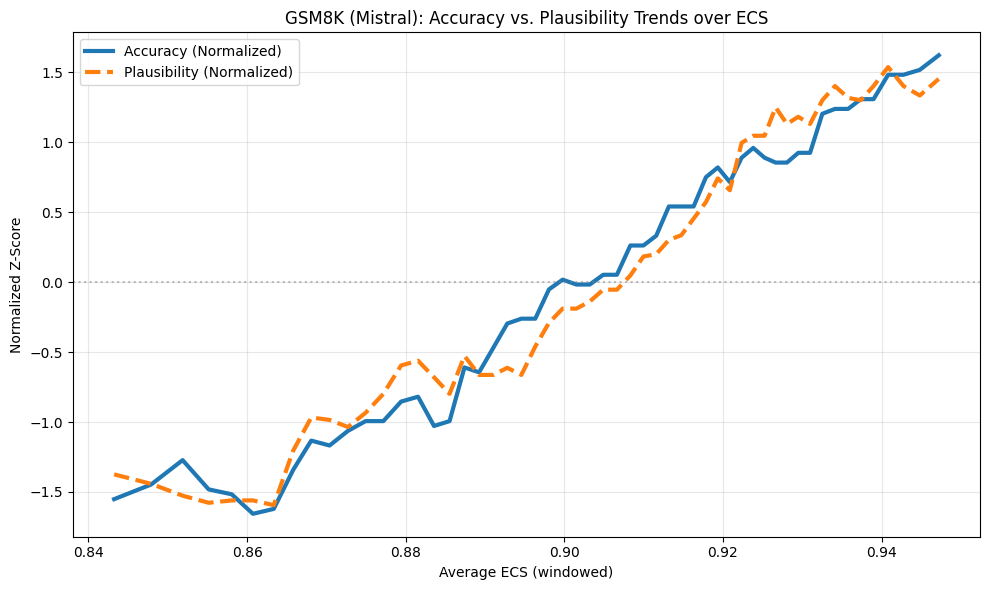

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# 1. SETUP FILES
# -----------------------------
plaus_file = "gsm8k/gsm8k_llama3_CoT_plausibility_scores_only.csv"
ecs_file   = "gsm8k/gsm8k_llama3_ECS_scores.csv"
acc_file   = "gsm8k/gsm8k_llama3_results.csv" # Ensure this path is correct

# -----------------------------
# 2. LOAD DATA
# -----------------------------
# Load Plausibility
plaus_df = pd.read_csv(plaus_file)


# Load ECS
ecs_df = pd.read_csv(ecs_file)[["id", "ECS"]]

# Load Accuracy
# Assuming the column is named 'accuracy'
acc_df = pd.read_csv(acc_file)[["id", "average_accuracy"]]

# -----------------------------
# 3. MERGE & PREPROCESS
# -----------------------------
# Merge all three dataframes on 'id'
df = acc_df.merge(plaus_df, on="id", how="inner") \
           .merge(ecs_df, on="id", how="inner")

# Ensure numeric types
for col in ["average_accuracy", "mean_plausibility", "ECS"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Drop missing values
df = df.dropna()

# SORT by ECS is critical for the rolling window to represent "Low to High Consistency"
df = df.sort_values("ECS").reset_index(drop=True)

print(f"🔗 Final merged dataset: {len(df)} rows")

# -----------------------------
# 4. ROLLING WINDOW CALCULATIONS
# -----------------------------
# Adjusted for GSM8K size (~400 rows). 
# Window=60 provides a good balance of smoothness vs detail.
window_size = 100
step_size = 5

ecs_avg_list = []
acc_avg_list = []
plaus_avg_list = []

for start in range(0, len(df) - window_size + 1, step_size):
    window = df.iloc[start:start + window_size]

    ecs_avg_list.append(window["ECS"].mean())
    acc_avg_list.append(window["average_accuracy"].mean())
    plaus_avg_list.append(window["mean_plausibility"].mean())

# Convert to numpy arrays for vector math
ecs_arr   = np.array(ecs_avg_list)
acc_arr   = np.array(acc_avg_list)
plaus_arr = np.array(plaus_avg_list)

# -----------------------------
# 5. NORMALIZATION (Z-SCORE)
# -----------------------------
# This scales both metrics to mean=0, std=1 so they can be compared on the same chart
def zscore(x):
    return (x - np.mean(x)) / np.std(x)

acc_norm   = zscore(acc_arr)
plaus_norm = zscore(plaus_arr)

# -----------------------------
# 6. PLOTTING
# -----------------------------
plt.figure(figsize=(10, 6))

# Plot Accuracy Trend
plt.plot(
    ecs_arr,
    acc_norm,
    label="Accuracy (Normalized)",
    linewidth=3,
    color="#1f77b4" # Blue
)

# Plot Plausibility Trend
plt.plot(
    ecs_arr,
    plaus_norm,
    label="Plausibility (Normalized)",
    linewidth=3,
    color="#ff7f0e", # Orange
    linestyle="--"    # Dashed to distinguish easily
)

# Add a zero line for reference (mean)
plt.axhline(0, color="gray", linestyle=":", alpha=0.5)

plt.xlabel("Average ECS (windowed)")
plt.ylabel("Normalized Z-Score")
plt.title("GSM8K (Mistral): Accuracy vs. Plausibility Trends over ECS")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()

✅ Saved plot as PDF: llama_ecs_accuracy.pdf


/var/folders/vk/18ngtwrs58n0x_sklvrh_58h0000gn/T/ipykernel_85468/456215722.py:34: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_density = df.groupby('ecs_bin')['id'].count()
/var/folders/vk/18ngtwrs58n0x_sklvrh_58h0000gn/T/ipykernel_85468/456215722.py:35: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_mid = df.groupby('ecs_bin')['ECS'].mean()
/var/folders/vk/18ngtwrs58n0x_sklvrh_58h0000gn/T/ipykernel_85468/456215722.py:111: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend

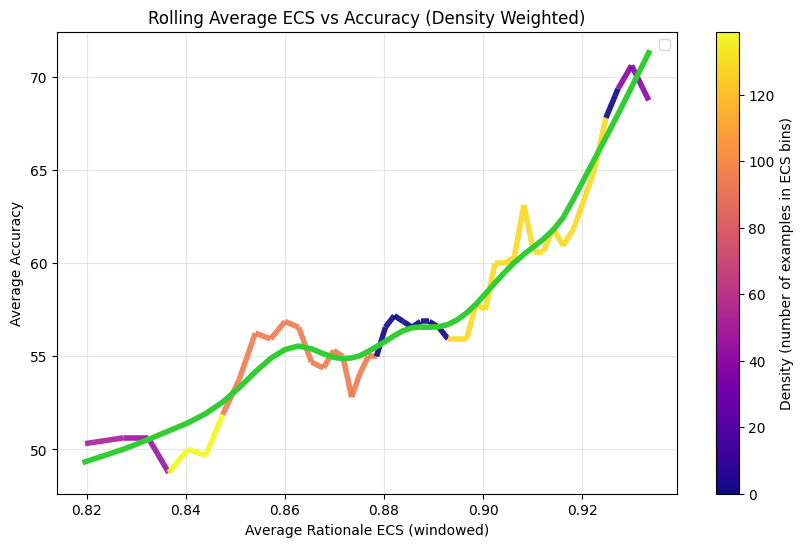

💾 Saved rolling window ECS vs accuracy with density info
✨ Smoothed trend added (LOWESS using high-density regions).


In [20]:


import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.collections import LineCollection
from matplotlib.colors import Normalize
import matplotlib.cm as cm
from statsmodels.nonparametric.smoothers_lowess import lowess

# -----------------------------
# File paths
# -----------------------------
ecs_file = "gsm8k/gsm8k_mistral7B_ECS.csv"
low_accuracy_file = "gsm8k/low_ecs_accuracy_mistral.csv"
high_accuracy_file = "gsm8k/high_ecs_accuracy_mistral.csv"

# -----------------------------
# Load data
# -----------------------------
ecs_df = pd.read_csv(ecs_file)[["id","ECS"]]
low_df = pd.read_csv(low_accuracy_file)[["id","accuracy"]]
high_df = pd.read_csv(high_accuracy_file)[["id","accuracy"]]

df = pd.concat([low_df, high_df], ignore_index=True)
df = df.merge(ecs_df, on="id", how="left")
df = df.sort_values("ECS").reset_index(drop=True)

# -----------------------------
# Bin ECS to compute density
# -----------------------------
bin_width = 0.05
bins = np.arange(df['ECS'].min(), df['ECS'].max() + bin_width, bin_width)
df['ecs_bin'] = pd.cut(df['ECS'], bins=bins)

bin_density = df.groupby('ecs_bin')['id'].count()
bin_mid = df.groupby('ecs_bin')['ECS'].mean()

bin_stats = pd.DataFrame({
    'bin_mid': bin_mid,
    'density': bin_density
}).reset_index(drop=True)

# -----------------------------
# Rolling window parameters
# -----------------------------
window_size = 80
step_size = 5

avg_ecs_list = []
avg_acc_list = []
window_density = []

# -----------------------------
# Compute rolling averages and assign density
# -----------------------------
for start in range(0, len(df) - window_size + 1, step_size):
    window = df.iloc[start:start+window_size]
    avg_ecs_list.append(window['ECS'].mean())
    avg_acc_list.append(window['accuracy'].mean())
    
    ecs_min, ecs_max = window['ECS'].min(), window['ECS'].max()
    overlapping_bins = bin_stats[(bin_stats['bin_mid'] >= ecs_min) & (bin_stats['bin_mid'] <= ecs_max)]
    window_density.append(overlapping_bins['density'].sum())

# -----------------------------
# Prepare colored zigzag line
# -----------------------------
points = np.array([avg_ecs_list, avg_acc_list]).T.reshape(-1, 1, 2)
segments = np.concatenate([points[:-1], points[1:]], axis=1)

norm = Normalize(vmin=min(window_density), vmax=max(window_density))
colors = cm.plasma(norm(window_density[:-1]))

lc = LineCollection(segments, colors=colors, linewidth=4, alpha=0.9)

# -----------------------------
# Create plot
# -----------------------------
fig, ax = plt.subplots(figsize=(10,6))
ax.add_collection(lc)
ax.autoscale()
ax.set_xlabel("Average Rationale ECS (windowed)")
ax.set_ylabel("Average Accuracy")
ax.set_title("Rolling Average ECS vs Accuracy (Density Weighted)")
ax.grid(alpha=0.3)

# -----------------------------
# Colorbar
# -----------------------------
sm = cm.ScalarMappable(cmap=cm.plasma, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax)
cbar.set_label("Density (number of examples in ECS bins)")

# -----------------------------
# Smooth only high-density regions
# -----------------------------
density_threshold = np.percentile(window_density, 0)  # keep top 40% dense windows
mask = np.array(window_density) >= density_threshold

ecs_high = np.array(avg_ecs_list)[mask]
acc_high = np.array(avg_acc_list)[mask]

# LOWESS smoothing (more smooth)
smooth = lowess(acc_high, ecs_high, frac=0.30, return_sorted=True)  # increased frac
smooth_ecs = smooth[:,0]
smooth_acc = smooth[:,1]

# Plot smoothed trend backbone (green line)
# ΠΡΟΣΟΧΗ: Πρόσθεσα το label για να φαίνεται στο legend
ax.plot(smooth_ecs, smooth_acc, color="#32CD32", linewidth=4, label="")
ax.legend()

# -----------------------------
# SAVE AS PDF (NEW CODE HERE)
# -----------------------------
pdf_filename = "llama_ecs_accuracy.pdf"
plt.savefig(pdf_filename, format="pdf", bbox_inches="tight")
print(f"✅ Saved plot as PDF: {pdf_filename}")

plt.show()

print("💾 Saved rolling window ECS vs accuracy with density info")
print("✨ Smoothed trend added (LOWESS using high-density regions).")

/var/folders/vk/18ngtwrs58n0x_sklvrh_58h0000gn/T/ipykernel_85468/1881918966.py:34: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_density = df.groupby('ecs_bin')['id'].count()
/var/folders/vk/18ngtwrs58n0x_sklvrh_58h0000gn/T/ipykernel_85468/1881918966.py:35: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_mid = df.groupby('ecs_bin')['ECS'].mean()
/var/folders/vk/18ngtwrs58n0x_sklvrh_58h0000gn/T/ipykernel_85468/1881918966.py:111: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.leg

✅ Saved plot as PDF: ecs_rolling_accuracy.pdf


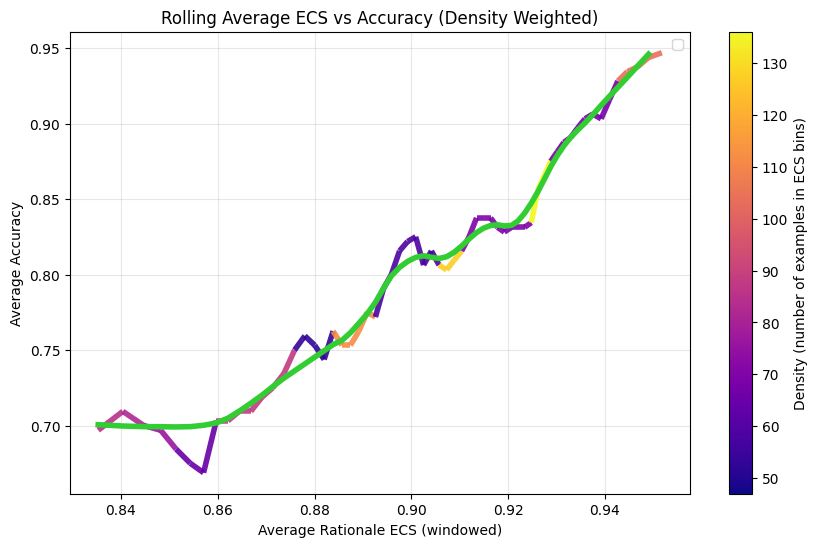

💾 Saved rolling window ECS vs accuracy with density info
✨ Smoothed trend added (LOWESS using high-density regions).


In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.collections import LineCollection
from matplotlib.colors import Normalize
import matplotlib.cm as cm
from statsmodels.nonparametric.smoothers_lowess import lowess

# -----------------------------
# File paths
# -----------------------------
ecs_file = "gsm8k/gsm8k_llama3_ECS_scores.csv"
low_accuracy_file = "gsm8k/low_ecs_accuracy_summary.csv"
high_accuracy_file = "gsm8k/high_ecs_accuracy_summary.csv"

# -----------------------------
# Load data
# -----------------------------
ecs_df = pd.read_csv(ecs_file)[["id","ECS"]]
low_df = pd.read_csv(low_accuracy_file)[["id","average_accuracy"]]
high_df = pd.read_csv(high_accuracy_file)[["id","average_accuracy"]]

df = pd.concat([low_df, high_df], ignore_index=True)
df = df.merge(ecs_df, on="id", how="left")
df = df.sort_values("ECS").reset_index(drop=True)

# -----------------------------
# Bin ECS to compute density
# -----------------------------
bin_width = 0.02
bins = np.arange(df['ECS'].min(), df['ECS'].max() + bin_width, bin_width)
df['ecs_bin'] = pd.cut(df['ECS'], bins=bins)

bin_density = df.groupby('ecs_bin')['id'].count()
bin_mid = df.groupby('ecs_bin')['ECS'].mean()

bin_stats = pd.DataFrame({
    'bin_mid': bin_mid,
    'density': bin_density
}).reset_index(drop=True)

# -----------------------------
# Rolling window parameters
# -----------------------------
window_size = 80
step_size = 5

avg_ecs_list = []
avg_acc_list = []
window_density = []

# -----------------------------
# Compute rolling averages and assign density
# -----------------------------
for start in range(0, len(df) - window_size + 1, step_size):
    window = df.iloc[start:start+window_size]
    avg_ecs_list.append(window['ECS'].mean())
    avg_acc_list.append(window['average_accuracy'].mean())
    
    ecs_min, ecs_max = window['ECS'].min(), window['ECS'].max()
    overlapping_bins = bin_stats[(bin_stats['bin_mid'] >= ecs_min) & (bin_stats['bin_mid'] <= ecs_max)]
    window_density.append(overlapping_bins['density'].sum())

# -----------------------------
# Prepare colored zigzag line
# -----------------------------
points = np.array([avg_ecs_list, avg_acc_list]).T.reshape(-1, 1, 2)
segments = np.concatenate([points[:-1], points[1:]], axis=1)

norm = Normalize(vmin=min(window_density), vmax=max(window_density))
colors = cm.plasma(norm(window_density[:-1]))

lc = LineCollection(segments, colors=colors, linewidth=4, alpha=0.9)

# -----------------------------
# Create plot
# -----------------------------
fig, ax = plt.subplots(figsize=(10,6))
ax.add_collection(lc)
ax.autoscale()
ax.set_xlabel("Average Rationale ECS (windowed)")
ax.set_ylabel("Average Accuracy")
ax.set_title("Rolling Average ECS vs Accuracy (Density Weighted)")
ax.grid(alpha=0.3)

# -----------------------------
# Colorbar
# -----------------------------
sm = cm.ScalarMappable(cmap=cm.plasma, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax)
cbar.set_label("Density (number of examples in ECS bins)")

# -----------------------------
# Smooth only high-density regions
# -----------------------------
density_threshold = np.percentile(window_density, 20)  # keep top 80% dense windows
mask = np.array(window_density) >= density_threshold

ecs_high = np.array(avg_ecs_list)[mask]
acc_high = np.array(avg_acc_list)[mask]

# LOWESS smoothing
smooth = lowess(acc_high, ecs_high, frac=0.2, return_sorted=True)
smooth_ecs = smooth[:,0]
smooth_acc = smooth[:,1]

# Plot smoothed trend backbone (green line)
# ΠΡΟΣΟΧΗ: Πρόσθεσα το label="..." για να δουλέψει το legend
ax.plot(smooth_ecs, smooth_acc, color="#32CD32", linewidth=4, label="")
ax.legend()

# -----------------------------
# SAVE AS PDF (NEW CODE HERE)
# -----------------------------
pdf_filename = "ecs_rolling_accuracy.pdf"
plt.savefig(pdf_filename, format="pdf", bbox_inches="tight")
print(f"✅ Saved plot as PDF: {pdf_filename}")

plt.show()

print("💾 Saved rolling window ECS vs accuracy with density info")
print("✨ Smoothed trend added (LOWESS using high-density regions).")